In [ ]:
# Check GPU and conduct imports
!nvidia-smi
import os, getpass

Mon Mar  2 16:07:02 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   46C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# Set API Token for Kaggle
os.environ["KAGGLE_API_TOKEN"] = getpass.getpass("Token")
print("Token set:", "KAGGLE_API_TOKEN" in os.environ, "| length:", len(os.environ["KAGGLE_API_TOKEN"]))

Token··········
Token set: True | length: 37


In [ ]:
# Install and import kaggle
!pip -q install kagglehub
import kagglehub
print("kagglehub version:", getattr(kagglehub, "__version__", "unknown"))

kagglehub version: 0.3.13


In [ ]:
# Download caltech-101

import kagglehub, os

path = kagglehub.dataset_download("imbikramsaha/caltech-101")
print("Downloaded to:", path)

# Show what's inside (top-level)
print("\nTop-level entries:")
for name in sorted(os.listdir(path))[:30]:
    print(" -", name)

100%|██████████| 131M/131M [00:04<00:00, 30.6MB/s]

Extracting files...


Downloaded to: /root/.cache/kagglehub/datasets/imbikramsaha/caltech-101/versions/1

Top-level entries:
 - caltech-101


In [ ]:
# Look at folders

import os

base = "/root/.cache/kagglehub/datasets/imbikramsaha/caltech-101/versions/1"
print("Base:", base)

print("\nLevel 1 entries:")
for name in sorted(os.listdir(base))[:50]:
    print(" -", name)

only = sorted(os.listdir(base))
if len(only) == 1 and os.path.isdir(os.path.join(base, only[0])):
    base2 = os.path.join(base, only[0])
    print("\nNested folder entries:", base2)
    for name in sorted(os.listdir(base2))[:50]:
        print(" -", name)

Base: /root/.cache/kagglehub/datasets/imbikramsaha/caltech-101/versions/1

Level 1 entries:
 - caltech-101

Nested folder entries: /root/.cache/kagglehub/datasets/imbikramsaha/caltech-101/versions/1/caltech-101
 - BACKGROUND_Google
 - Faces
 - Faces_easy
 - Leopards
 - Motorbikes
 - accordion
 - airplanes
 - anchor
 - ant
 - barrel
 - bass
 - beaver
 - binocular
 - bonsai
 - brain
 - brontosaurus
 - buddha
 - butterfly
 - camera
 - cannon
 - car_side
 - ceiling_fan
 - cellphone
 - chair
 - chandelier
 - cougar_body
 - cougar_face
 - crab
 - crayfish
 - crocodile
 - crocodile_head
 - cup
 - dalmatian
 - dollar_bill
 - dolphin
 - dragonfly
 - electric_guitar
 - elephant
 - emu
 - euphonium
 - ewer
 - ferry
 - flamingo
 - flamingo_head
 - garfield
 - gerenuk
 - gramophone
 - grand_piano
 - hawksbill
 - headphone


In [ ]:
import os, glob, numpy as np

base = "/root/.cache/kagglehub/datasets/imbikramsaha/caltech-101/versions/1/caltech-101"

# all class folders
all_classes = sorted([d for d in os.listdir(base) if os.path.isdir(os.path.join(base, d))])

# candidate "101 object categories" (exclude BACKGROUND_Google)
obj_classes = [c for c in all_classes if c != "BACKGROUND_Google"]

def count_images(cls):
    p = os.path.join(base, cls)
    exts = ("*.jpg","*.jpeg","*.png","*.bmp")
    files = []
    for e in exts:
        files.extend(glob.glob(os.path.join(p, e)))
    return len(files)

counts_all = {c: count_images(c) for c in all_classes}
counts_obj = {c: count_images(c) for c in obj_classes}

print("Num folders (including BACKGROUND_Google):", len(all_classes))
print("Num folders (excluding BACKGROUND_Google):", len(obj_classes))

vals = np.array(list(counts_obj.values()))
print("\nObject-class image counts (excluding BACKGROUND_Google):")
print("  min:", int(vals.min()), " | median:", int(np.median(vals)), " | max:", int(vals.max()))

# show the smallest 10 classes (useful to know for stratified splitting)
smallest = sorted(counts_obj.items(), key=lambda x: x[1])[:10]
print("\nSmallest 10 classes (name, n_images):")
for k,v in smallest:
    print(f"  {k}: {v}")

Num folders (including BACKGROUND_Google): 102
Num folders (excluding BACKGROUND_Google): 101

Object-class image counts (excluding BACKGROUND_Google):
  min: 31  | median: 59  | max: 800

Smallest 10 classes (name, n_images):
  inline_skate: 31
  metronome: 32
  binocular: 33
  garfield: 34
  gerenuk: 34
  platypus: 34
  wild_cat: 34
  octopus: 35
  snoopy: 35
  strawberry: 35


In [ ]:
# Set up Google Drive and project folders (MiniProject1_v3)

from google.colab import drive
from pathlib import Path

drive.mount("/content/drive")

PROJECT_ROOT = Path("/content/drive/MyDrive/VictoriaClass/MiniProject1_v3")
PROJECT_ROOT.mkdir(parents=True, exist_ok=True)

# Core subdirectories
(SPLITS_DIR  := PROJECT_ROOT / "splits").mkdir(exist_ok=True)
(RESULTS_DIR := PROJECT_ROOT / "results").mkdir(exist_ok=True)
(MODELS_DIR  := PROJECT_ROOT / "models").mkdir(exist_ok=True)
(FIGS_DIR    := PROJECT_ROOT / "figures").mkdir(exist_ok=True)
(LOGS_DIR    := PROJECT_ROOT / "logs").mkdir(exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("Subdirs:", sorted([p.name for p in PROJECT_ROOT.iterdir() if p.is_dir()]))

Mounted at /content/drive
PROJECT_ROOT: /content/drive/MyDrive/VictoriaClass/MiniProject1_v3
Subdirs: ['figures', 'logs', 'models', 'results', 'splits']


In [ ]:
# Make reproducible splits (70/15/15 stratified) and save to Drive

import os, glob
import pandas as pd
from sklearn.model_selection import train_test_split
from pathlib import Path

# ---- Paths ----
# Caltech-101 class folders (from kagglehub download)
BASE = "/root/.cache/kagglehub/datasets/imbikramsaha/caltech-101/versions/1/caltech-101"

# Drive project root
PROJECT_ROOT = Path("/content/drive/MyDrive/VictoriaClass/MiniProject1_v3")
SPLITS_DIR = PROJECT_ROOT / "splits"
SPLITS_DIR.mkdir(parents=True, exist_ok=True)

# Settings
SEED = 42
exts = ("*.jpg", "*.jpeg", "*.png", "*.bmp")

# Classes (exclude BACKGROUND_Google)
classes = sorted([
    d for d in os.listdir(BASE)
    if os.path.isdir(os.path.join(BASE, d)) and d != "BACKGROUND_Google"
])

# Build manifest
rows = []
for cls in classes:
    cls_dir = os.path.join(BASE, cls)
    files = []
    for e in exts:
        files.extend(glob.glob(os.path.join(cls_dir, e)))
    files = sorted(files)
    for fp in files:
        rows.append({"path": fp, "class_name": cls})

df = pd.DataFrame(rows)
print("Total images:", len(df), "| Num classes:", df["class_name"].nunique())

# Class mapping
class_to_idx = {c: i for i, c in enumerate(classes)}
df["class_idx"] = df["class_name"].map(class_to_idx)

# Stratified split: 70/15/15
train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=SEED, stratify=df["class_name"]
)

val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=SEED, stratify=temp_df["class_name"]
)

# Checks
def split_summary(name, d):
    vc = d["class_name"].value_counts()
    print(f"{name}: n={len(d)} | classes={d['class_name'].nunique()} | per-class min={vc.min()} max={vc.max()}")

split_summary("TRAIN", train_df)
split_summary("VAL  ", val_df)
split_summary("TEST ", test_df)

train_classes = set(train_df["class_name"])
val_classes   = set(val_df["class_name"])
test_classes  = set(test_df["class_name"])
print("\nMissing classes?")
print("  in TRAIN:", sorted(set(classes) - train_classes))
print("  in VAL  :", sorted(set(classes) - val_classes))
print("  in TEST :", sorted(set(classes) - test_classes))

# Save
train_csv = SPLITS_DIR / f"train_seed{SEED}.csv"
val_csv   = SPLITS_DIR / f"val_seed{SEED}.csv"
test_csv  = SPLITS_DIR / f"test_seed{SEED}.csv"

train_df.to_csv(train_csv, index=False)
val_df.to_csv(val_csv, index=False)
test_df.to_csv(test_csv, index=False)

mapping_csv = SPLITS_DIR / "class_to_idx.csv"
pd.DataFrame({"class_name": classes, "class_idx": [class_to_idx[c] for c in classes]}).to_csv(mapping_csv, index=False)

# README
readme = SPLITS_DIR / "README.txt"
readme.write_text(
    "\n".join([
        "MiniProject1_v3 splits",
        f"BASE={BASE}",
        f"SEED={SEED}",
        "Split=70/15/15 stratified by class_name (sklearn train_test_split)",
        f"TRAIN={train_csv.name} n={len(train_df)}",
        f"VAL={val_csv.name} n={len(val_df)}",
        f"TEST={test_csv.name} n={len(test_df)}",
        f"NumClasses={len(classes)} (BACKGROUND_Google excluded)",
    ]) + "\n"
)

print("\nSaved to:", SPLITS_DIR)
print(" -", train_csv.name)
print(" -", val_csv.name)
print(" -", test_csv.name)
print(" -", mapping_csv.name)
print(" -", readme.name)

Total images: 8677 | Num classes: 101
TRAIN: n=6073 | classes=101 | per-class min=22 max=560
VAL  : n=1302 | classes=101 | per-class min=4 max=120
TEST : n=1302 | classes=101 | per-class min=5 max=120

Missing classes?
  in TRAIN: []
  in VAL  : []
  in TEST : []

Saved to: /content/drive/MyDrive/VictoriaClass/MiniProject1_v3/splits
 - train_seed42.csv
 - val_seed42.csv
 - test_seed42.csv
 - class_to_idx.csv
 - README.txt


In [ ]:
# Confirm paths and split (MiniProject1_v3)

import pandas as pd
from PIL import Image
from pathlib import Path

SPLITS_DIR = Path("/content/drive/MyDrive/VictoriaClass/MiniProject1_v3/splits")

train_csv = SPLITS_DIR / "train_seed42.csv"
val_csv   = SPLITS_DIR / "val_seed42.csv"
test_csv  = SPLITS_DIR / "test_seed42.csv"

for p in [train_csv, val_csv, test_csv]:
    assert p.exists(), f"Missing: {p} (did you mount Drive?)"

train_df = pd.read_csv(train_csv)
print(train_df.head(3)[["path","class_name","class_idx"]])

fp = train_df.loc[0, "path"]
with Image.open(fp) as im:
    img = im.convert("RGB")

print("Opened:", fp)
print("Size:", img.size, "| Mode:", img.mode)

                                                path   class_name  class_idx
0  /root/.cache/kagglehub/datasets/imbikramsaha/c...   Faces_easy          1
1  /root/.cache/kagglehub/datasets/imbikramsaha/c...  water_lilly         95
2  /root/.cache/kagglehub/datasets/imbikramsaha/c...  joshua_tree         53
Opened: /root/.cache/kagglehub/datasets/imbikramsaha/caltech-101/versions/1/caltech-101/Faces_easy/image_0360.jpg
Size: (382, 252) | Mode: RGB


In [ ]:
# Install scikit-image for classical machine learning models

!pip -q install scikit-image

In [ ]:
import pandas as pd
import numpy as np
from PIL import Image
from pathlib import Path
from skimage.feature import hog

# Design choices (primary runs)
IMG_SIZE = (128, 128)   # 128x128 for all primary models
USE_RGB = True          # RGB for all primary models

# Load one row from the training CSV (Drive) - v3 + seeded
train_csv = Path("/content/drive/MyDrive/VictoriaClass/MiniProject1_v3/splits/train_seed42.csv")
assert train_csv.exists(), f"Missing: {train_csv} (did you mount Drive?)"

train_df = pd.read_csv(train_csv)
fp = train_df.loc[0, "path"]
label = train_df.loc[0, "class_name"]

print("Example file:", fp)
print("Label:", label)

# Open image and resize to fixed 128x128 RGB
with Image.open(fp) as im:
    im = im.convert("RGB")  # ensure 3-channel RGB
    im_128 = im.resize(IMG_SIZE, resample=Image.BILINEAR)

img_rgb_128 = np.asarray(im_128).astype(np.float32) / 255.0  # float in [0, 1]
print("Resized RGB shape:", img_rgb_128.shape, "| dtype:", img_rgb_128.dtype)

# Compute HOG feature vector on RGB
hog_kwargs = dict(
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2),
    block_norm="L2-Hys",
    feature_vector=True,
)

try:
    hog_vec = hog(img_rgb_128, channel_axis=-1, **hog_kwargs)
    hog_mode = "RGB HOG via channel_axis=-1"
except TypeError:
    hog_vecs = []
    for ch in range(3):
        hog_vecs.append(hog(img_rgb_128[..., ch], **hog_kwargs))
    hog_vec = np.concatenate(hog_vecs)
    hog_mode = "RGB HOG via per-channel concat fallback"

print("HOG mode:", hog_mode)
print("HOG feature length:", hog_vec.shape[0])
print("HOG feature stats: min/mean/max =",
      float(hog_vec.min()), float(hog_vec.mean()), float(hog_vec.max()))

Example file: /root/.cache/kagglehub/datasets/imbikramsaha/caltech-101/versions/1/caltech-101/Faces_easy/image_0360.jpg
Label: Faces_easy
Resized RGB shape: (128, 128, 3) | dtype: float32
HOG mode: RGB HOG via channel_axis=-1
HOG feature length: 8100
HOG feature stats: min/mean/max = 0.0 0.11110327392816544 0.6938990354537964


In [ ]:
# Benchmark HOG extraction speed and memory

import pandas as pd
import numpy as np
import time
from PIL import Image
from pathlib import Path
from skimage.feature import hog

# Design choices
IMG_SIZE = (128, 128)   # 128x128 for all primary models
USE_RGB = True          # RGB for all primary models

hog_kwargs = dict(
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2),
    block_norm="L2-Hys",
    feature_vector=True,
)

# Load train split (Drive) - v3 + seeded
train_csv = Path("/content/drive/MyDrive/VictoriaClass/MiniProject1_v3/splits/train_seed42.csv")
assert train_csv.exists(), f"Missing: {train_csv} (did you mount Drive?)"
train_df = pd.read_csv(train_csv)

# Small benchmark on first N images
N = 200
N = min(N, len(train_df))

# Figure out feature length robustly by computing 1 example
fp0 = train_df.loc[0, "path"]
with Image.open(fp0) as im:
    im = im.convert("RGB")
    im_128 = im.resize(IMG_SIZE, resample=Image.BILINEAR)
img0 = np.asarray(im_128).astype(np.float32) / 255.0

try:
    v0 = hog(img0, channel_axis=-1, **hog_kwargs)
    hog_mode = "RGB HOG via channel_axis=-1"
except TypeError:
    v0 = np.concatenate([hog(img0[..., ch], **hog_kwargs) for ch in range(3)])
    hog_mode = "RGB HOG via per-channel concat fallback"

feat_dim = int(v0.shape[0])
print("HOG mode:", hog_mode)
print("HOG feature length:", feat_dim)

# Preallocate arrays
X = np.zeros((N, feat_dim), dtype=np.float32)
y = np.zeros((N,), dtype=np.int64)

t0 = time.time()
for i in range(N):
    fp = train_df.loc[i, "path"]
    y[i] = int(train_df.loc[i, "class_idx"])

    with Image.open(fp) as im:
        im = im.convert("RGB")
        im_128 = im.resize(IMG_SIZE, resample=Image.BILINEAR)
    img = np.asarray(im_128).astype(np.float32) / 255.0

    try:
        X[i] = hog(img, channel_axis=-1, **hog_kwargs).astype(np.float32)
    except TypeError:
        X[i] = np.concatenate([hog(img[..., ch], **hog_kwargs) for ch in range(3)]).astype(np.float32)

t1 = time.time()

print("\nExtracted X shape:", X.shape, "dtype:", X.dtype)
print("y shape:", y.shape, "dtype:", y.dtype)
print("Time for", N, "images:", round(t1 - t0, 2), "seconds")
print("Approx X memory (MB):", round(X.nbytes / 1e6, 2))

HOG mode: RGB HOG via channel_axis=-1
HOG feature length: 8100

Extracted X shape: (200, 8100) dtype: float32
y shape: (200,) dtype: int64
Time for 200 images: 3.18 seconds
Approx X memory (MB): 6.48


In [ ]:
# HOG for all images (train, val, and test)

import os, time, json
import numpy as np
import pandas as pd
from PIL import Image
from pathlib import Path
from skimage.feature import hog

# Design choices
IMG_SIZE = (128, 128)
USE_RGB = True
SEED = 42

hog_kwargs = dict(
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2),
    block_norm="L2-Hys",
    feature_vector=True,
)

# Paths
PROJECT_ROOT = Path("/content/drive/MyDrive/VictoriaClass/MiniProject1_v3")
SPLITS_DIR = PROJECT_ROOT / "splits"
FEATURES_DIR = PROJECT_ROOT / "features" / "hog_128_rgb"
FEATURES_DIR.mkdir(parents=True, exist_ok=True)

split_csv = {
    "train": SPLITS_DIR / f"train_seed{SEED}.csv",
    "val":   SPLITS_DIR / f"val_seed{SEED}.csv",
    "test":  SPLITS_DIR / f"test_seed{SEED}.csv",
}

for k, p in split_csv.items():
    assert p.exists(), f"Missing {k} split CSV: {p}"

def _load_and_resize_rgb(fp: str, img_size=(128, 128)) -> np.ndarray:
    """Load image, force RGB, resize with PIL, return float32 in [0,1], shape (H,W,3)."""
    with Image.open(fp) as im:
        im = im.convert("RGB")
        im = im.resize(img_size, resample=Image.BILINEAR)
    arr = np.asarray(im).astype(np.float32) / 255.0
    return arr

def _hog_rgb(img_rgb: np.ndarray) -> np.ndarray:
    """Compute HOG on RGB (channel-aware). Falls back to per-channel concat if needed."""
    try:
        return hog(img_rgb, channel_axis=-1, **hog_kwargs).astype(np.float32)
    except TypeError:
        return np.concatenate([hog(img_rgb[..., ch], **hog_kwargs) for ch in range(3)]).astype(np.float32)

def extract_hog_npz(split_name: str, overwrite: bool = False):
    """
    split_name in {"train","val","test"}.
    Loads split CSV, extracts HOG features for all images, saves X/y to .npz in Drive.
    """
    assert split_name in split_csv, f"split_name must be one of {list(split_csv.keys())}"
    csv_path = split_csv[split_name]
    out_path = FEATURES_DIR / f"{split_name}_hog_128_rgb_seed{SEED}.npz"

    if out_path.exists() and not overwrite:
        print(f"[{split_name}] Exists, skipping: {out_path.name} "
              f"(size {out_path.stat().st_size/1e6:.2f} MB)")
        return out_path

    df = pd.read_csv(csv_path)
    n = len(df)
    assert n > 0, f"No rows in {csv_path}"

    # Determine feature length from the first image
    img0 = _load_and_resize_rgb(df.loc[0, "path"], IMG_SIZE)
    v0 = _hog_rgb(img0)
    feat_dim = int(v0.shape[0])

    X = np.zeros((n, feat_dim), dtype=np.float32)
    y = df["class_idx"].astype(np.int64).to_numpy()

    t0 = time.time()
    for i in range(n):
        fp = df.loc[i, "path"]
        img = _load_and_resize_rgb(fp, IMG_SIZE)
        X[i] = _hog_rgb(img)

        if (i + 1) % 500 == 0:
            print(f"[{split_name}] Processed {i+1}/{n}")

    t1 = time.time()

    np.savez_compressed(out_path, X=X, y=y)

    print(f"\n[{split_name}] Saved: {out_path}")
    print(f"[{split_name}] X shape: {X.shape} dtype={X.dtype}")
    print(f"[{split_name}] y shape: {y.shape} dtype={y.dtype}")
    print(f"[{split_name}] Time (s): {t1 - t0:.2f}")
    print(f"[{split_name}] File size (MB): {out_path.stat().st_size / 1e6:.2f}")

    return out_path

# Write a small manifest for reproducibility
manifest = {
    "img_size": list(IMG_SIZE),
    "use_rgb": USE_RGB,
    "seed": SEED,
    "hog_kwargs": hog_kwargs,
    "splits": {k: str(v) for k, v in split_csv.items()},
    "output_dir": str(FEATURES_DIR),
}
(manifest_path := FEATURES_DIR / "manifest.json").write_text(json.dumps(manifest, indent=2))
print("Wrote manifest:", manifest_path)

# Run extraction for all splits
extract_hog_npz("train")
extract_hog_npz("val")
extract_hog_npz("test")

Wrote manifest: /content/drive/MyDrive/VictoriaClass/MiniProject1_v3/features/hog_128_rgb/manifest.json
[train] Processed 500/6073
[train] Processed 1000/6073
[train] Processed 1500/6073
[train] Processed 2000/6073
[train] Processed 2500/6073
[train] Processed 3000/6073
[train] Processed 3500/6073
[train] Processed 4000/6073
[train] Processed 4500/6073
[train] Processed 5000/6073
[train] Processed 5500/6073
[train] Processed 6000/6073

[train] Saved: /content/drive/MyDrive/VictoriaClass/MiniProject1_v3/features/hog_128_rgb/train_hog_128_rgb_seed42.npz
[train] X shape: (6073, 8100) dtype=float32
[train] y shape: (6073,) dtype=int64
[train] Time (s): 62.56
[train] File size (MB): 141.07
[val] Processed 500/1302
[val] Processed 1000/1302

[val] Saved: /content/drive/MyDrive/VictoriaClass/MiniProject1_v3/features/hog_128_rgb/val_hog_128_rgb_seed42.npz
[val] X shape: (1302, 8100) dtype=float32
[val] y shape: (1302,) dtype=int64
[val] Time (s): 13.52
[val] File size (MB): 30.22
[test] Proces

PosixPath('/content/drive/MyDrive/VictoriaClass/MiniProject1_v3/features/hog_128_rgb/test_hog_128_rgb_seed42.npz')

In [ ]:
import numpy as np
from pathlib import Path
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, top_k_accuracy_score
import pandas as pd
import joblib, json

# -----------------------------
# Paths (v3)
# -----------------------------
PROJECT_ROOT = Path("/content/drive/MyDrive/VictoriaClass/MiniProject1_v3")
FEATURES_DIR = PROJECT_ROOT / "features" / "hog_128_rgb"
MODELS_DIR   = PROJECT_ROOT / "models" / "classical_hog_svm"
RESULTS_DIR  = PROJECT_ROOT / "results" / "classical_hog_svm"
SPLITS_DIR   = PROJECT_ROOT / "splits"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42

train_npz = FEATURES_DIR / f"train_hog_128_rgb_seed{SEED}.npz"
val_npz   = FEATURES_DIR / f"val_hog_128_rgb_seed{SEED}.npz"
test_npz  = FEATURES_DIR / f"test_hog_128_rgb_seed{SEED}.npz"
mapping_csv = SPLITS_DIR / "class_to_idx.csv"

for p in [train_npz, val_npz, test_npz, mapping_csv]:
    assert p.exists(), f"Missing: {p}"

# -----------------------------
# Load features
# -----------------------------
train = np.load(train_npz)
val   = np.load(val_npz)
test  = np.load(test_npz)

X_train, y_train = train["X"], train["y"]
X_val, y_val     = val["X"],   val["y"]
X_test, y_test   = test["X"],  test["y"]

print("Loaded shapes:")
print("  X_train:", X_train.shape, X_train.dtype, "| y_train:", y_train.shape, y_train.dtype)
print("  X_val  :", X_val.shape,   X_val.dtype,   "| y_val  :", y_val.shape,   y_val.dtype)
print("  X_test :", X_test.shape,  X_test.dtype,  "| y_test :", y_test.shape,  y_test.dtype)

# Class names (index -> name)
map_df = pd.read_csv(mapping_csv).sort_values("class_idx")
class_names = map_df["class_name"].tolist()
num_classes = len(class_names)

# -----------------------------
# Tune C on VAL (train only)
# -----------------------------
Cs = [0.01, 0.1, 1.0, 10.0]
rows = []
best = {"C": None, "acc": -1.0}

for C in Cs:
    clf = LinearSVC(
        C=C,
        max_iter=20000,
        dual=True,        # recommended when n_samples < n_features
        random_state=SEED
    )
    clf.fit(X_train, y_train)

    y_pred_val = clf.predict(X_val)
    acc = accuracy_score(y_val, y_pred_val)

    rows.append({"C": C, "val_accuracy": float(acc)})
    print(f"C={C:<5}  val_accuracy={acc:.4f}")

    if acc > best["acc"]:
        best.update({"C": C, "acc": float(acc)})

print(f"\nBest C on val: {best['C']} (val_accuracy={best['acc']:.4f})")

# Save sweep
c_sweep_csv = RESULTS_DIR / "C_sweep_val.csv"
pd.DataFrame(rows).to_csv(c_sweep_csv, index=False)
print("Saved C-sweep results to:", c_sweep_csv)

# -----------------------------
# Retrain on TRAIN+VAL with best C
# -----------------------------
X_trval = np.vstack([X_train, X_val])
y_trval = np.concatenate([y_train, y_val])

final_clf = LinearSVC(
    C=best["C"],
    max_iter=20000,
    dual=True,
    random_state=SEED
)
final_clf.fit(X_trval, y_trval)

model_path = MODELS_DIR / f"hog_rgb128_linearsvc_seed{SEED}_C{best['C']}.joblib"
joblib.dump(final_clf, model_path)
print("Saved final model to:", model_path)

# -----------------------------
# Test evaluation
# -----------------------------
y_pred_test = final_clf.predict(X_test)
test_acc = accuracy_score(y_test, y_pred_test)

# "Top-5" for LinearSVC: use decision_function scores (one-vs-rest)
# decision_function returns shape (n_samples, n_classes) for multiclass
scores_test = final_clf.decision_function(X_test)
top5 = top_k_accuracy_score(y_test, scores_test, k=5, labels=np.arange(num_classes))

print("\nTEST accuracy:", round(test_acc, 4))
print("TEST top-5 accuracy:", round(float(top5), 4))

# Classification report (macro/weighted F1 etc.)
report = classification_report(
    y_test, y_pred_test,
    labels=np.arange(num_classes),
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_test, labels=np.arange(num_classes))

# Per-class accuracy
per_class_correct = (y_pred_test == y_test)
per_class_acc = []
for k in range(num_classes):
    mask = (y_test == k)
    acc_k = float(per_class_correct[mask].mean()) if mask.any() else float("nan")
    per_class_acc.append(acc_k)

per_class_df = pd.DataFrame({
    "class_idx": np.arange(num_classes),
    "class_name": class_names,
    "test_support": [(y_test == k).sum() for k in range(num_classes)],
    "test_accuracy": per_class_acc
}).sort_values("test_accuracy", ascending=False)

# Save outputs
summary = {
    "model": "HOG+LinearSVC",
    "img_size": [128, 128],
    "color": "RGB",
    "seed": SEED,
    "C_candidates": Cs,
    "best_C_on_val": best["C"],
    "val_accuracy_bestC": best["acc"],
    "test_accuracy": float(test_acc),
    "test_top5_accuracy": float(top5),
    "f1_macro": float(report["macro avg"]["f1-score"]),
    "f1_weighted": float(report["weighted avg"]["f1-score"]),
    "precision_macro": float(report["macro avg"]["precision"]),
    "recall_macro": float(report["macro avg"]["recall"]),
    "precision_weighted": float(report["weighted avg"]["precision"]),
    "recall_weighted": float(report["weighted avg"]["recall"]),
}

(summary_path := RESULTS_DIR / "test_summary.json").write_text(json.dumps(summary, indent=2))
print("Saved summary to:", summary_path)

# Save confusion matrix
cm_npy = RESULTS_DIR / "test_confusion_matrix.npy"
np.save(cm_npy, cm)
print("Saved confusion matrix to:", cm_npy)

preds_csv = RESULTS_DIR / "test_predictions.csv"
pd.DataFrame({"y_true": y_test, "y_pred": y_pred_test}).to_csv(preds_csv, index=False)
print("Saved test predictions to:", preds_csv)

per_class_csv = RESULTS_DIR / "test_per_class_accuracy.csv"
per_class_df.to_csv(per_class_csv, index=False)
print("Saved per-class accuracy to:", per_class_csv)

# Save full classification report table
report_df = pd.DataFrame(report).T
report_csv = RESULTS_DIR / "test_classification_report.csv"
report_df.to_csv(report_csv)
print("Saved classification report to:", report_csv)

Loaded shapes:
  X_train: (6073, 8100) float32 | y_train: (6073,) int64
  X_val  : (1302, 8100) float32 | y_val  : (1302,) int64
  X_test : (1302, 8100) float32 | y_test : (1302,) int64
C=0.01   val_accuracy=0.6705
C=0.1    val_accuracy=0.6613
C=1.0    val_accuracy=0.6567
C=10.0   val_accuracy=0.6559

Best C on val: 0.01 (val_accuracy=0.6705)
Saved C-sweep results to: /content/drive/MyDrive/VictoriaClass/MiniProject1_v3/results/classical_hog_svm/C_sweep_val.csv
Saved final model to: /content/drive/MyDrive/VictoriaClass/MiniProject1_v3/models/classical_hog_svm/hog_rgb128_linearsvc_seed42_C0.01.joblib

TEST accuracy: 0.6452
TEST top-5 accuracy: 0.788
Saved summary to: /content/drive/MyDrive/VictoriaClass/MiniProject1_v3/results/classical_hog_svm/test_summary.json
Saved confusion matrix to: /content/drive/MyDrive/VictoriaClass/MiniProject1_v3/results/classical_hog_svm/test_confusion_matrix.npy
Saved test predictions to: /content/drive/MyDrive/VictoriaClass/MiniProject1_v3/results/classica

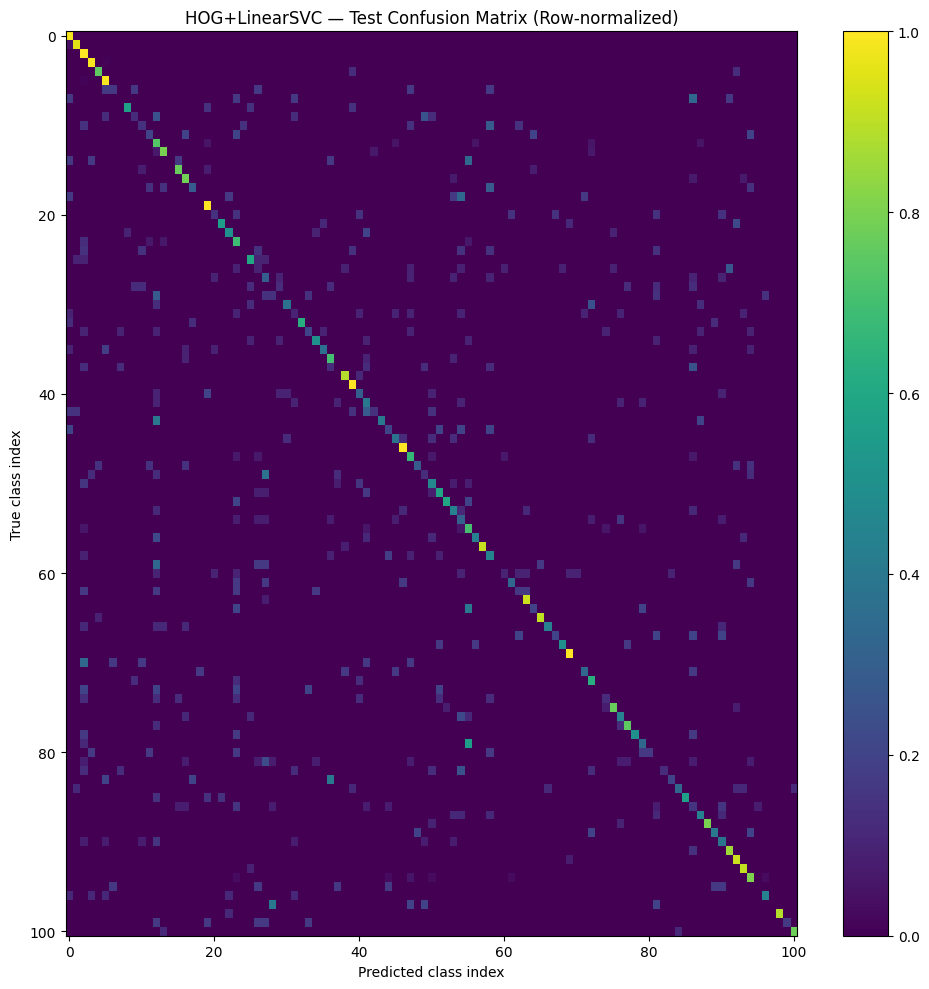

Saved: /content/drive/MyDrive/VictoriaClass/MiniProject1_v3/figures/cm_hog_linearsvc_test_row_normalized.png


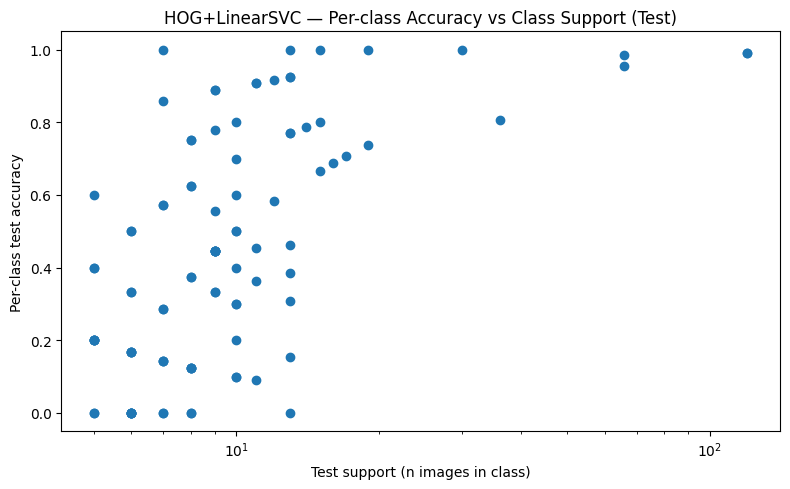

Saved: /content/drive/MyDrive/VictoriaClass/MiniProject1_v3/figures/per_class_acc_vs_support_hog_linearsvc_test.png
Saved: /content/drive/MyDrive/VictoriaClass/MiniProject1_v3/figures/bottom15_per_class_accuracy_hog_linearsvc_test.csv


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path("/content/drive/MyDrive/VictoriaClass/MiniProject1_v3")
RES_DIR = PROJECT_ROOT / "results" / "classical_hog_svm"
FIG_DIR = PROJECT_ROOT / "figures"
FIG_DIR.mkdir(exist_ok=True)

cm_path = RES_DIR / "test_confusion_matrix.npy"
pc_path = RES_DIR / "test_per_class_accuracy.csv"
assert cm_path.exists(), cm_path
assert pc_path.exists(), pc_path

cm = np.load(cm_path)
pc = pd.read_csv(pc_path)

# Figure 1: normalized confusion matrix
row_sums = cm.sum(axis=1, keepdims=True)
cm_norm = np.divide(cm, row_sums, out=np.zeros_like(cm, dtype=float), where=row_sums != 0)

plt.figure(figsize=(10, 10))
plt.imshow(cm_norm, aspect="auto")
plt.colorbar()
plt.title("HOG+LinearSVC — Test Confusion Matrix (Row-normalized)")
plt.xlabel("Predicted class index")
plt.ylabel("True class index")
fig1 = FIG_DIR / "cm_hog_linearsvc_test_row_normalized.png"
plt.tight_layout()
plt.savefig(fig1, dpi=200)
plt.show()
print("Saved:", fig1)

# Figure 2: per-class accuracy vs support (imbalance effect)
plt.figure(figsize=(8, 5))
plt.scatter(pc["test_support"], pc["test_accuracy"])
plt.title("HOG+LinearSVC — Per-class Accuracy vs Class Support (Test)")
plt.xlabel("Test support (n images in class)")
plt.ylabel("Per-class test accuracy")
plt.xscale("log")  # makes imbalance patterns visible
fig2 = FIG_DIR / "per_class_acc_vs_support_hog_linearsvc_test.png"
plt.tight_layout()
plt.savefig(fig2, dpi=200)
plt.show()
print("Saved:", fig2)

# Save a small "bottom-15" table
bottom15 = pc.sort_values("test_accuracy").head(15)
bottom_csv = FIG_DIR / "bottom15_per_class_accuracy_hog_linearsvc_test.csv"
bottom15.to_csv(bottom_csv, index=False)
print("Saved:", bottom_csv)

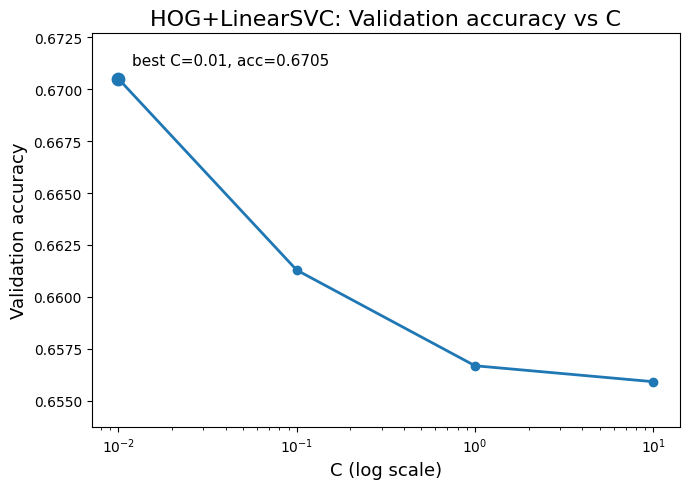

Saved: /content/drive/MyDrive/VictoriaClass/MiniProject1_v3/figures/c_sweep_hog_linearsvc_val.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path("/content/drive/MyDrive/VictoriaClass/MiniProject1_v3")
RES_DIR = PROJECT_ROOT / "results" / "classical_hog_svm"
FIG_DIR = PROJECT_ROOT / "figures"
FIG_DIR.mkdir(exist_ok=True)

csv_path = RES_DIR / "C_sweep_val.csv"
assert csv_path.exists(), f"Missing: {csv_path}"

df = pd.read_csv(csv_path).sort_values("C").reset_index(drop=True)

x = df["C"].astype(float).to_numpy()
y = df["val_accuracy"].astype(float).to_numpy()

best_i = int(y.argmax())
best_C = x[best_i]
best_acc = y[best_i]

# Tight y-axis range with small padding
ymin, ymax = float(y.min()), float(y.max())
pad = max(0.002, 0.15 * (ymax - ymin) if ymax > ymin else 0.002)
ylow, yhigh = ymin - pad, ymax + pad

plt.figure(figsize=(7, 5))
plt.plot(x, y, marker="o", linewidth=2)
plt.xscale("log")

plt.title("HOG+LinearSVC: Validation accuracy vs C", fontsize=16)
plt.xlabel("C (log scale)", fontsize=13)
plt.ylabel("Validation accuracy", fontsize=13)
plt.ylim(ylow, yhigh)

# Highlight best point
plt.scatter([best_C], [best_acc], s=80)
plt.annotate(
    f"best C={best_C:g}, acc={best_acc:.4f}",
    xy=(best_C, best_acc),
    xytext=(10, 10),
    textcoords="offset points",
    fontsize=11
)

out_path = FIG_DIR / "c_sweep_hog_linearsvc_val.png"
plt.tight_layout()
plt.savefig(out_path, dpi=200)
plt.show()

print("Saved:", out_path)

In [ ]:
# Top-k accuracy for HOG LinearSVC

import json
import numpy as np
from pathlib import Path
import joblib

PROJECT_ROOT = Path("/content/drive/MyDrive/VictoriaClass/MiniProject1_v3")
SEED = 42

MODEL_PATH = PROJECT_ROOT / "models" / "classical_hog_svm" / f"hog_rgb128_linearsvc_seed{SEED}_C0.01.joblib"
TEST_NPZ   = PROJECT_ROOT / "features" / "hog_128_rgb" / f"test_hog_128_rgb_seed{SEED}.npz"
SUMMARY_JSON = PROJECT_ROOT / "results" / "classical_hog_svm" / "test_summary.json"

assert MODEL_PATH.exists(), f"Missing model: {MODEL_PATH}"
assert TEST_NPZ.exists(), f"Missing test npz: {TEST_NPZ}"
assert SUMMARY_JSON.exists(), f"Missing summary json: {SUMMARY_JSON}"

clf = joblib.load(MODEL_PATH)
test = np.load(TEST_NPZ)
X_test, y_test = test["X"], test["y"]

scores = clf.decision_function(X_test)  # (N, n_classes) for multiclass OVR

# Ensure column order corresponds to class indices
classes = clf.classes_
if not np.array_equal(classes, np.arange(len(classes))):
    raise ValueError(f"Unexpected clf.classes_ ordering. First 10: {classes[:10]}")

def topk_accuracy(scores: np.ndarray, y_true: np.ndarray, k: int) -> float:
    topk = np.argsort(-scores, axis=1)[:, :k]
    return float(np.mean([y_true[i] in topk[i] for i in range(len(y_true))]))

top1 = topk_accuracy(scores, y_test, k=1)
top5 = topk_accuracy(scores, y_test, k=5)

print("TEST top-1 accuracy:", round(top1, 4))
print("TEST top-5 accuracy:", round(top5, 4))

# Update summary JSON
with open(SUMMARY_JSON, "r") as f:
    summary = json.load(f)

summary["top1_accuracy"] = top1
summary["top5_accuracy"] = top5

with open(SUMMARY_JSON, "w") as f:
    json.dump(summary, f, indent=2)

print("Updated:", SUMMARY_JSON)

TEST top-1 accuracy: 0.6452
TEST top-5 accuracy: 0.788
Updated: /content/drive/MyDrive/VictoriaClass/MiniProject1_v3/results/classical_hog_svm/test_summary.json


Num classes: 101
Sizes (train/val/test): 6073 1302 1302
Batch x: torch.Size([32, 3, 128, 128]) torch.float32
Batch y: torch.Size([32]) torch.int64 min/max: 0 100


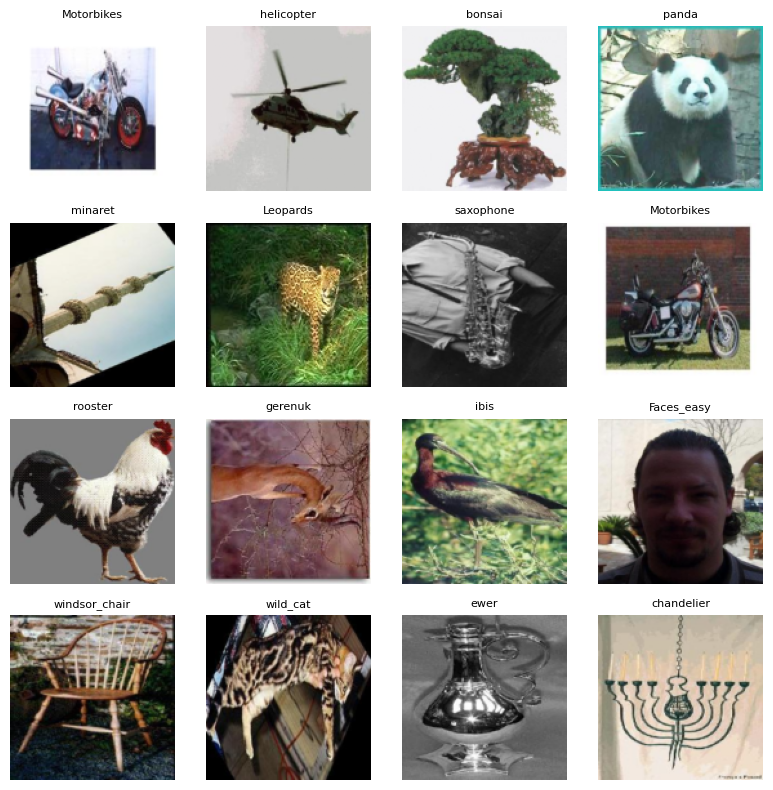


Locked deep settings for later:
 IMG_SIZE = 128 | BATCH_SIZE = 32 | LR = 0.0001 | EPOCHS = 100


In [ ]:
# Deep learning set-up (128x128 RGB, batch=32)

import pandas as pd
import numpy as np
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# Settings
SEED = 42
IMG_SIZE = 128
BATCH_SIZE = 32
LR = 1e-4
EPOCHS = 100

# Paths
PROJECT_ROOT = Path("/content/drive/MyDrive/VictoriaClass/MiniProject1_v3")
SPLITS_DIR = PROJECT_ROOT / "splits"
MAP_CSV = SPLITS_DIR / "class_to_idx.csv"

train_csv = SPLITS_DIR / f"train_seed{SEED}.csv"
val_csv   = SPLITS_DIR / f"val_seed{SEED}.csv"
test_csv  = SPLITS_DIR / f"test_seed{SEED}.csv"

for p in [train_csv, val_csv, test_csv, MAP_CSV]:
    assert p.exists(), f"Missing: {p}"

# Class mapping
m = pd.read_csv(MAP_CSV).sort_values("class_idx")
idx_to_class = m["class_name"].tolist()
n_classes = len(idx_to_class)
print("Num classes:", n_classes)

# Transforms: 128x128 RGB and ImageNet normalization
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std =[0.229, 0.224, 0.225])

train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    normalize,
])

eval_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    normalize,
])

class CaltechCSVDataset(Dataset):
    def __init__(self, csv_path, transform):
        self.df = pd.read_csv(csv_path)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        fp = self.df.loc[idx, "path"]
        y  = int(self.df.loc[idx, "class_idx"])
        with Image.open(fp) as im:
            im = im.convert("RGB")
            x = self.transform(im)
        return x, y

train_ds = CaltechCSVDataset(train_csv, train_tfms)
val_ds   = CaltechCSVDataset(val_csv,   eval_tfms)
test_ds  = CaltechCSVDataset(test_csv,  eval_tfms)

print("Sizes (train/val/test):", len(train_ds), len(val_ds), len(test_ds))

# DataLoaders (batch=32)
NUM_WORKERS = 2

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

# One batch check
xb, yb = next(iter(train_loader))
print("Batch x:", xb.shape, xb.dtype)
print("Batch y:", yb.shape, yb.dtype, "min/max:", int(yb.min()), int(yb.max()))

# Visualization grid
def unnormalize(x):
    mean = torch.tensor([0.485, 0.456, 0.406], device=x.device)[None, :, None, None]
    std  = torch.tensor([0.229, 0.224, 0.225], device=x.device)[None, :, None, None]
    return x * std + mean

grid = unnormalize(xb[:16]).clamp(0, 1).permute(0, 2, 3, 1).cpu().numpy()

plt.figure(figsize=(8, 8))
for i in range(16):
    plt.subplot(4, 4, i+1)
    plt.imshow(grid[i])
    plt.title(idx_to_class[int(yb[i])], fontsize=8)
    plt.axis("off")
plt.tight_layout()
plt.show()

print("\nLocked deep settings for later:")
print(" IMG_SIZE =", IMG_SIZE, "| BATCH_SIZE =", BATCH_SIZE, "| LR =", LR, "| EPOCHS =", EPOCHS)

In [ ]:
# SimpleCNN from scratch

import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=101, dropout=0.3):
        super().__init__()
        self.features = nn.Sequential(
            # 128x128
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 64x64

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 32x32

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 16x16

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 8x8
        )

        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Flatten(),
            nn.Linear(256 * 8 * 8, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleCNN(num_classes=n_classes, dropout=0.3).to(device)

# Parameter count
n_params = sum(p.numel() for p in model.parameters())
print("Model:", model.__class__.__name__)
print("Parameters:", f"{n_params:,}")

# Forward pass check
xb, yb = next(iter(train_loader))
xb = xb.to(device)
with torch.no_grad():
    logits = model(xb)
print("Logits shape:", logits.shape)  # [batch, 101]

Model: SimpleCNN
Parameters: 8,830,309
Logits shape: torch.Size([32, 101])


In [ ]:
# Setup for SimpleCNN training (lr=1e-4, batch=32, epochs=100)

import json, random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from pathlib import Path

# Settings
SEED = 42
IMG_SIZE = 128
BATCH_SIZE = 32
LR = 1e-4
EPOCHS = 100

# Reproducibility
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Output dirs
PROJECT_ROOT = Path("/content/drive/MyDrive/VictoriaClass/MiniProject1_v3")
MODEL_NAME = "deep_simplecnn"

MODEL_DIR   = PROJECT_ROOT / "models"  / MODEL_NAME
RESULTS_DIR = PROJECT_ROOT / "results" / MODEL_NAME
FIG_DIR     = PROJECT_ROOT / "figures" / MODEL_NAME
for d in [MODEL_DIR, RESULTS_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

best_ckpt_path = MODEL_DIR / "best.pt"

# Loss and optimizer
model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

# Save run config
run_cfg = {
    "model": "SimpleCNN",
    "input_size": [IMG_SIZE, IMG_SIZE],
    "channels": 3,
    "normalization": "ImageNet",
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "optimizer": "Adam",
    "lr": LR,
    "loss": "CrossEntropyLoss",
    "seed_split": SEED,
    "seed_torch": SEED,
    "augmentation": "off (base run)",
    "checkpoint_best": str(best_ckpt_path),
}
cfg_path = RESULTS_DIR / "run_config.json"
cfg_path.write_text(json.dumps(run_cfg, indent=2))

print("Device:", device)
print(f"Config: IMG_SIZE={IMG_SIZE} | BATCH_SIZE={BATCH_SIZE} | LR={LR} | EPOCHS={EPOCHS} | SEED={SEED}")
print("Checkpoint path:", best_ckpt_path)
print("Wrote run config:", cfg_path)
print("Optimizer:", type(optimizer).__name__, "lr=", optimizer.param_groups[0]["lr"])

Device: cuda
Config: IMG_SIZE=128 | BATCH_SIZE=32 | LR=0.0001 | EPOCHS=100 | SEED=42
Checkpoint path: /content/drive/MyDrive/VictoriaClass/MiniProject1_v3/models/deep_simplecnn/best.pt
Wrote run config: /content/drive/MyDrive/VictoriaClass/MiniProject1_v3/results/deep_simplecnn/run_config.json
Optimizer: Adam lr= 0.0001


In [ ]:
# Step 4: Train SimpleCNN (100 epochs)

import time
import pandas as pd
import torch

def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)

    total_loss = 0.0
    total_correct = 0
    total_n = 0

    if not is_train:
        with torch.no_grad():
            for xb, yb in loader:
                xb = xb.to(device, non_blocking=True)
                yb = yb.to(device, non_blocking=True)

                logits = model(xb)
                loss = criterion(logits, yb)

                total_loss += float(loss.item()) * xb.size(0)
                preds = torch.argmax(logits, dim=1)
                total_correct += int((preds == yb).sum().item())
                total_n += int(xb.size(0))
    else:
        for xb, yb in loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            logits = model(xb)
            loss = criterion(logits, yb)

            loss.backward()
            optimizer.step()

            total_loss += float(loss.item()) * xb.size(0)
            preds = torch.argmax(logits, dim=1)
            total_correct += int((preds == yb).sum().item())
            total_n += int(xb.size(0))

    return total_loss / total_n, total_correct / total_n

history = []
best_val_acc = -1.0
best_epoch = -1

t_start = time.time()
for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    train_loss, train_acc = run_epoch(model, train_loader, optimizer=optimizer)
    val_loss, val_acc     = run_epoch(model, val_loader, optimizer=None)

    dt = time.time() - t0

    # Save best checkpoint (by val acc)
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch
        torch.save(
            {
                "model_state": model.state_dict(),
                "epoch": epoch,
                "val_acc": val_acc,
                "train_acc": train_acc,
                "config": {"epochs": EPOCHS, "batch_size": BATCH_SIZE, "lr": LR},
            },
            best_ckpt_path
        )

    history.append({
        "epoch": epoch,
        "train_loss": train_loss, "train_acc": train_acc,
        "val_loss": val_loss,     "val_acc": val_acc,
        "sec": dt
    })

    print(f"Epoch {epoch:03d}/{EPOCHS} | "
          f"train loss {train_loss:.4f} acc {train_acc:.4f} | "
          f"val loss {val_loss:.4f} acc {val_acc:.4f} | "
          f"{dt:.1f}s")

# Save training log
log_df = pd.DataFrame(history)
log_path = RESULTS_DIR / "training_log.csv"
log_df.to_csv(log_path, index=False)

print("\nBest val acc:", round(best_val_acc, 4), "at epoch", best_epoch)
print("Saved best checkpoint:", best_ckpt_path)
print("Saved training log:", log_path)
print("Total training time (min):", round((time.time() - t_start) / 60, 2))

Epoch 001/100 | train loss 3.2782 acc 0.3249 | val loss 2.6314 acc 0.4240 | 16.6s
Epoch 002/100 | train loss 2.3046 acc 0.4887 | val loss 2.0354 acc 0.5430 | 14.5s
Epoch 003/100 | train loss 1.7300 acc 0.5995 | val loss 1.6821 acc 0.6198 | 15.2s
Epoch 004/100 | train loss 1.3447 acc 0.6720 | val loss 1.4690 acc 0.6705 | 15.7s
Epoch 005/100 | train loss 1.0514 acc 0.7428 | val loss 1.3460 acc 0.6920 | 15.7s
Epoch 006/100 | train loss 0.8550 acc 0.7887 | val loss 1.2551 acc 0.7104 | 15.6s
Epoch 007/100 | train loss 0.6819 acc 0.8342 | val loss 1.1514 acc 0.7235 | 16.4s
Epoch 008/100 | train loss 0.5425 acc 0.8716 | val loss 1.1374 acc 0.7327 | 15.7s
Epoch 009/100 | train loss 0.4511 acc 0.8946 | val loss 1.0837 acc 0.7320 | 15.8s
Epoch 010/100 | train loss 0.3471 acc 0.9211 | val loss 1.0613 acc 0.7465 | 14.6s
Epoch 011/100 | train loss 0.2875 acc 0.9399 | val loss 1.0331 acc 0.7366 | 15.1s
Epoch 012/100 | train loss 0.2241 acc 0.9550 | val loss 1.0628 acc 0.7358 | 14.6s
Epoch 013/100 | 

In [3]:
import os, shutil
from google.colab import drive

MOUNTPOINT = "/content/drive"

# 1) Try unmounting (safe even if not mounted)
try:
    drive.flush_and_unmount()
    print("Flushed/unmounted (or nothing to unmount).")
except Exception as e:
    print("flush_and_unmount exception (usually ok):", repr(e))

# 2) Ensure mountpoint exists and is empty
os.makedirs(MOUNTPOINT, exist_ok=True)

# remove any existing contents inside /content/drive
for name in os.listdir(MOUNTPOINT):
    p = os.path.join(MOUNTPOINT, name)
    try:
        if os.path.isdir(p) and not os.path.islink(p):
            shutil.rmtree(p)
        else:
            os.remove(p)
    except Exception as e:
        print("Could not remove:", p, "->", repr(e))

print("Mountpoint contents after cleanup:", os.listdir(MOUNTPOINT))

# 3) Mount again
drive.mount(MOUNTPOINT)

Drive not mounted, so nothing to flush and unmount.
Flushed/unmounted (or nothing to unmount).
Mountpoint contents after cleanup: []
Mounted at /content/drive


In [ ]:
from pathlib import Path
PROJECT_ROOT = Path("/content/drive/MyDrive/VictoriaClass/MiniProject1_v3")
ckpt_path = PROJECT_ROOT / "models" / "deep_simplecnn" / "best.pt"
print("Checkpoint exists:", ckpt_path.exists(), "|", ckpt_path)

Checkpoint exists: True | /content/drive/MyDrive/VictoriaClass/MiniProject1_v3/models/deep_simplecnn/best.pt


In [ ]:
# Rebuild loaders since runtime restarted

import pandas as pd
from pathlib import Path
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# Locked settings
SEED = 42
IMG_SIZE = 128
BATCH_SIZE = 32
NUM_WORKERS = 2

PROJECT_ROOT = Path("/content/drive/MyDrive/VictoriaClass/MiniProject1_v3")
SPLITS_DIR = PROJECT_ROOT / "splits"
MAP_CSV = SPLITS_DIR / "class_to_idx.csv"

train_csv = SPLITS_DIR / f"train_seed{SEED}.csv"
val_csv   = SPLITS_DIR / f"val_seed{SEED}.csv"
test_csv  = SPLITS_DIR / f"test_seed{SEED}.csv"

for p in [train_csv, val_csv, test_csv, MAP_CSV]:
    assert p.exists(), f"Missing: {p}"

m = pd.read_csv(MAP_CSV).sort_values("class_idx")
idx_to_class = m["class_name"].tolist()
n_classes = len(idx_to_class)

normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std =[0.229, 0.224, 0.225])

train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    normalize,
])
eval_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    normalize,
])

class CaltechCSVDataset(Dataset):
    def __init__(self, csv_path, transform):
        self.df = pd.read_csv(csv_path)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        fp = self.df.loc[idx, "path"]
        y  = int(self.df.loc[idx, "class_idx"])
        with Image.open(fp) as im:
            im = im.convert("RGB")
            x = self.transform(im)
        return x, y

test_ds = CaltechCSVDataset(test_csv, eval_tfms)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device, "| test n:", len(test_ds), "| batch:", BATCH_SIZE)

device: cuda | test n: 1302 | batch: 32


In [ ]:
# Recreate architecture since runtime restarted

import torch.nn as nn
import torch

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=101, dropout=0.3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Flatten(),
            nn.Linear(256 * 8 * 8, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

model = SimpleCNN(num_classes=n_classes, dropout=0.3).to(device)
print("Model recreated. Params:", sum(p.numel() for p in model.parameters()))

Model recreated. Params: 8830309


In [4]:
# Reload dataset since runtime restarted

!pip -q install -U kagglehub
import os, getpass
import kagglehub

# Set token
os.environ["KAGGLE_API_TOKEN"] = getpass.getpass("KAGGLE_API_TOKEN")

path = kagglehub.dataset_download("imbikramsaha/caltech-101")
print("Downloaded to:", path)

# Check one file
test_fp = "/root/.cache/kagglehub/datasets/imbikramsaha/caltech-101/versions/1/caltech-101/Motorbikes/image_0701.jpg"
print("Exists now?", os.path.exists(test_fp))

KAGGLE_API_TOKEN··········
Using Colab cache for faster access to the 'caltech-101' dataset.
Downloaded to: /kaggle/input/caltech-101
Exists now? False


In [ ]:
# Evaluate CNN from scratch on test

import json
import numpy as np
import pandas as pd
from pathlib import Path
import torch
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Paths
PROJECT_ROOT = Path("/content/drive/MyDrive/VictoriaClass/MiniProject1_v3")
SPLITS_DIR = PROJECT_ROOT / "splits"
MAP_CSV = SPLITS_DIR / "class_to_idx.csv"

MODEL_NAME = "deep_simplecnn"
MODEL_DIR   = PROJECT_ROOT / "models"  / MODEL_NAME
RESULTS_DIR = PROJECT_ROOT / "results" / MODEL_NAME
FIG_DIR     = PROJECT_ROOT / "figures" / MODEL_NAME
for d in [RESULTS_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

ckpt_path = MODEL_DIR / "best.pt"
assert ckpt_path.exists(), f"Missing checkpoint: {ckpt_path}"
assert MAP_CSV.exists(), f"Missing: {MAP_CSV}"

# Class mapping
m = pd.read_csv(MAP_CSV).sort_values("class_idx")
idx_to_class = m["class_name"].tolist()
n_classes = len(idx_to_class)
labels = list(range(n_classes))

# Load best checkpoint
ckpt = torch.load(ckpt_path, map_location=device)
model.load_state_dict(ckpt["model_state"])
model.eval()

# Predict on test
all_y = []
all_pred = []
all_probs = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device, non_blocking=True)
        logits = model(xb)                       # [B, 101]
        probs  = torch.softmax(logits, dim=1)    # [B, 101]

        pred = torch.argmax(logits, dim=1).cpu().numpy()
        all_pred.append(pred)
        all_y.append(yb.numpy())
        all_probs.append(probs.cpu().numpy())

y_true = np.concatenate(all_y)
y_pred = np.concatenate(all_pred)
probs  = np.concatenate(all_probs)  # [N, 101]

# ---- Metrics ----
acc = accuracy_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred, labels=labels)

row_sums = cm.sum(axis=1)
per_class_acc = np.divide(
    np.diag(cm), row_sums,
    out=np.zeros_like(row_sums, dtype=float),
    where=row_sums != 0
)

report = classification_report(
    y_true, y_pred,
    labels=labels,
    target_names=idx_to_class,
    output_dict=True,
    zero_division=0
)

def topk_acc(probs, y_true, k):
    topk = np.argsort(-probs, axis=1)[:, :k]
    return float(np.mean([y_true[i] in topk[i] for i in range(len(y_true))]))

top1 = float(acc)
top5 = topk_acc(probs, y_true, k=5)

print("Loaded checkpoint epoch:", int(ckpt.get("epoch", -1)), "| best_val_acc:", float(ckpt.get("val_acc", -1)))
print("TEST top-1 accuracy:", round(top1, 4))
print("TEST top-5 accuracy:", round(top5, 4))
print("Macro avg (P/R/F1):",
      round(report["macro avg"]["precision"], 4),
      round(report["macro avg"]["recall"], 4),
      round(report["macro avg"]["f1-score"], 4))
print("Weighted avg (P/R/F1):",
      round(report["weighted avg"]["precision"], 4),
      round(report["weighted avg"]["recall"], 4),
      round(report["weighted avg"]["f1-score"], 4))

# Save outputs
summary = {
    "model": "SimpleCNN (scratch)",
    "preprocessing": "RGB resize to 128x128 + ImageNet normalization",
    "epochs_trained": 100,
    "checkpoint_epoch": int(ckpt.get("epoch", -1)),
    "best_val_acc": float(ckpt.get("val_acc", -1)),
    "test_accuracy": float(top1),
    "top1_accuracy": float(top1),
    "top5_accuracy": float(top5),
    "macro_avg": {
        "precision": float(report["macro avg"]["precision"]),
        "recall": float(report["macro avg"]["recall"]),
        "f1": float(report["macro avg"]["f1-score"]),
    },
    "weighted_avg": {
        "precision": float(report["weighted avg"]["precision"]),
        "recall": float(report["weighted avg"]["recall"]),
        "f1": float(report["weighted avg"]["f1-score"]),
    }
}
(RESULTS_DIR / "test_summary.json").write_text(json.dumps(summary, indent=2))

pc_df = pd.DataFrame({
    "class_idx": np.arange(n_classes),
    "class_name": idx_to_class,
    "n_test": row_sums,
    "test_per_class_acc": per_class_acc
}).sort_values("test_per_class_acc")
pc_df.to_csv(RESULTS_DIR / "test_per_class_accuracy.csv", index=False)

(RESULTS_DIR / "test_classification_report.json").write_text(json.dumps(report, indent=2))
np.save(RESULTS_DIR / "test_confusion_matrix.npy", cm)

print("\nSaved outputs to:", RESULTS_DIR)
print(" - test_summary.json")
print(" - test_per_class_accuracy.csv")
print(" - test_classification_report.json")
print(" - test_confusion_matrix.npy")

Loaded checkpoint epoch: 67 | best_val_acc: 0.7780337941628265
TEST top-1 accuracy: 0.755
TEST top-5 accuracy: 0.8955
Macro avg (P/R/F1): 0.6815 0.6215 0.6273
Weighted avg (P/R/F1): 0.7697 0.755 0.7477

Saved outputs to: /content/drive/MyDrive/VictoriaClass/MiniProject1_v3/results/deep_simplecnn
 - test_summary.json
 - test_per_class_accuracy.csv
 - test_classification_report.json
 - test_confusion_matrix.npy


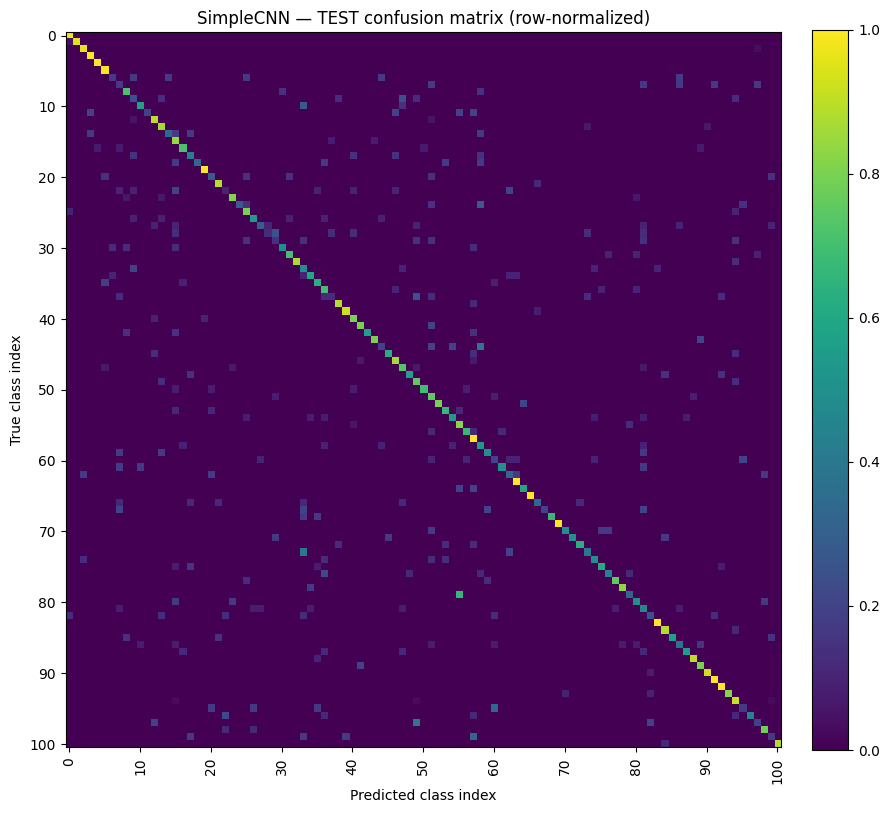

Saved: /content/drive/MyDrive/VictoriaClass/MiniProject1_v3/figures/deep_simplecnn/cm_simplecnn_test_row_normalized.png


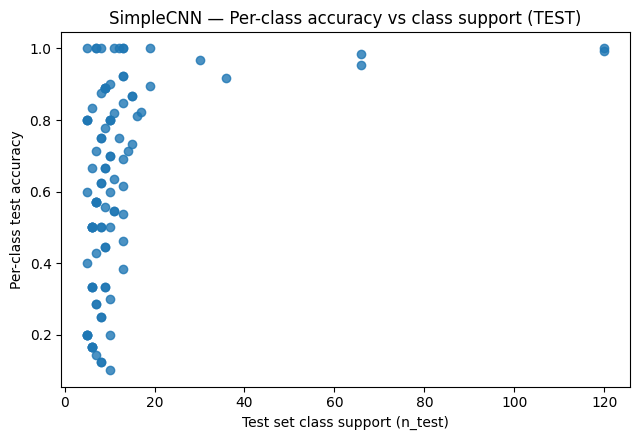

Saved: /content/drive/MyDrive/VictoriaClass/MiniProject1_v3/figures/deep_simplecnn/per_class_acc_vs_support_simplecnn_test.png
Saved: /content/drive/MyDrive/VictoriaClass/MiniProject1_v3/figures/deep_simplecnn/bottom15_per_class_accuracy_simplecnn_test.csv


,class_idx,class_name,n_test,test_per_class_acc
0,22,chair,10,0.100000
1,28,crocodile,8,0.125000
2,37,emu,8,0.125000
3,29,crocodile_head,7,0.142857
4,7,ant,6,0.166667
5,6,anchor,6,0.166667
6,99,wrench,6,0.166667
7,95,water_lilly,6,0.166667
8,60,lotus,10,0.200000
9,97,wild_cat,5,0.200000


In [ ]:
# Figures for CNN from scratch

import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

# Paths
PROJECT_ROOT = Path("/content/drive/MyDrive/VictoriaClass/MiniProject1_v3")
MODEL_NAME = "deep_simplecnn"

RES_DIR   = PROJECT_ROOT / "results" / MODEL_NAME
FIG_DIR   = PROJECT_ROOT / "figures" / MODEL_NAME
SPLITS_DIR = PROJECT_ROOT / "splits"
FIG_DIR.mkdir(parents=True, exist_ok=True)

pc_csv  = RES_DIR / "test_per_class_accuracy.csv"
cm_path = RES_DIR / "test_confusion_matrix.npy"
map_csv = SPLITS_DIR / "class_to_idx.csv"

for p in [pc_csv, cm_path, map_csv]:
    assert p.exists(), f"Missing: {p}"

pc = pd.read_csv(pc_csv)
cm = np.load(cm_path)

m = pd.read_csv(map_csv).sort_values("class_idx")
idx_to_class = m["class_name"].tolist()
n = len(idx_to_class)
assert cm.shape == (n, n), f"Expected {(n,n)}, got {cm.shape}"

# Row-normalized confusion matrix
row_sums = cm.sum(axis=1, keepdims=True)
cm_norm = np.divide(cm, row_sums, out=np.zeros_like(cm, dtype=float), where=row_sums != 0)

plt.figure(figsize=(9, 9))
im = plt.imshow(cm_norm, interpolation="nearest")
plt.title("SimpleCNN — TEST confusion matrix (row-normalized)")
plt.xlabel("Predicted class index")
plt.ylabel("True class index")
plt.colorbar(im, fraction=0.046, pad=0.04)

step = 10
ticks = list(range(0, n, step))
plt.xticks(ticks, ticks, rotation=90)
plt.yticks(ticks, ticks)

cm_fig_path = FIG_DIR / "cm_simplecnn_test_row_normalized.png"
plt.tight_layout()
plt.savefig(cm_fig_path, dpi=200)
plt.show()
print("Saved:", cm_fig_path)

# Per-class accuracy vs class support
assert "n_test" in pc.columns, f"Expected 'n_test' column in {pc_csv.name}"
assert "test_per_class_acc" in pc.columns, f"Expected 'test_per_class_acc' column in {pc_csv.name}"

plt.figure(figsize=(6.5, 4.5))
plt.scatter(pc["n_test"].values, pc["test_per_class_acc"].values, alpha=0.8)
plt.xlabel("Test set class support (n_test)")
plt.ylabel("Per-class test accuracy")
plt.title("SimpleCNN — Per-class accuracy vs class support (TEST)")
plt.tight_layout()

acc_support_fig = FIG_DIR / "per_class_acc_vs_support_simplecnn_test.png"
plt.savefig(acc_support_fig, dpi=200)
plt.show()
print("Saved:", acc_support_fig)

# Bottom-k per-class accuracy table
K = 15
bottomk = pc.sort_values("test_per_class_acc").head(K)[
    ["class_idx", "class_name", "n_test", "test_per_class_acc"]
].copy()

bottomk_path = FIG_DIR / "bottom15_per_class_accuracy_simplecnn_test.csv"
bottomk.to_csv(bottomk_path, index=False)
print("Saved:", bottomk_path)

bottomk

In [ ]:
# Restore deep-learning variables after runtime restart

import pandas as pd
from pathlib import Path
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# Design choices
SEED = 42
IMG_SIZE = 128
BATCH_SIZE = 32
LR = 1e-4
EPOCHS = 100

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

PROJECT_ROOT = Path("/content/drive/MyDrive/VictoriaClass/MiniProject1_v3")
SPLITS_DIR = PROJECT_ROOT / "splits"
MAP_CSV = SPLITS_DIR / "class_to_idx.csv"

train_csv = SPLITS_DIR / f"train_seed{SEED}.csv"
val_csv   = SPLITS_DIR / f"val_seed{SEED}.csv"
test_csv  = SPLITS_DIR / f"test_seed{SEED}.csv"

for p in [train_csv, val_csv, test_csv, MAP_CSV]:
    assert p.exists(), f"Missing: {p}"

# Class mapping
m = pd.read_csv(MAP_CSV).sort_values("class_idx")
idx_to_class = m["class_name"].tolist()
n_classes = len(idx_to_class)

# Preprocessing 128x128 RGB and ImageNet normalization
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std =[0.229, 0.224, 0.225])

train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    normalize,
])

eval_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    normalize,
])

class CaltechCSVDataset(Dataset):
    def __init__(self, csv_path: Path, transform):
        self.df = pd.read_csv(csv_path)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        fp = self.df.loc[idx, "path"]
        y  = int(self.df.loc[idx, "class_idx"])
        with Image.open(fp) as im:
            im = im.convert("RGB")
            x = self.transform(im)
        return x, y

train_ds = CaltechCSVDataset(train_csv, train_tfms)
val_ds   = CaltechCSVDataset(val_csv,   eval_tfms)
test_ds  = CaltechCSVDataset(test_csv,  eval_tfms)

NUM_WORKERS = 2
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

# Quick sanity check
xb, yb = next(iter(train_loader))
print("Device:", device)
print(f"Locked deep settings: IMG_SIZE={IMG_SIZE} | BATCH_SIZE={BATCH_SIZE} | LR={LR} | EPOCHS={EPOCHS} | SEED={SEED}")
print("Num classes:", n_classes)
print("Batch x:", xb.shape, xb.dtype)
print("Batch y:", yb.shape, yb.dtype, "min/max:", int(yb.min()), int(yb.max()))

Device: cuda
Locked deep settings: IMG_SIZE=128 | BATCH_SIZE=32 | LR=0.0001 | EPOCHS=100 | SEED=42
Num classes: 101
Batch x: torch.Size([32, 3, 128, 128]) torch.float32
Batch y: torch.Size([32]) torch.int64 min/max: 0 94


In [ ]:
# ResNet18 ImageNet pretrained full fine-tune training and test evaluation

import time, json, random
import numpy as np
import pandas as pd
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

assert "device" in globals()
assert "train_loader" in globals() and "val_loader" in globals() and "test_loader" in globals()
assert "idx_to_class" in globals() and "n_classes" in globals()
assert "IMG_SIZE" in globals() and "BATCH_SIZE" in globals() and "LR" in globals() and "EPOCHS" in globals()

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

PROJECT_ROOT = Path("/content/drive/MyDrive/VictoriaClass/MiniProject1_v3")

MODEL_NAME = "deep_resnet18"
MODEL_DIR   = PROJECT_ROOT / "models"  / MODEL_NAME
RESULTS_DIR = PROJECT_ROOT / "results" / MODEL_NAME
FIG_DIR     = PROJECT_ROOT / "figures" / MODEL_NAME
for d in [MODEL_DIR, RESULTS_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

best_ckpt_path = MODEL_DIR / "best.pt"

print("Device:", device)
print(f"Config: IMG_SIZE={IMG_SIZE} | BATCH_SIZE={BATCH_SIZE} | LR={LR} | EPOCHS={EPOCHS} | SEED={SEED}")
print("Checkpoint:", best_ckpt_path)

# Build model
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
resnet.fc = nn.Linear(resnet.fc.in_features, n_classes)
resnet = resnet.to(device)

# Full fine-tuning
for p in resnet.parameters():
    p.requires_grad = True

total_params = sum(p.numel() for p in resnet.parameters())
trainable_params = sum(p.numel() for p in resnet.parameters() if p.requires_grad)
print("Model: ResNet18 (pretrained, full fine-tune)")
print("Total params:", f"{total_params:,} | Trainable:", f"{trainable_params:,}")

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(resnet.parameters(), lr=LR)

# Save run config
run_cfg = {
    "model": "ResNet18 (ImageNet pretrained, full fine-tune)",
    "input_size": [int(IMG_SIZE), int(IMG_SIZE)],
    "channels": 3,
    "normalization": "ImageNet (mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])",
    "epochs_budget": int(EPOCHS),
    "batch_size": int(BATCH_SIZE),
    "optimizer": "Adam",
    "lr": float(LR),
    "loss": "CrossEntropyLoss",
    "seed_split": 42,
    "seed_torch": 42,
    "augmentation": "off (base run)",
    "checkpoint_best": str(best_ckpt_path),
}
(RESULTS_DIR / "run_config.json").write_text(json.dumps(run_cfg, indent=2))
print("Wrote run config:", RESULTS_DIR / "run_config.json")

# Train and Val loop
def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)

    total_loss = 0.0
    total_correct = 0
    total_n = 0

    if not is_train:
        torch.set_grad_enabled(False)

    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        logits = model(xb)
        loss = criterion(logits, yb)

        if is_train:
            loss.backward()
            optimizer.step()

        total_loss += float(loss.item()) * xb.size(0)
        total_correct += int((logits.argmax(dim=1) == yb).sum().item())
        total_n += int(xb.size(0))

    if not is_train:
        torch.set_grad_enabled(True)

    return total_loss / total_n, total_correct / total_n

history = []
best_val_acc = -1.0
best_epoch = -1

t_start = time.time()
for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    train_loss, train_acc = run_epoch(resnet, train_loader, optimizer=optimizer)
    val_loss, val_acc     = run_epoch(resnet, val_loader, optimizer=None)
    dt = time.time() - t0

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch
        torch.save(
            {"model_state": resnet.state_dict(), "epoch": epoch, "val_acc": val_acc},
            best_ckpt_path
        )

    history.append({
        "epoch": epoch,
        "train_loss": train_loss, "train_acc": train_acc,
        "val_loss": val_loss,     "val_acc": val_acc,
        "sec": dt
    })

    print(f"Epoch {epoch:03d}/{EPOCHS} | "
          f"train loss {train_loss:.4f} acc {train_acc:.4f} | "
          f"val loss {val_loss:.4f} acc {val_acc:.4f} | "
          f"{dt:.1f}s")

log_df = pd.DataFrame(history)
log_path = RESULTS_DIR / "training_log.csv"
log_df.to_csv(log_path, index=False)

print("\nBest val acc:", round(best_val_acc, 4), "at epoch", best_epoch)
print("Saved best checkpoint:", best_ckpt_path)
print("Saved training log:", log_path)
print("Total training time (min):", round((time.time() - t_start) / 60, 2))

# Test evaluation using best checkpoint
assert best_ckpt_path.exists(), f"Missing checkpoint: {best_ckpt_path}"
ckpt = torch.load(best_ckpt_path, map_location=device)
resnet.load_state_dict(ckpt["model_state"])
resnet.eval()

all_y, all_pred, all_scores = [], [], []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device, non_blocking=True)
        logits = resnet(xb)
        probs = torch.softmax(logits, dim=1)

        all_scores.append(probs.cpu().numpy())
        all_pred.append(logits.argmax(dim=1).cpu().numpy())
        all_y.append(yb.numpy())

y_true = np.concatenate(all_y)
y_pred = np.concatenate(all_pred)
scores = np.concatenate(all_scores)

labels = list(range(n_classes))
acc = accuracy_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred, labels=labels)

row_sums = cm.sum(axis=1)
per_class_acc = np.divide(
    np.diag(cm), row_sums,
    out=np.zeros_like(row_sums, dtype=float),
    where=row_sums != 0
)

report = classification_report(
    y_true, y_pred,
    labels=labels,
    target_names=idx_to_class,
    output_dict=True,
    zero_division=0
)

def topk_acc(scores, y_true, k):
    topk = np.argsort(-scores, axis=1)[:, :k]
    return float(np.mean([y_true[i] in topk[i] for i in range(len(y_true))]))

top1 = float(acc)
top5 = topk_acc(scores, y_true, 5)

print("\nLoaded checkpoint epoch:", ckpt.get("epoch", -1), "| best_val_acc:", ckpt.get("val_acc", -1))
print("TEST top-1 accuracy:", round(top1, 4))
print("TEST top-5 accuracy:", round(top5, 4))
print("Macro avg (P/R/F1):",
      round(report["macro avg"]["precision"], 4),
      round(report["macro avg"]["recall"], 4),
      round(report["macro avg"]["f1-score"], 4))
print("Weighted avg (P/R/F1):",
      round(report["weighted avg"]["precision"], 4),
      round(report["weighted avg"]["recall"], 4),
      round(report["weighted avg"]["f1-score"], 4))

summary = {
    "model": "ResNet18 (ImageNet pretrained, FULL fine-tune)",
    "preprocessing": "RGB resize to 128x128 + ImageNet normalization",
    "epochs_budget": int(EPOCHS),
    "best_epoch": int(ckpt.get("epoch", -1)),
    "best_val_acc": float(ckpt.get("val_acc", -1)),
    "batch_size": int(BATCH_SIZE),
    "optimizer": "Adam",
    "lr": float(LR),
    "test_accuracy": float(acc),
    "top1_accuracy": float(top1),
    "top5_accuracy": float(top5),
    "macro_avg": {
        "precision": float(report["macro avg"]["precision"]),
        "recall": float(report["macro avg"]["recall"]),
        "f1": float(report["macro avg"]["f1-score"]),
    },
    "weighted_avg": {
        "precision": float(report["weighted avg"]["precision"]),
        "recall": float(report["weighted avg"]["recall"]),
        "f1": float(report["weighted avg"]["f1-score"]),
    },
}

with open(RESULTS_DIR / "test_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

pd.DataFrame({
    "class_idx": np.arange(n_classes),
    "class_name": idx_to_class,
    "n_test": row_sums,
    "test_per_class_acc": per_class_acc
}).sort_values("test_per_class_acc").to_csv(RESULTS_DIR / "test_per_class_accuracy.csv", index=False)

with open(RESULTS_DIR / "test_classification_report.json", "w") as f:
    json.dump(report, f, indent=2)

np.save(RESULTS_DIR / "test_confusion_matrix.npy", cm)

print("\nSaved outputs to:", RESULTS_DIR)
print(" - test_summary.json")
print(" - test_per_class_accuracy.csv")
print(" - test_classification_report.json")
print(" - test_confusion_matrix.npy")

Device: cuda
Config: IMG_SIZE=128 | BATCH_SIZE=32 | LR=0.0001 | EPOCHS=100 | SEED=42
Checkpoint: /content/drive/MyDrive/VictoriaClass/MiniProject1_v3/models/deep_resnet18/best.pt
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 139MB/s]


Model: ResNet18 (pretrained, full fine-tune)
Total params: 11,228,325 | Trainable: 11,228,325
Wrote run config: /content/drive/MyDrive/VictoriaClass/MiniProject1_v3/results/deep_resnet18/run_config.json
Epoch 001/100 | train loss 1.7124 acc 0.6603 | val loss 0.5808 acc 0.8871 | 15.9s
Epoch 002/100 | train loss 0.2774 acc 0.9625 | val loss 0.3230 acc 0.9293 | 15.3s
Epoch 003/100 | train loss 0.0707 acc 0.9957 | val loss 0.2814 acc 0.9293 | 16.2s
Epoch 004/100 | train loss 0.0268 acc 0.9995 | val loss 0.2510 acc 0.9424 | 15.2s
Epoch 005/100 | train loss 0.0149 acc 1.0000 | val loss 0.2375 acc 0.9409 | 16.3s
Epoch 006/100 | train loss 0.0100 acc 1.0000 | val loss 0.2326 acc 0.9432 | 15.1s
Epoch 007/100 | train loss 0.0078 acc 1.0000 | val loss 0.2341 acc 0.9432 | 16.1s
Epoch 008/100 | train loss 0.0055 acc 1.0000 | val loss 0.2289 acc 0.9416 | 15.1s
Epoch 009/100 | train loss 0.0043 acc 1.0000 | val loss 0.2265 acc 0.9416 | 15.2s
Epoch 010/100 | train loss 0.0035 acc 1.0000 | val loss 0.2

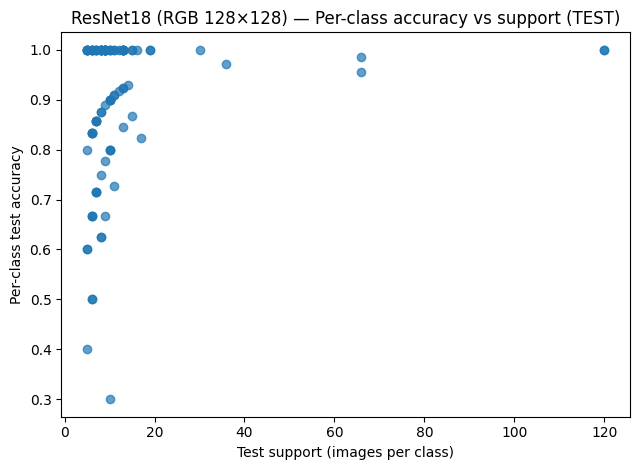

Saved: /content/drive/MyDrive/VictoriaClass/MiniProject1_v3/figures/deep_resnet18/per_class_acc_vs_support_resnet18_test.png
Saved: /content/drive/MyDrive/VictoriaClass/MiniProject1_v3/figures/deep_resnet18/bottom15_per_class_accuracy_resnet18_test.csv
 class_idx    class_name  n_test  test_per_class_acc
        60         lotus      10            0.300000
        11     binocular       5            0.400000
        99        wrench       6            0.500000
        95   water_lilly       6            0.500000
        73      platypus       5            0.600000
        97      wild_cat       5            0.600000
        28     crocodile       8            0.625000
         9          bass       8            0.625000
        18        cannon       6            0.666667
         6        anchor       6            0.666667
        62        mayfly       6            0.666667
        79      schooner       9            0.666667
        48     headphone       7            0.714286
     

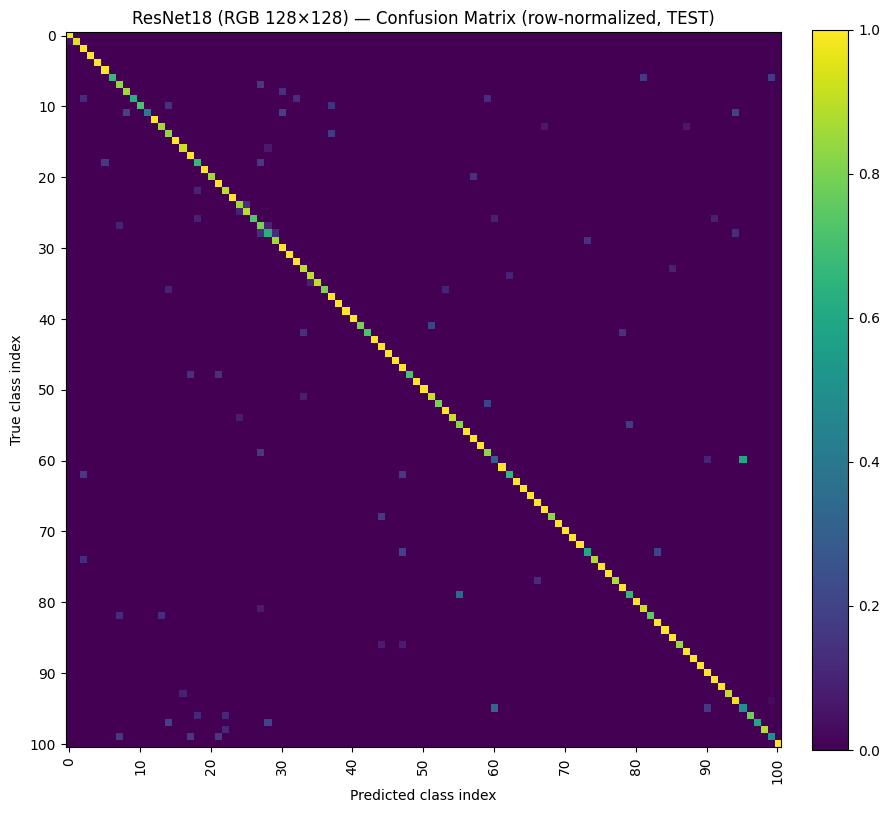

Saved: /content/drive/MyDrive/VictoriaClass/MiniProject1_v3/figures/deep_resnet18/cm_resnet18_test_row_normalized.png


In [ ]:
# Figures for ResNet18

import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

# Paths
PROJECT_ROOT = Path("/content/drive/MyDrive/VictoriaClass/MiniProject1_v3")
RES_DIR = PROJECT_ROOT / "results" / "deep_resnet18"
FIG_DIR = PROJECT_ROOT / "figures" / "deep_resnet18"
FIG_DIR.mkdir(parents=True, exist_ok=True)

pc_csv = RES_DIR / "test_per_class_accuracy.csv"
cm_path = RES_DIR / "test_confusion_matrix.npy"

for p in [pc_csv, cm_path]:
    assert p.exists(), f"Missing: {p}"

# Load
pc = pd.read_csv(pc_csv)
cm = np.load(cm_path)

# Per-class accuracy vs support
plt.figure(figsize=(6.5, 4.8))
plt.scatter(pc["n_test"].values, pc["test_per_class_acc"].values, alpha=0.7)
plt.xlabel("Test support (images per class)")
plt.ylabel("Per-class test accuracy")
plt.title("ResNet18 (RGB 128×128) — Per-class accuracy vs support (TEST)")
plt.grid(False)
out_scatter = FIG_DIR / "per_class_acc_vs_support_resnet18_test.png"
plt.tight_layout()
plt.savefig(out_scatter, dpi=200)
plt.show()
print("Saved:", out_scatter)

# Bottom-15 classes CSV
bottom15 = pc.sort_values("test_per_class_acc", ascending=True).head(15)
out_bottom15 = FIG_DIR / "bottom15_per_class_accuracy_resnet18_test.csv"
bottom15.to_csv(out_bottom15, index=False)
print("Saved:", out_bottom15)

# Print bottom-15 table to notebook
print(bottom15[["class_idx", "class_name", "n_test", "test_per_class_acc"]].to_string(index=False))

# Row-normalized confusion matrix
row_sums = cm.sum(axis=1, keepdims=True)
cm_norm = np.divide(cm, row_sums, out=np.zeros_like(cm, dtype=float), where=row_sums != 0)

plt.figure(figsize=(9, 9))
im = plt.imshow(cm_norm, interpolation="nearest")
plt.title("ResNet18 (RGB 128×128) — Confusion Matrix (row-normalized, TEST)")
plt.xlabel("Predicted class index")
plt.ylabel("True class index")
plt.colorbar(im, fraction=0.046, pad=0.04)

n = cm.shape[0]
step = 10
ticks = list(range(0, n, step))
plt.xticks(ticks, ticks, rotation=90)
plt.yticks(ticks, ticks)

plt.grid(False)
out_cm = FIG_DIR / "cm_resnet18_test_row_normalized.png"
plt.tight_layout()
plt.savefig(out_cm, dpi=200)
plt.show()
print("Saved:", out_cm)

In [ ]:
# EfficientNet-B0 ImageNet pretrained full fine-tune and test evaluation

import time, json, random
import numpy as np
import pandas as pd
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

assert "device" in globals()
assert "train_loader" in globals() and "val_loader" in globals() and "test_loader" in globals()
assert "idx_to_class" in globals() and "n_classes" in globals()

SEED = globals().get("SEED", 42)
IMG_SIZE = globals().get("IMG_SIZE", 128)
BATCH_SIZE = globals().get("BATCH_SIZE", 32)
LR = globals().get("LR", 1e-4)
EPOCHS = globals().get("EPOCHS", 100)

# Reproducibility
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

print("Device:", device)
print(f"Config: IMG_SIZE={IMG_SIZE} | BATCH_SIZE={BATCH_SIZE} | LR={LR} | EPOCHS={EPOCHS} | SEED={SEED}")

# Paths
PROJECT_ROOT = Path("/content/drive/MyDrive/VictoriaClass/MiniProject1_v3")
MODEL_NAME = "deep_efficientnet_b0"

MODEL_DIR   = PROJECT_ROOT / "models"  / MODEL_NAME
RESULTS_DIR = PROJECT_ROOT / "results" / MODEL_NAME
FIG_DIR     = PROJECT_ROOT / "figures" / MODEL_NAME
for d in [MODEL_DIR, RESULTS_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

best_ckpt_path = MODEL_DIR / "best.pt"
print("Checkpoint:", best_ckpt_path)

# Build model
weights = models.EfficientNet_B0_Weights.DEFAULT
net = models.efficientnet_b0(weights=weights)

# Replace classifier head
in_features = net.classifier[1].in_features
net.classifier[1] = nn.Linear(in_features, n_classes)

# Full fine-tuning
for p in net.parameters():
    p.requires_grad = True

net = net.to(device)

total_params = sum(p.numel() for p in net.parameters())
trainable_params = sum(p.numel() for p in net.parameters() if p.requires_grad)
print("Model: EfficientNet-B0 (pretrained, full fine-tune)")
print(f"Total params: {total_params:,} | Trainable: {trainable_params:,}")

# Forward pass
xb, yb = next(iter(train_loader))
xb = xb.to(device)
with torch.no_grad():
    logits = net(xb)
print("Logits shape:", logits.shape)  # [BATCH_SIZE, 101]

# Train setup
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=LR)

run_cfg = {
    "model": "EfficientNet-B0 (ImageNet pretrained, FULL fine-tune)",
    "preprocessing": "RGB resize to 128x128 + ImageNet normalization",
    "input_size": [IMG_SIZE, IMG_SIZE],
    "batch_size": BATCH_SIZE,
    "optimizer": "Adam",
    "lr": LR,
    "epochs": EPOCHS,
    "seed": SEED,
    "checkpoint_best": str(best_ckpt_path),
}
(RESULTS_DIR / "run_config.json").write_text(json.dumps(run_cfg, indent=2))
print("Wrote run config:", RESULTS_DIR / "run_config.json")

def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)

    total_loss = 0.0
    total_correct = 0
    total_n = 0

    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        logits = model(xb)
        loss = criterion(logits, yb)

        if is_train:
            loss.backward()
            optimizer.step()

        total_loss += float(loss.item()) * xb.size(0)
        total_correct += int((logits.argmax(dim=1) == yb).sum().item())
        total_n += int(xb.size(0))

    return total_loss / total_n, total_correct / total_n

# Train loop (save best by val acc)
history = []
best_val_acc = -1.0
best_epoch = -1

t_start = time.time()
for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    train_loss, train_acc = run_epoch(net, train_loader, optimizer=optimizer)
    val_loss, val_acc     = run_epoch(net, val_loader, optimizer=None)

    dt = time.time() - t0

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch
        torch.save(
            {"model_state": net.state_dict(), "epoch": epoch, "val_acc": val_acc},
            best_ckpt_path
        )

    history.append({
        "epoch": epoch,
        "train_loss": train_loss, "train_acc": train_acc,
        "val_loss": val_loss,     "val_acc": val_acc,
        "sec": dt
    })

    print(f"Epoch {epoch:03d}/{EPOCHS} | "
          f"train loss {train_loss:.4f} acc {train_acc:.4f} | "
          f"val loss {val_loss:.4f} acc {val_acc:.4f} | "
          f"{dt:.1f}s")

log_df = pd.DataFrame(history)
log_path = RESULTS_DIR / "training_log.csv"
log_df.to_csv(log_path, index=False)

print("\nBest val acc:", round(best_val_acc, 4), "at epoch", best_epoch)
print("Saved best checkpoint:", best_ckpt_path)
print("Saved training log:", log_path)
print("Total training time (min):", round((time.time() - t_start) / 60, 2))

# Test evaluation using best checkpoint
ckpt = torch.load(best_ckpt_path, map_location=device)
net.load_state_dict(ckpt["model_state"])
net.eval()

all_y, all_pred, all_scores = [], [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device, non_blocking=True)
        logits = net(xb)
        probs = torch.softmax(logits, dim=1)

        all_scores.append(probs.cpu().numpy())
        all_pred.append(logits.argmax(dim=1).cpu().numpy())
        all_y.append(yb.numpy())

y_true = np.concatenate(all_y)
y_pred = np.concatenate(all_pred)
scores = np.concatenate(all_scores)  # [N, 101]

# Top-k
def topk_acc(scores_, y_true_, k):
    topk = np.argsort(-scores_, axis=1)[:, :k]
    return float(np.mean([y_true_[i] in topk[i] for i in range(len(y_true_))]))

acc = accuracy_score(y_true, y_pred)
top1 = float(acc)
top5 = topk_acc(scores, y_true, k=5)

labels = list(range(n_classes))
cm = confusion_matrix(y_true, y_pred, labels=labels)
row_sums = cm.sum(axis=1)
per_class_acc = np.divide(
    np.diag(cm), row_sums,
    out=np.zeros_like(row_sums, dtype=float),
    where=row_sums != 0
)

report = classification_report(
    y_true, y_pred,
    labels=labels,
    target_names=idx_to_class,
    output_dict=True,
    zero_division=0
)

print("\nLoaded checkpoint epoch:", int(ckpt.get("epoch", -1)), "| best_val_acc:", float(ckpt.get("val_acc", -1)))
print("TEST top-1 accuracy:", round(top1, 4))
print("TEST top-5 accuracy:", round(top5, 4))
print("Macro avg (P/R/F1):",
      round(report["macro avg"]["precision"], 4),
      round(report["macro avg"]["recall"], 4),
      round(report["macro avg"]["f1-score"], 4))
print("Weighted avg (P/R/F1):",
      round(report["weighted avg"]["precision"], 4),
      round(report["weighted avg"]["recall"], 4),
      round(report["weighted avg"]["f1-score"], 4))

# Save outputs
summary = {
    "model": "EfficientNet-B0 (ImageNet pretrained, FULL fine-tune)",
    "preprocessing": "RGB resize to 128x128 + ImageNet normalization",
    "batch_size": BATCH_SIZE,
    "optimizer": "Adam",
    "lr": LR,
    "epochs_budget": EPOCHS,
    "best_epoch": int(ckpt.get("epoch", -1)),
    "best_val_acc": float(ckpt.get("val_acc", -1)),
    "test_accuracy": float(acc),
    "top1_accuracy": float(top1),
    "top5_accuracy": float(top5),
    "macro_avg": {
        "precision": float(report["macro avg"]["precision"]),
        "recall": float(report["macro avg"]["recall"]),
        "f1": float(report["macro avg"]["f1-score"]),
    },
    "weighted_avg": {
        "precision": float(report["weighted avg"]["precision"]),
        "recall": float(report["weighted avg"]["recall"]),
        "f1": float(report["weighted avg"]["f1-score"]),
    }
}

with open(RESULTS_DIR / "test_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

pd.DataFrame({
    "class_idx": np.arange(n_classes),
    "class_name": idx_to_class,
    "n_test": row_sums,
    "test_per_class_acc": per_class_acc
}).sort_values("test_per_class_acc").to_csv(RESULTS_DIR / "test_per_class_accuracy.csv", index=False)

with open(RESULTS_DIR / "test_classification_report.json", "w") as f:
    json.dump(report, f, indent=2)

np.save(RESULTS_DIR / "test_confusion_matrix.npy", cm)

print("\nSaved outputs to:", RESULTS_DIR)
print(" - test_summary.json")
print(" - test_per_class_accuracy.csv")
print(" - test_classification_report.json")
print(" - test_confusion_matrix.npy")
print(" - training_log.csv")

Device: cuda
Config: IMG_SIZE=128 | BATCH_SIZE=32 | LR=0.0001 | EPOCHS=100 | SEED=42
Checkpoint: /content/drive/MyDrive/VictoriaClass/MiniProject1_v3/models/deep_efficientnet_b0/best.pt
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 126MB/s]


Model: EfficientNet-B0 (pretrained, full fine-tune)
Total params: 4,136,929 | Trainable: 4,136,929
Logits shape: torch.Size([32, 101])
Wrote run config: /content/drive/MyDrive/VictoriaClass/MiniProject1_v3/results/deep_efficientnet_b0/run_config.json
Epoch 001/100 | train loss 3.1380 acc 0.4222 | val loss 2.0567 acc 0.6974 | 20.5s
Epoch 002/100 | train loss 1.4464 acc 0.7456 | val loss 0.8359 acc 0.8479 | 19.0s
Epoch 003/100 | train loss 0.6234 acc 0.8824 | val loss 0.4300 acc 0.9048 | 20.8s
Epoch 004/100 | train loss 0.3062 acc 0.9475 | val loss 0.3037 acc 0.9301 | 20.7s
Epoch 005/100 | train loss 0.1889 acc 0.9667 | val loss 0.2526 acc 0.9386 | 19.3s
Epoch 006/100 | train loss 0.1131 acc 0.9827 | val loss 0.2249 acc 0.9386 | 21.1s
Epoch 007/100 | train loss 0.0779 acc 0.9867 | val loss 0.2079 acc 0.9462 | 19.0s
Epoch 008/100 | train loss 0.0576 acc 0.9906 | val loss 0.2131 acc 0.9432 | 19.9s
Epoch 009/100 | train loss 0.0442 acc 0.9947 | val loss 0.1957 acc 0.9493 | 20.7s
Epoch 010/1

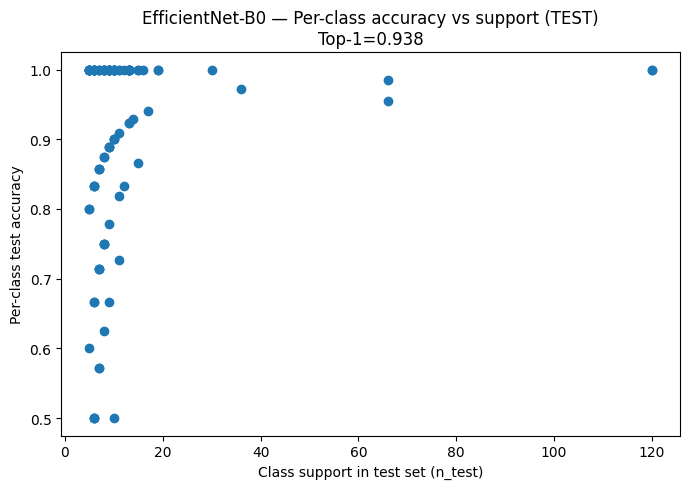

Saved: /content/drive/MyDrive/VictoriaClass/MiniProject1_v3/figures/deep_efficientnet_b0/per_class_acc_vs_support_efficientnet_b0_test.png
Saved: /content/drive/MyDrive/VictoriaClass/MiniProject1_v3/figures/deep_efficientnet_b0/bottom15_per_class_accuracy_efficientnet_b0_test.csv
 class_idx      class_name  n_test  test_per_class_acc
         6          anchor       6            0.500000
        59         lobster       6            0.500000
        60           lotus      10            0.500000
        95     water_lilly       6            0.500000
        24     cougar_body       7            0.571429
        10          beaver       7            0.571429
        73        platypus       5            0.600000
        28       crocodile       8            0.625000
        99          wrench       6            0.666667
        79        schooner       9            0.666667
        14    brontosaurus       6            0.666667
        17          camera       7            0.714286
    

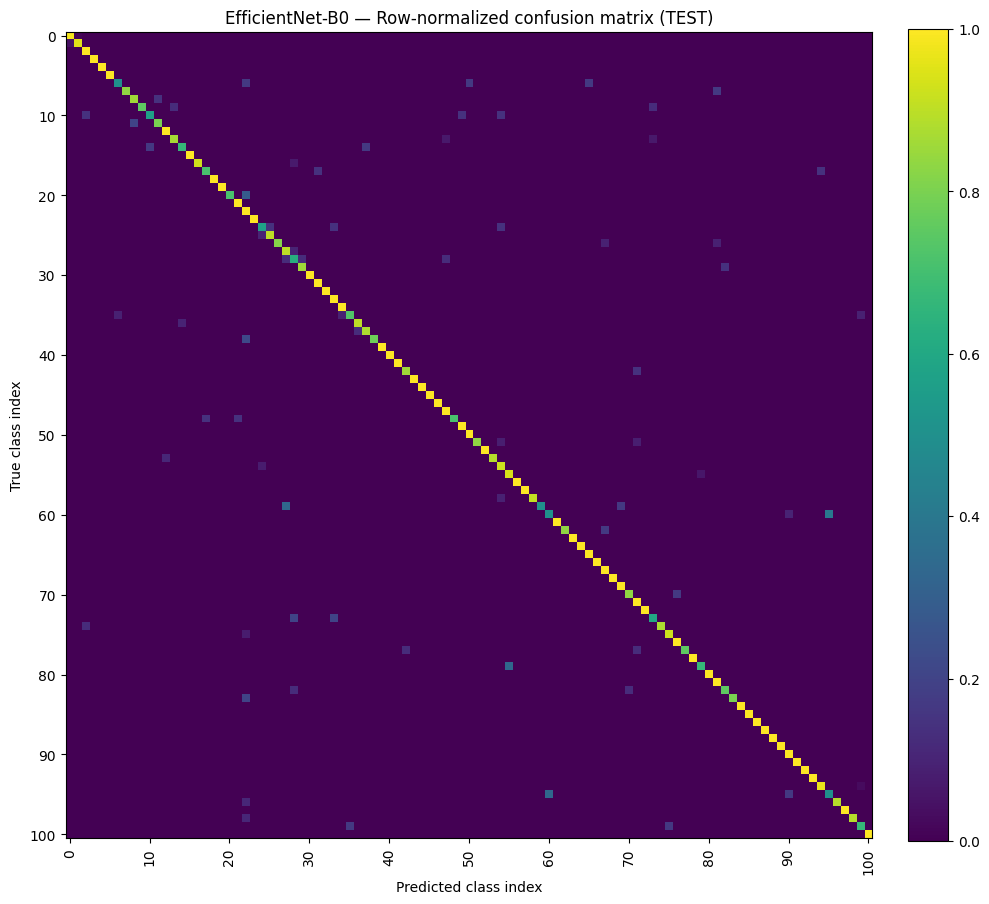

Saved: /content/drive/MyDrive/VictoriaClass/MiniProject1_v3/figures/deep_efficientnet_b0/cm_efficientnet_b0_test_row_normalized.png


In [ ]:
# Figures for EfficientNet-B0

import json
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("/content/drive/MyDrive/VictoriaClass/MiniProject1_v3")

MODEL_NAME = "deep_efficientnet_b0"
RES_DIR = PROJECT_ROOT / "results" / MODEL_NAME
FIG_DIR = PROJECT_ROOT / "figures" / MODEL_NAME
FIG_DIR.mkdir(parents=True, exist_ok=True)

pc_csv = RES_DIR / "test_per_class_accuracy.csv"
cm_npy = RES_DIR / "test_confusion_matrix.npy"
summary_json = RES_DIR / "test_summary.json"

for p in [pc_csv, cm_npy, summary_json]:
    assert p.exists(), f"Missing: {p}"

pc = pd.read_csv(pc_csv)
cm = np.load(cm_npy)

with open(summary_json, "r") as f:
    summary = json.load(f)

# Per-class accuracy vs support
plt.figure(figsize=(7, 5))
plt.scatter(pc["n_test"], pc["test_per_class_acc"])
plt.xlabel("Class support in test set (n_test)")
plt.ylabel("Per-class test accuracy")
plt.title(f"EfficientNet-B0 — Per-class accuracy vs support (TEST)\nTop-1={summary.get('test_accuracy', np.nan):.3f}")
plt.grid(False)
plt.tight_layout()

fig1 = FIG_DIR / "per_class_acc_vs_support_efficientnet_b0_test.png"
plt.savefig(fig1, dpi=200)
plt.show()
print("Saved:", fig1)

# Bottom-15 per-class accuracy CSV
bottom15 = pc.sort_values("test_per_class_acc").head(15).copy()
bottom15_csv = FIG_DIR / "bottom15_per_class_accuracy_efficientnet_b0_test.csv"
bottom15.to_csv(bottom15_csv, index=False)
print("Saved:", bottom15_csv)
print(bottom15[["class_idx", "class_name", "n_test", "test_per_class_acc"]].to_string(index=False))

# Confusion matrix image
row_sums = cm.sum(axis=1, keepdims=True)
cm_row_norm = np.divide(cm, row_sums, out=np.zeros_like(cm, dtype=float), where=row_sums != 0)

plt.figure(figsize=(10, 10))
im = plt.imshow(cm_row_norm, interpolation="nearest")
plt.title("EfficientNet-B0 — Row-normalized confusion matrix (TEST)")
plt.xlabel("Predicted class index")
plt.ylabel("True class index")
plt.grid(False)
plt.colorbar(im, fraction=0.046, pad=0.04)

n = cm.shape[0]
step = 10
ticks = list(range(0, n, step))
plt.xticks(ticks, ticks, rotation=90)
plt.yticks(ticks, ticks)

plt.tight_layout()
fig2 = FIG_DIR / "cm_efficientnet_b0_test_row_normalized.png"
plt.savefig(fig2, dpi=200)
plt.show()
print("Saved:", fig2)

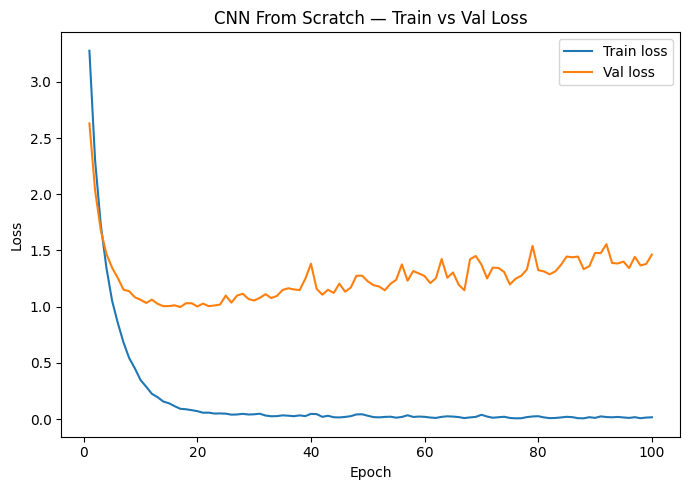

Saved: /content/drive/MyDrive/VictoriaClass/MiniProject1_v3/figures/training_curves/deep_simplecnn_loss_curves.png


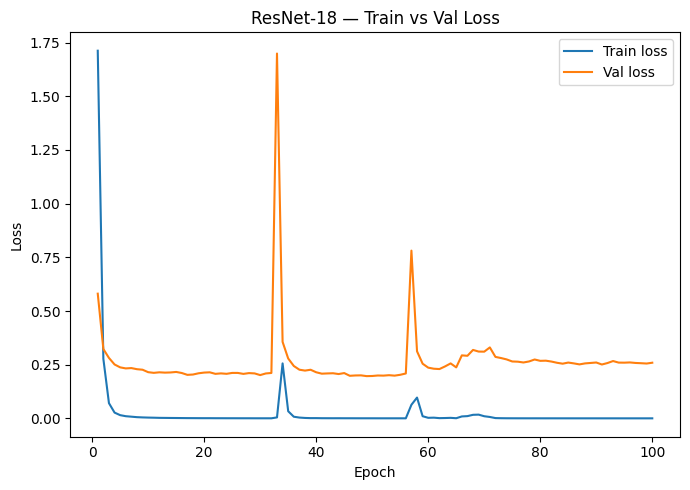

Saved: /content/drive/MyDrive/VictoriaClass/MiniProject1_v3/figures/training_curves/deep_resnet18_loss_curves.png


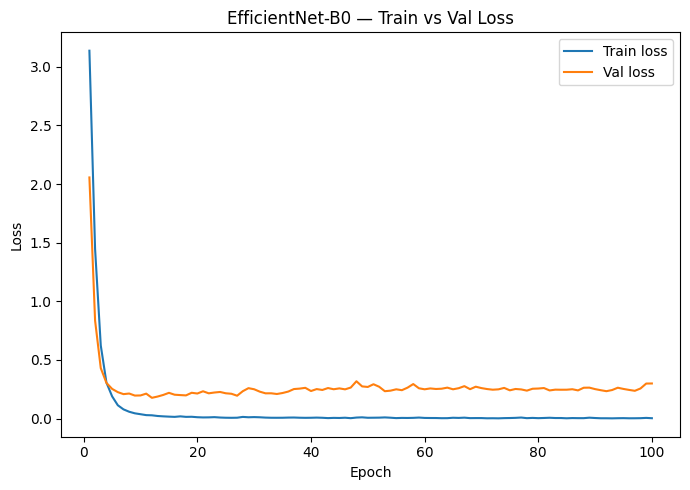

Saved: /content/drive/MyDrive/VictoriaClass/MiniProject1_v3/figures/training_curves/deep_efficientnet_b0_loss_curves.png


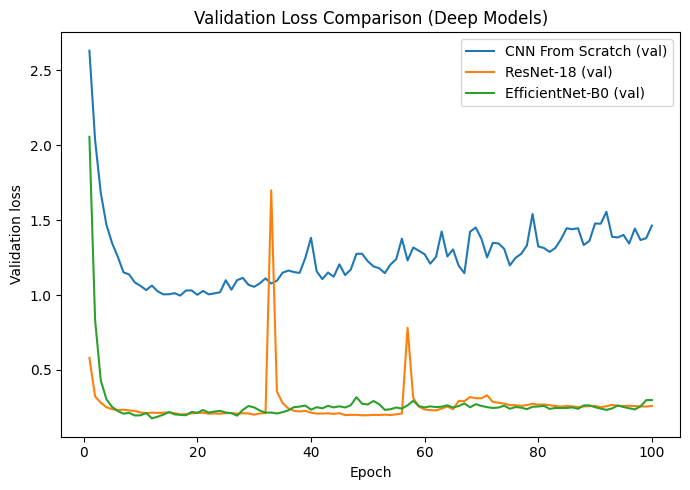

Saved: /content/drive/MyDrive/VictoriaClass/MiniProject1_v3/figures/training_curves/val_loss_overlay_deep_models.png


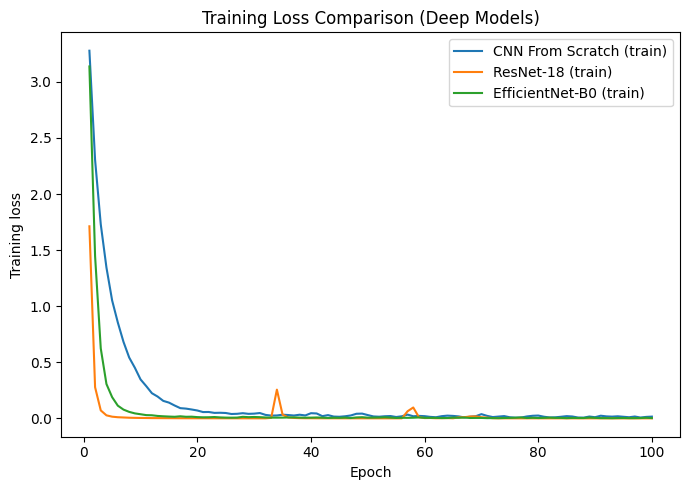

Saved: /content/drive/MyDrive/VictoriaClass/MiniProject1_v3/figures/training_curves/train_loss_overlay_deep_models.png


In [ ]:
# Training curves (train vs val loss) for all deep models
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("/content/drive/MyDrive/VictoriaClass/MiniProject1_v3")
RESULTS_ROOT = PROJECT_ROOT / "results"

MODELS = {
    "deep_simplecnn": "CNN From Scratch",
    "deep_resnet18": "ResNet-18",
    "deep_efficientnet_b0": "EfficientNet-B0",
}

OUT_DIR = PROJECT_ROOT / "figures" / "training_curves"
OUT_DIR.mkdir(parents=True, exist_ok=True)

def load_log(model_folder: str) -> pd.DataFrame:
    log_path = RESULTS_ROOT / model_folder / "training_log.csv"
    assert log_path.exists(), f"Missing training log: {log_path}"
    df = pd.read_csv(log_path)
    expected = {"epoch", "train_loss", "val_loss"}
    assert expected.issubset(df.columns), f"{model_folder} log missing columns; found {list(df.columns)}"
    return df

# Save per-model loss curves
for folder, pretty in MODELS.items():
    df = load_log(folder)

    plt.figure(figsize=(7, 5))
    plt.plot(df["epoch"], df["train_loss"], label="Train loss")
    plt.plot(df["epoch"], df["val_loss"], label="Val loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{pretty} — Train vs Val Loss")
    plt.legend()
    plt.tight_layout()

    out_path = OUT_DIR / f"{folder}_loss_curves.png"
    plt.savefig(out_path, dpi=200)
    plt.show()
    print("Saved:", out_path)

# Overlay validation loss across models
plt.figure(figsize=(7, 5))
for folder, pretty in MODELS.items():
    df = load_log(folder)
    plt.plot(df["epoch"], df["val_loss"], label=f"{pretty} (val)")

plt.xlabel("Epoch")
plt.ylabel("Validation loss")
plt.title("Validation Loss Comparison (Deep Models)")
plt.legend()
plt.tight_layout()

overlay_val_path = OUT_DIR / "val_loss_overlay_deep_models.png"
plt.savefig(overlay_val_path, dpi=200)
plt.show()
print("Saved:", overlay_val_path)

# Overlay train loss across models
plt.figure(figsize=(7, 5))
for folder, pretty in MODELS.items():
    df = load_log(folder)
    plt.plot(df["epoch"], df["train_loss"], label=f"{pretty} (train)")

plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title("Training Loss Comparison (Deep Models)")
plt.legend()
plt.tight_layout()

overlay_train_path = OUT_DIR / "train_loss_overlay_deep_models.png"
plt.savefig(overlay_train_path, dpi=200)
plt.show()
print("Saved:", overlay_train_path)

In [ ]:
# Build an overall metrics table from the saved JSON summaries

import json
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path("/content/drive/MyDrive/VictoriaClass/MiniProject1_v3")

def load_json(p: Path):
    with open(p, "r") as f:
        return json.load(f)

def pick_existing(candidates, label):
    candidates = [Path(c) for c in candidates]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(
        f"Could not find {label} summary json. Tried:\n" + "\n".join(str(p) for p in candidates)
    )

deep_effnet = pick_existing([
    PROJECT_ROOT / "results" / "deep_efficientnet_b0" / "test_summary.json",
], "EfficientNet-B0")

deep_resnet = pick_existing([
    PROJECT_ROOT / "results" / "deep_resnet18" / "test_summary.json",
], "ResNet-18")

deep_cnn = pick_existing([
    PROJECT_ROOT / "results" / "deep_simplecnn" / "test_summary.json",
], "SimpleCNN")

hog_svm = pick_existing([
    PROJECT_ROOT / "results" / "classical_hog_svm" / "test_summary.json",
    PROJECT_ROOT / "results" / "classical_hog_linearsvc" / "test_summary.json",
    PROJECT_ROOT / "results" / "hog_linearsvc" / "test_summary.json",
], "HOG+LinearSVC")

def row_from_summary(s, model_label, top5_fallback=None):
    top1 = s.get("top1_accuracy", s.get("test_accuracy", None))
    top5 = (s.get("top5_accuracy", None) or s.get("test_top5_accuracy", None) or top5_fallback)

    macro = s.get("macro_avg", {})
    weighted = s.get("weighted_avg", {})

    macro_f1 = macro.get("f1", macro.get("f1-score", None))
    weighted_f1 = weighted.get("f1", weighted.get("f1-score", None))

    return {
        "Model": model_label,
        "Top-1 Accuracy": float(top1) if top1 is not None else None,
        "Top-5 acc": float(top5) if top5 is not None else None,
        "Macro precision": float(macro.get("precision")) if macro.get("precision") is not None else None,
        "Macro recall": float(macro.get("recall")) if macro.get("recall") is not None else None,
        "Macro f1": float(macro_f1) if macro_f1 is not None else None,
        "Weighted precision": float(weighted.get("precision")) if weighted.get("precision") is not None else None,
        "Weighted recall": float(weighted.get("recall")) if weighted.get("recall") is not None else None,
        "Weighted F1": float(weighted_f1) if weighted_f1 is not None else None,
    }

eff_s = load_json(deep_effnet)
res_s = load_json(deep_resnet)
cnn_s = load_json(deep_cnn)
hog_s = load_json(hog_svm)

rows = [
    row_from_summary(eff_s, "EffNet-B0 FULL FT (RGB128, Adam 1e-4, bs32)"),
    row_from_summary(res_s, "ResNet18 FULL FT (RGB128, Adam 1e-4, bs32)"),
    row_from_summary(cnn_s, "SimpleCNN scratch (RGB128, Adam 1e-4, bs32)"),
    row_from_summary(hog_s, "HOG + LinearSVC (RGB128)"),
]

df = pd.DataFrame(rows)

df_rounded = df.copy()
for c in df.columns[1:]:
    df_rounded[c] = df_rounded[c].map(lambda x: None if pd.isna(x) else round(float(x), 6))

display(df_rounded)

# Save a CSV
out_csv = PROJECT_ROOT / "results" / "overall_metrics_table_v3.csv"
out_csv.parent.mkdir(parents=True, exist_ok=True)
df_rounded.to_csv(out_csv, index=False)
print("Saved:", out_csv)

# Print as a markdown table
print("\nMarkdown table:\n")
print(df_rounded.to_markdown(index=False))

,Model,Top-1 Accuracy,Top-5 acc,Macro precision,Macro recall,Macro f1,Weighted precision,Weighted recall,Weighted F1
0,"EffNet-B0 FULL FT (RGB128, Adam 1e-4, bs32)",0.937788,0.987711,0.919558,0.902066,0.905467,0.943428,0.937788,0.937244
1,"ResNet18 FULL FT (RGB128, Adam 1e-4, bs32)",0.932412,0.990015,0.910492,0.894781,0.895740,0.938377,0.932412,0.931562
2,"SimpleCNN scratch (RGB128, Adam 1e-4, bs32)",0.754992,0.895545,0.681514,0.621470,0.627281,0.769705,0.754992,0.747734
3,HOG + LinearSVC (RGB128),0.645161,0.788018,NaN,NaN,NaN,NaN,NaN,NaN


Saved: /content/drive/MyDrive/VictoriaClass/MiniProject1_v3/results/overall_metrics_table_v3.csv

Markdown table:

| Model                                       |   Top-1 Accuracy |   Top-5 acc |   Macro precision |   Macro recall |   Macro f1 |   Weighted precision |   Weighted recall |   Weighted F1 |
|:--------------------------------------------|-----------------:|------------:|------------------:|---------------:|-----------:|---------------------:|------------------:|--------------:|
| EffNet-B0 FULL FT (RGB128, Adam 1e-4, bs32) |         0.937788 |    0.987711 |          0.919558 |       0.902066 |   0.905467 |             0.943428 |          0.937788 |      0.937244 |
| ResNet18 FULL FT (RGB128, Adam 1e-4, bs32)  |         0.932412 |    0.990015 |          0.910492 |       0.894781 |   0.89574  |             0.938377 |          0.932412 |      0.931562 |
| SimpleCNN scratch (RGB128, Adam 1e-4, bs32) |         0.754992 |    0.895545 |          0.681514 |       0.62147  |   0.627

In [ ]:
!ls -R "/content/drive/MyDrive/VictoriaClass/MiniProject1_v3/results" | head -n 200

/content/drive/MyDrive/VictoriaClass/MiniProject1_v3/results:
classical_hog_svm
deep_efficientnet_b0
deep_resnet18
deep_simplecnn
overall_metrics_table_v3.csv

/content/drive/MyDrive/VictoriaClass/MiniProject1_v3/results/classical_hog_svm:
C_sweep_val.csv
test_classification_report.csv
test_confusion_matrix.npy
test_per_class_accuracy.csv
test_predictions.csv
test_summary.json

/content/drive/MyDrive/VictoriaClass/MiniProject1_v3/results/deep_efficientnet_b0:
run_config.json
test_classification_report.json
test_confusion_matrix.npy
test_per_class_accuracy.csv
test_summary.json
training_log.csv

/content/drive/MyDrive/VictoriaClass/MiniProject1_v3/results/deep_resnet18:
run_config.json
test_classification_report.json
test_confusion_matrix.npy
test_per_class_accuracy.csv
test_summary.json
training_log.csv

/content/drive/MyDrive/VictoriaClass/MiniProject1_v3/results/deep_simplecnn:
run_config.json
test_classification_report.json
test_confusion_matrix.npy
test_per_class_accuracy.csv
test_

In [ ]:
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path("/content/drive/MyDrive/VictoriaClass/MiniProject1_v3")

overall_csv = PROJECT_ROOT / "results" / "overall_metrics_table_v3.csv"
df = pd.read_csv(overall_csv)

hog_report_path = PROJECT_ROOT / "results" / "classical_hog_svm" / "test_classification_report.csv"
assert hog_report_path.exists(), f"Missing: {hog_report_path}"

rep = pd.read_csv(hog_report_path)

# the label column is "Unnamed: 0"
label_col = "Unnamed: 0"
assert label_col in rep.columns, f"Couldn't find label column. Columns: {list(rep.columns)}"
rep = rep.set_index(label_col)

# Pull macro / weighted rows
macro_p = float(rep.loc["macro avg", "precision"])
macro_r = float(rep.loc["macro avg", "recall"])
macro_f = float(rep.loc["macro avg", "f1-score"])

w_p = float(rep.loc["weighted avg", "precision"])
w_r = float(rep.loc["weighted avg", "recall"])
w_f = float(rep.loc["weighted avg", "f1-score"])

hog_mask = df["Model"].str.contains("HOG", na=False)

df.loc[hog_mask, "Macro precision"] = macro_p
df.loc[hog_mask, "Macro recall"]    = macro_r
df.loc[hog_mask, "Macro f1"]        = macro_f

df.loc[hog_mask, "Weighted precision"] = w_p
df.loc[hog_mask, "Weighted recall"]    = w_r
df.loc[hog_mask, "Weighted F1"]        = w_f

# Round for copying into report
df_round = df.copy()
metric_cols = [c for c in df.columns if c != "Model"]
df_round[metric_cols] = df_round[metric_cols].astype(float).round(6)

display(df_round)

# Overwrite the table CSV with the filled values
out_csv = PROJECT_ROOT / "results" / "overall_metrics_table_v3.csv"
df_round.to_csv(out_csv, index=False)
print("Updated:", out_csv)

print("\nMarkdown table:\n")
print(df_round.to_markdown(index=False))

,Model,Top-1 Accuracy,Top-5 acc,Macro precision,Macro recall,Macro f1,Weighted precision,Weighted recall,Weighted F1
0,"EffNet-B0 FULL FT (RGB128, Adam 1e-4, bs32)",0.937788,0.987711,0.919558,0.902066,0.905467,0.943428,0.937788,0.937244
1,"ResNet18 FULL FT (RGB128, Adam 1e-4, bs32)",0.932412,0.990015,0.910492,0.894781,0.895740,0.938377,0.932412,0.931562
2,"SimpleCNN scratch (RGB128, Adam 1e-4, bs32)",0.754992,0.895545,0.681514,0.621470,0.627281,0.769705,0.754992,0.747734
3,HOG + LinearSVC (RGB128),0.645161,0.788018,0.508123,0.452557,0.453130,0.634374,0.645161,0.621213


Updated: /content/drive/MyDrive/VictoriaClass/MiniProject1_v3/results/overall_metrics_table_v3.csv

Markdown table:

| Model                                       |   Top-1 Accuracy |   Top-5 acc |   Macro precision |   Macro recall |   Macro f1 |   Weighted precision |   Weighted recall |   Weighted F1 |
|:--------------------------------------------|-----------------:|------------:|------------------:|---------------:|-----------:|---------------------:|------------------:|--------------:|
| EffNet-B0 FULL FT (RGB128, Adam 1e-4, bs32) |         0.937788 |    0.987711 |          0.919558 |       0.902066 |   0.905467 |             0.943428 |          0.937788 |      0.937244 |
| ResNet18 FULL FT (RGB128, Adam 1e-4, bs32)  |         0.932412 |    0.990015 |          0.910492 |       0.894781 |   0.89574  |             0.938377 |          0.932412 |      0.931562 |
| SimpleCNN scratch (RGB128, Adam 1e-4, bs32) |         0.754992 |    0.895545 |          0.681514 |       0.62147  |   0.6

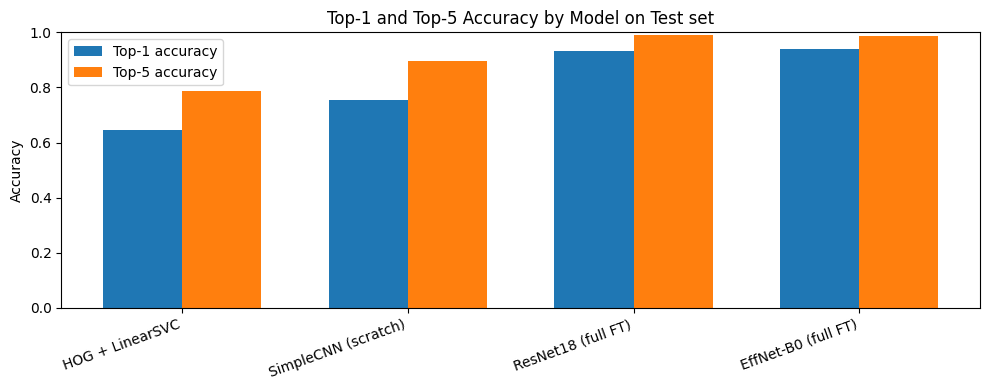

Saved figure: /content/drive/MyDrive/VictoriaClass/MiniProject1_v3/figures/top1_top5_accuracy_by_model_test.png


,Model,Top-1,Top-5
0,HOG + LinearSVC,0.645161,0.788018
1,SimpleCNN (scratch),0.754992,0.895545
2,ResNet18 (full FT),0.932412,0.990015
3,EffNet-B0 (full FT),0.937788,0.987711


In [ ]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path("/content/drive/MyDrive/VictoriaClass/MiniProject1_v3")
RESULTS_ROOT = PROJECT_ROOT / "results"
FIG_DIR = PROJECT_ROOT / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

def load_json(p: Path):
    with open(p, "r") as f:
        return json.load(f)

rows = []

deep_specs = [
    ("SimpleCNN (scratch)", RESULTS_ROOT / "deep_simplecnn" / "test_summary.json"),
    ("ResNet18 (full FT)",  RESULTS_ROOT / "deep_resnet18" / "test_summary.json"),
    ("EffNet-B0 (full FT)", RESULTS_ROOT / "deep_efficientnet_b0" / "test_summary.json"),
]

for label, p in deep_specs:
    assert p.exists(), f"Missing: {p}"
    d = load_json(p)
    top1 = float(d.get("top1_accuracy", d.get("test_accuracy")))
    top5 = float(d.get("top5_accuracy"))
    rows.append({"Model": label, "Top-1": top1, "Top-5": top5})

hog_path = RESULTS_ROOT / "classical_hog_svm" / "test_summary.json"
assert hog_path.exists(), f"Missing: {hog_path}"
d = load_json(hog_path)

top1 = float(d.get("top1_accuracy", d.get("test_accuracy")))
top5 = float(d.get("top5_accuracy", d.get("top5_accuracy_test", np.nan)))
assert not np.isnan(top5), f"Couldn't find top-5 in {hog_path}. Keys: {list(d.keys())}"

rows.insert(0, {"Model": "HOG + LinearSVC", "Top-1": top1, "Top-5": top5})

df = pd.DataFrame(rows)

# ===== Plot =====
x = np.arange(len(df))
w = 0.35

plt.figure(figsize=(10, 4))
plt.bar(x - w/2, df["Top-1"], width=w, label="Top-1 accuracy")
plt.bar(x + w/2, df["Top-5"], width=w, label="Top-5 accuracy")
plt.xticks(x, df["Model"], rotation=20, ha="right")
plt.ylim(0, 1.0)
plt.ylabel("Accuracy")
plt.title("Top-1 and Top-5 Accuracy by Model on Test set")
plt.legend()
plt.tight_layout()

out_path = FIG_DIR / "top1_top5_accuracy_by_model_test.png"
plt.savefig(out_path, dpi=200)
plt.show()

print("Saved figure:", out_path)
df

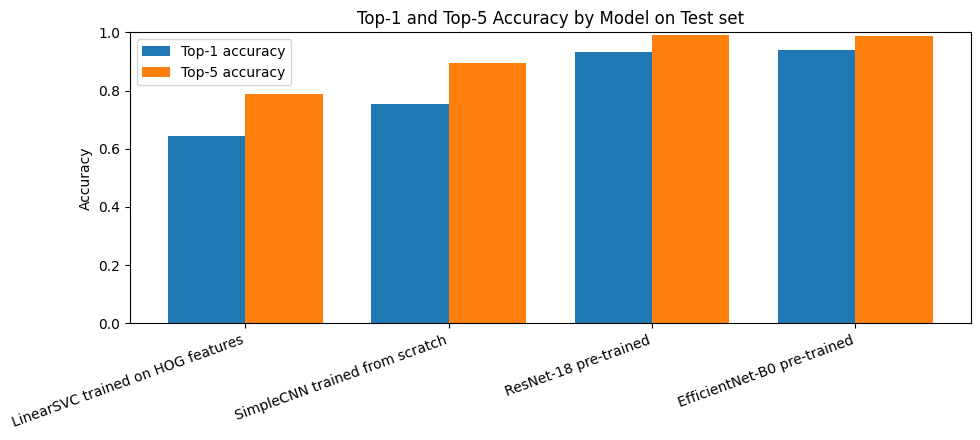

Saved: /content/drive/MyDrive/VictoriaClass/MiniProject1_v3/figures/overall/top1_top5_accuracy_bar.png


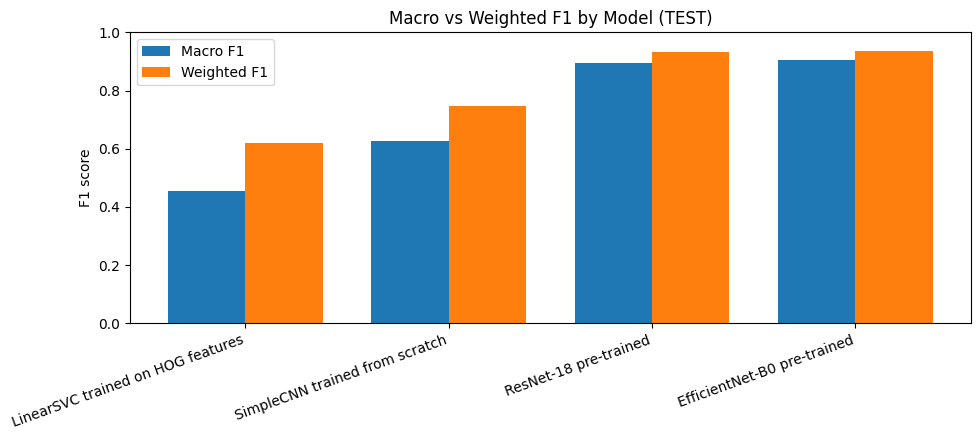

Saved: /content/drive/MyDrive/VictoriaClass/MiniProject1_v3/figures/overall/macro_vs_weighted_f1_bar.png
Saved pretty table: /content/drive/MyDrive/VictoriaClass/MiniProject1_v3/results/overall_metrics_table_v3_pretty.csv


,Model,Model,Top-1 Accuracy,Top-5 acc,Macro precision,Macro recall,Macro f1,Weighted precision,Weighted recall,Weighted F1
0,LinearSVC trained on HOG features,HOG + LinearSVC (RGB128),0.645161,0.788018,0.508123,0.452557,0.453130,0.634374,0.645161,0.621213
1,SimpleCNN trained from scratch,"SimpleCNN scratch (RGB128, Adam 1e-4, bs32)",0.754992,0.895545,0.681514,0.621470,0.627281,0.769705,0.754992,0.747734
2,ResNet-18 pre-trained,"ResNet18 FULL FT (RGB128, Adam 1e-4, bs32)",0.932412,0.990015,0.910492,0.894781,0.895740,0.938377,0.932412,0.931562
3,EfficientNet-B0 pre-trained,"EffNet-B0 FULL FT (RGB128, Adam 1e-4, bs32)",0.937788,0.987711,0.919558,0.902066,0.905467,0.943428,0.937788,0.937244


In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("/content/drive/MyDrive/VictoriaClass/MiniProject1_v3")
RESULTS_DIR = PROJECT_ROOT / "results"
FIG_DIR = PROJECT_ROOT / "figures" / "overall"
FIG_DIR.mkdir(parents=True, exist_ok=True)

csv_path = RESULTS_DIR / "overall_metrics_table_v3.csv"
assert csv_path.exists(), f"Missing: {csv_path}"

df = pd.read_csv(csv_path)

pretty = {
    "HOG + LinearSVC (RGB128)": "LinearSVC trained on HOG features",
    "HOG + LinearSVC (RGB128, best C)": "LinearSVC trained on HOG features",
    "HOG + LinearSVC": "LinearSVC trained on HOG features",
    "SimpleCNN scratch (RGB128, Adam 1e-4, bs32)": "SimpleCNN trained from scratch",
    "SimpleCNN (scratch)": "SimpleCNN trained from scratch",
    "ResNet18 FULL FT (RGB128, Adam 1e-4, bs32)": "ResNet-18 pre-trained",
    "ResNet-18 (full FT)": "ResNet-18 pre-trained",
    "EffNet-B0 FULL FT (RGB128, Adam 1e-4, bs32)": "EfficientNet-B0 pre-trained",
    "EfficientNet-B0 (full FT)": "EfficientNet-B0 pre-trained",
}

df["Model_pretty"] = df["Model"].map(pretty).fillna(df["Model"])

# --- Enforce a clean, fixed order (so figures match your report) ---
order = [
    "LinearSVC trained on HOG features",
    "SimpleCNN trained from scratch",
    "ResNet-18 pre-trained",
    "EfficientNet-B0 pre-trained",
]
df = df.set_index("Model_pretty").loc[[m for m in order if m in df["Model_pretty"].values]].reset_index()

def to_num(s):
    return pd.to_numeric(s, errors="coerce")

# Top-1 vs Top-5
top1 = to_num(df["Top-1 Accuracy"])
top5 = to_num(df["Top-5 acc"])

x = np.arange(len(df))
w = 0.38

plt.figure(figsize=(10, 4.5))
plt.bar(x - w/2, top1, width=w, label="Top-1 accuracy")
plt.bar(x + w/2, top5, width=w, label="Top-5 accuracy")
plt.ylim(0, 1.0)
plt.ylabel("Accuracy")
plt.title("Top-1 and Top-5 Accuracy by Model on Test set")
plt.xticks(x, df["Model_pretty"], rotation=20, ha="right")
plt.legend()
plt.tight_layout()

out1 = FIG_DIR / "top1_top5_accuracy_bar.png"
plt.savefig(out1, dpi=200)
plt.show()
print("Saved:", out1)

# Macro F1 vs Weighted F1
macro_f1 = to_num(df["Macro f1"])
weighted_f1 = to_num(df["Weighted F1"])

plt.figure(figsize=(10, 4.5))
plt.bar(x - w/2, macro_f1, width=w, label="Macro F1")
plt.bar(x + w/2, weighted_f1, width=w, label="Weighted F1")
plt.ylim(0, 1.0)
plt.ylabel("F1 score")
plt.title("Macro vs Weighted F1 by Model (TEST)")
plt.xticks(x, df["Model_pretty"], rotation=20, ha="right")
plt.legend()
plt.tight_layout()

out2 = FIG_DIR / "macro_vs_weighted_f1_bar.png"
plt.savefig(out2, dpi=200)
plt.show()
print("Saved:", out2)

# Table
pretty_table = df.copy()
pretty_table = pretty_table.rename(columns={"Model_pretty": "Model"})
pretty_table_out = RESULTS_DIR / "overall_metrics_table_v3_pretty.csv"
pretty_table.to_csv(pretty_table_out, index=False)
print("Saved pretty table:", pretty_table_out)

display(pretty_table)

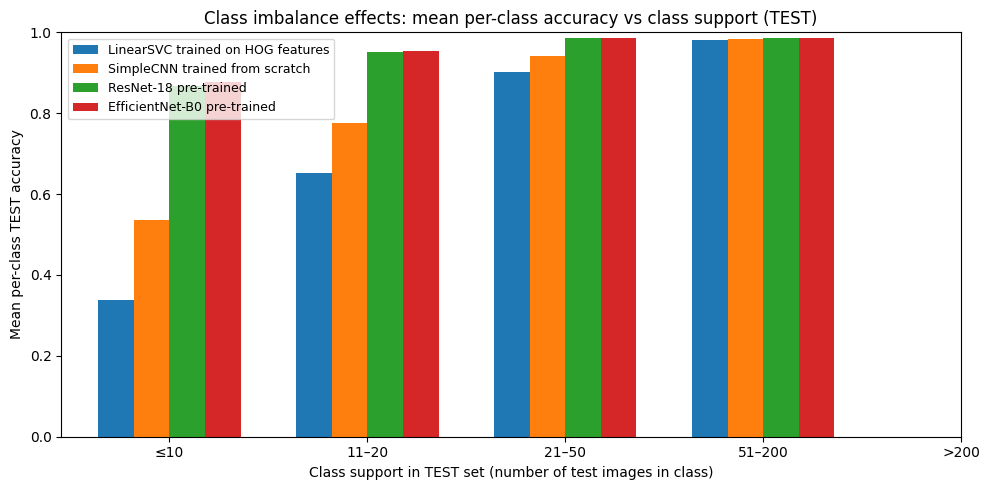

Saved: /content/drive/MyDrive/VictoriaClass/MiniProject1_v3/figures/class_imbalance_mean_per_class_acc_vs_support_bins_TEST.png
Saved: /content/drive/MyDrive/VictoriaClass/MiniProject1_v3/results/mean_per_class_acc_by_support_bin_TEST.csv


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Paths
PROJECT_ROOT = Path("/content/drive/MyDrive/VictoriaClass/MiniProject1_v3")
RES_ROOT = PROJECT_ROOT / "results"
FIG_ROOT = PROJECT_ROOT / "figures"
FIG_ROOT.mkdir(parents=True, exist_ok=True)

models = [
    ("LinearSVC trained on HOG features", RES_ROOT / "classical_hog_svm" / "test_per_class_accuracy.csv"),
    ("SimpleCNN trained from scratch",    RES_ROOT / "deep_simplecnn" / "test_per_class_accuracy.csv"),
    ("ResNet-18 pre-trained",             RES_ROOT / "deep_resnet18" / "test_per_class_accuracy.csv"),
    ("EfficientNet-B0 pre-trained",       RES_ROOT / "deep_efficientnet_b0" / "test_per_class_accuracy.csv"),
]

for name, p in models:
    assert p.exists(), f"Missing per-class CSV for {name}: {p}"

def standardize_per_class_df(df: pd.DataFrame, model_name: str) -> pd.DataFrame:
    """
    Returns a standardized dataframe with:
      - model
      - n_test
      - test_per_class_acc
    Handles both deep CSV schema and your HOG+LinearSVC schema.
    """
    df = df.copy()

    if {"n_test", "test_per_class_acc"}.issubset(df.columns):
        out = df[["n_test", "test_per_class_acc"]].copy()

    elif {"test_support", "test_accuracy"}.issubset(df.columns):
        out = df[["test_support", "test_accuracy"]].copy()
        out = out.rename(columns={"test_support": "n_test", "test_accuracy": "test_per_class_acc"})

    else:
        raise ValueError(
            f"Unrecognized per-class CSV format for {model_name}. "
            f"Columns found: {df.columns.tolist()}"
        )

    out["model"] = model_name
    return out

dfs = []
for name, p in models:
    df = pd.read_csv(p)
    dfs.append(standardize_per_class_df(df, name))

all_pc = pd.concat(dfs, ignore_index=True)

bins = [-np.inf, 10, 20, 50, 200, np.inf]
bin_labels = ["≤10", "11–20", "21–50", "51–200", ">200"]
all_pc["support_bin"] = pd.cut(all_pc["n_test"], bins=bins, labels=bin_labels, right=True)

grp = (
    all_pc
    .groupby(["support_bin", "model"], observed=True)["test_per_class_acc"]
    .mean()
    .reset_index()
)

wide = grp.pivot(index="support_bin", columns="model", values="test_per_class_acc").reindex(bin_labels)

# Plot grouped bar chart
x = np.arange(len(bin_labels))
model_names = [m[0] for m in models]
bar_w = 0.18

plt.figure(figsize=(10, 5))
for i, mn in enumerate(model_names):
    y = wide[mn].values
    plt.bar(x + (i - (len(model_names)-1)/2)*bar_w, y, width=bar_w, label=mn)

plt.ylim(0, 1.0)
plt.xlabel("Class support in TEST set (number of test images in class)")
plt.ylabel("Mean per-class TEST accuracy")
plt.title("Class imbalance effects: mean per-class accuracy vs class support (TEST)")
plt.xticks(x, bin_labels)
plt.legend(loc="upper left", fontsize=9)
plt.tight_layout()

out_path = FIG_ROOT / "class_imbalance_mean_per_class_acc_vs_support_bins_TEST.png"
plt.savefig(out_path, dpi=200)
plt.show()

print("Saved:", out_path)

out_csv = RES_ROOT / "mean_per_class_acc_by_support_bin_TEST.csv"
wide.reset_index().rename(columns={"support_bin": "support_bin_label"}).to_csv(out_csv, index=False)
print("Saved:", out_csv)

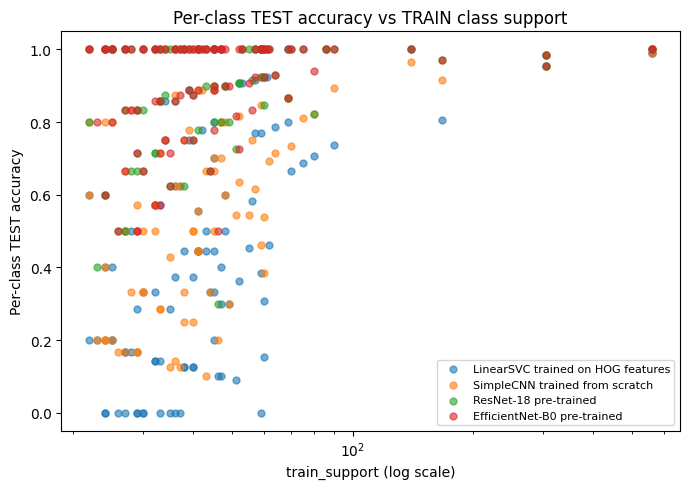

Saved: /content/drive/MyDrive/VictoriaClass/MiniProject1_v3/figures/imbalance_support_plots_seed42/scatter_testacc_vs_train_support.png


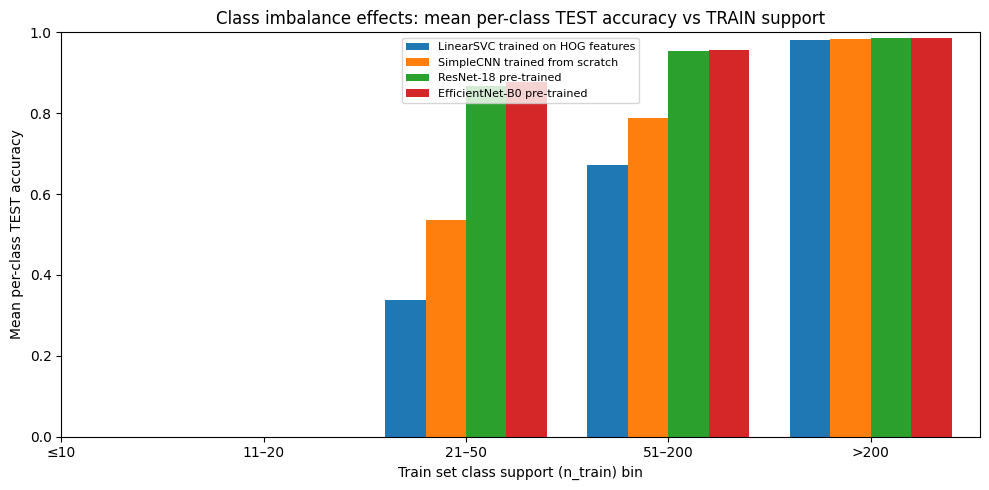

Saved: /content/drive/MyDrive/VictoriaClass/MiniProject1_v3/figures/imbalance_support_plots_seed42/bars_mean_testacc_by_train_support_bin.png
Saved: /content/drive/MyDrive/VictoriaClass/MiniProject1_v3/figures/imbalance_support_plots_seed42/mean_testacc_by_train_support_bin.csv


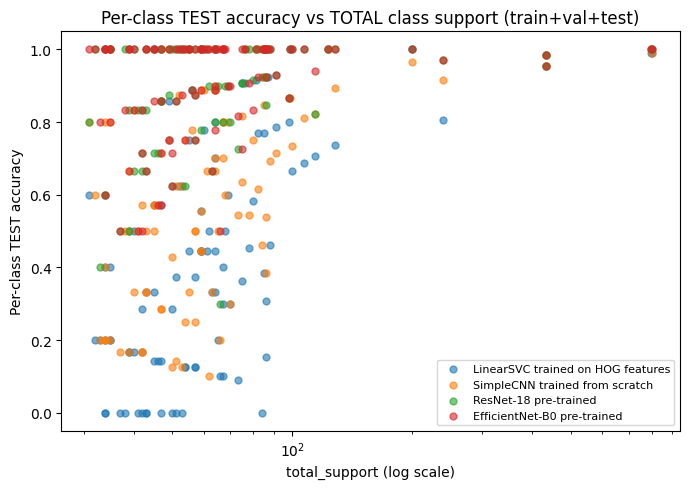

Saved: /content/drive/MyDrive/VictoriaClass/MiniProject1_v3/figures/imbalance_support_plots_seed42/scatter_testacc_vs_total_support.png


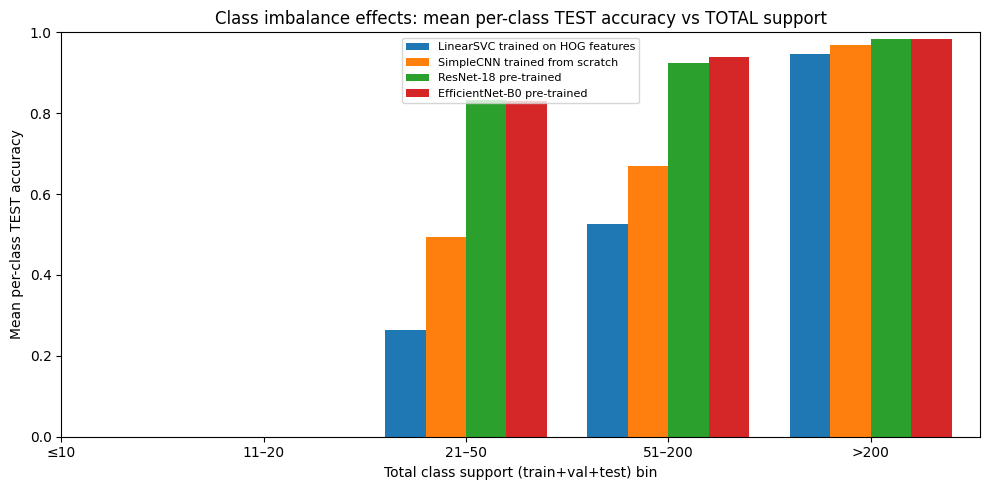

Saved: /content/drive/MyDrive/VictoriaClass/MiniProject1_v3/figures/imbalance_support_plots_seed42/bars_mean_testacc_by_total_support_bin.png
Saved: /content/drive/MyDrive/VictoriaClass/MiniProject1_v3/figures/imbalance_support_plots_seed42/mean_testacc_by_total_support_bin.csv

All outputs saved under: /content/drive/MyDrive/VictoriaClass/MiniProject1_v3/figures/imbalance_support_plots_seed42


In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("/content/drive/MyDrive/VictoriaClass/MiniProject1_v3")
SPLITS_DIR = PROJECT_ROOT / "splits"

train_csv = SPLITS_DIR / "train_seed42.csv"
val_csv   = SPLITS_DIR / "val_seed42.csv"
test_csv  = SPLITS_DIR / "test_seed42.csv"

for p in [train_csv, val_csv, test_csv]:
    assert p.exists(), f"Missing: {p}"

PERCLASS = {
    "LinearSVC trained on HOG features": PROJECT_ROOT / "results" / "classical_hog_svm" / "test_per_class_accuracy.csv",
    "SimpleCNN trained from scratch":    PROJECT_ROOT / "results" / "deep_simplecnn" / "test_per_class_accuracy.csv",
    "ResNet-18 pre-trained":             PROJECT_ROOT / "results" / "deep_resnet18" / "test_per_class_accuracy.csv",
    "EfficientNet-B0 pre-trained":       PROJECT_ROOT / "results" / "deep_efficientnet_b0" / "test_per_class_accuracy.csv",
}
for k, p in PERCLASS.items():
    assert p.exists(), f"Missing per-class CSV for {k}: {p}"

OUT_DIR = PROJECT_ROOT / "figures" / "imbalance_support_plots_seed42"
OUT_DIR.mkdir(parents=True, exist_ok=True)

def load_split_counts(csv_path: Path, split_name: str) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    assert "class_idx" in df.columns, f"{split_name} split missing class_idx. Found: {df.columns.tolist()}"
    counts = df.groupby("class_idx").size().rename(f"{split_name}_support").reset_index()
    counts["class_idx"] = counts["class_idx"].astype(int)
    return counts

def load_perclass_acc_only(path: Path, model_name: str) -> pd.DataFrame:
    """
    Standardize per-class outputs to:
      class_idx, class_name, test_per_class_acc
    We intentionally IGNORE any support columns in the per-class CSV to avoid merge collisions.
    """
    df = pd.read_csv(path).copy()

    # Deep models: class_idx, class_name, n_test, test_per_class_acc
    if {"class_idx", "class_name", "test_per_class_acc"}.issubset(df.columns):
        pass

    # Classical model: class_idx, class_name, test_support, test_accuracy
    elif {"class_idx", "class_name", "test_accuracy"}.issubset(df.columns):
        df = df.rename(columns={"test_accuracy": "test_per_class_acc"})

    else:
        raise ValueError(f"{model_name}: unexpected columns in {path.name}: {df.columns.tolist()}")

    df["class_idx"] = df["class_idx"].astype(int)
    df["test_per_class_acc"] = df["test_per_class_acc"].astype(float)

    return df[["class_idx", "class_name", "test_per_class_acc"]]

def merge_supports(perclass_df: pd.DataFrame,
                   tr_counts: pd.DataFrame,
                   va_counts: pd.DataFrame,
                   te_counts: pd.DataFrame) -> pd.DataFrame:
    out = (perclass_df
           .merge(tr_counts, on="class_idx", how="left")
           .merge(va_counts, on="class_idx", how="left")
           .merge(te_counts, on="class_idx", how="left"))

    for col in ["train_support", "val_support", "test_support"]:
        assert out[col].notna().all(), f"Missing {col} for some classes (check splits)."
        out[col] = out[col].astype(int)

    out["total_support"] = out["train_support"] + out["val_support"] + out["test_support"]
    return out

def plot_scatter(models_dict, xcol, title, out_path):
    plt.figure(figsize=(7, 5))
    for name, df in models_dict.items():
        plt.scatter(df[xcol], df["test_per_class_acc"], alpha=0.6, s=25, label=name)
    plt.xscale("log")
    plt.xlabel(f"{xcol} (log scale)")
    plt.ylabel("Per-class TEST accuracy")
    plt.title(title)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(out_path, dpi=200)
    plt.show()
    print("Saved:", out_path)

def binned_means(df: pd.DataFrame, xcol: str, bins, labels):
    b = df.copy()
    b["support_bin"] = pd.cut(b[xcol], bins=bins, labels=labels, include_lowest=True)
    out = (b.groupby("support_bin", observed=True)["test_per_class_acc"]
             .mean()
             .reindex(labels)
             .reset_index()
             .rename(columns={"test_per_class_acc": "mean_test_per_class_acc"}))
    return out

def plot_bars(means_dict, labels, title, xlabel, out_path):
    x = np.arange(len(labels))
    width = 0.2

    plt.figure(figsize=(10, 5))
    for i, (name, mdf) in enumerate(means_dict.items()):
        plt.bar(x + (i - 1.5)*width, mdf["mean_test_per_class_acc"].values, width=width, label=name)

    plt.ylim(0, 1.0)
    plt.xticks(x, labels)
    plt.xlabel(xlabel)
    plt.ylabel("Mean per-class TEST accuracy")
    plt.title(title)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(out_path, dpi=200)
    plt.show()
    print("Saved:", out_path)

tr_counts = load_split_counts(train_csv, "train")
va_counts = load_split_counts(val_csv, "val")
te_counts = load_split_counts(test_csv, "test")

models = {}
for name, path in PERCLASS.items():
    df = load_perclass_acc_only(path, name)
    df = merge_supports(df, tr_counts, va_counts, te_counts)
    models[name] = df

bins = [0, 10, 20, 50, 200, np.inf]
labels = ["≤10", "11–20", "21–50", "51–200", ">200"]

plot_scatter(
    models,
    xcol="train_support",
    title="Per-class TEST accuracy vs TRAIN class support",
    out_path=OUT_DIR / "scatter_testacc_vs_train_support.png"
)

train_means = {name: binned_means(df, "train_support", bins, labels) for name, df in models.items()}
plot_bars(
    train_means,
    labels=labels,
    title="Class imbalance effects: mean per-class TEST accuracy vs TRAIN support",
    xlabel="Train set class support (n_train) bin",
    out_path=OUT_DIR / "bars_mean_testacc_by_train_support_bin.png"
)

pd.concat(
    [mdf.assign(model=name, support_type="train_support") for name, mdf in train_means.items()],
    ignore_index=True
).to_csv(OUT_DIR / "mean_testacc_by_train_support_bin.csv", index=False)
print("Saved:", OUT_DIR / "mean_testacc_by_train_support_bin.csv")

plot_scatter(
    models,
    xcol="total_support",
    title="Per-class TEST accuracy vs TOTAL class support (train+val+test)",
    out_path=OUT_DIR / "scatter_testacc_vs_total_support.png"
)

total_means = {name: binned_means(df, "total_support", bins, labels) for name, df in models.items()}
plot_bars(
    total_means,
    labels=labels,
    title="Class imbalance effects: mean per-class TEST accuracy vs TOTAL support",
    xlabel="Total class support (train+val+test) bin",
    out_path=OUT_DIR / "bars_mean_testacc_by_total_support_bin.png"
)

pd.concat(
    [mdf.assign(model=name, support_type="total_support") for name, mdf in total_means.items()],
    ignore_index=True
).to_csv(OUT_DIR / "mean_testacc_by_total_support_bin.csv", index=False)
print("Saved:", OUT_DIR / "mean_testacc_by_total_support_bin.csv")

print("\nAll outputs saved under:", OUT_DIR)

In [ ]:
# Ablation 1: IMG_SIZE = 64 (everything else unchanged)

import pandas as pd
from pathlib import Path
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

PROJECT_ROOT = Path("/content/drive/MyDrive/VictoriaClass/MiniProject1_v3")
SPLITS_DIR   = PROJECT_ROOT / "splits"

IMG_SIZE   = 64
BATCH_SIZE = 32
SEED       = 42

train_csv = SPLITS_DIR / f"train_seed{SEED}.csv"
val_csv   = SPLITS_DIR / f"val_seed{SEED}.csv"
test_csv  = SPLITS_DIR / f"test_seed{SEED}.csv"
classmap_csv = SPLITS_DIR / "class_to_idx.csv"

for p in [train_csv, val_csv, test_csv, classmap_csv]:
    assert p.exists(), f"Missing: {p}"

def _infer_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

class_to_idx_df = pd.read_csv(classmap_csv)
class_col = _infer_col(class_to_idx_df, ["class", "class_name", "category", "name", "label"])
idx_col   = _infer_col(class_to_idx_df, ["idx", "class_idx", "index", "id", "target"])
assert class_col and idx_col, f"class_to_idx.csv columns not recognized: {class_to_idx_df.columns.tolist()}"

class_to_idx = dict(zip(class_to_idx_df[class_col].astype(str), class_to_idx_df[idx_col].astype(int)))

def load_split(csv_path: Path):
    df = pd.read_csv(csv_path)

    path_col = _infer_col(df, ["path", "filepath", "image_path", "file", "filename", "fname"])
    y_col    = _infer_col(df, ["class_idx", "idx", "target", "y", "label", "class", "class_name"])
    assert path_col and y_col, f"{csv_path.name} columns not recognized: {df.columns.tolist()}"

    paths = df[path_col].astype(str).tolist()
    y_raw = df[y_col]

    if y_raw.dtype == object:
        ys = [class_to_idx[str(x)] for x in y_raw.astype(str).tolist()]
    else:
        ys = y_raw.astype(int).tolist()

    return paths, ys

train_paths, train_y = load_split(train_csv)
val_paths,   val_y   = load_split(val_csv)
test_paths,  test_y  = load_split(test_csv)

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

tfm = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

class CSVSplitsDataset(Dataset):
    def __init__(self, paths, ys, transform):
        self.paths = paths
        self.ys = ys
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, i):
        img = Image.open(self.paths[i]).convert("RGB")
        x = self.transform(img)
        y = int(self.ys[i])
        return x, y

train_ds = CSVSplitsDataset(train_paths, train_y, tfm)
val_ds   = CSVSplitsDataset(val_paths,   val_y,   tfm)
test_ds  = CSVSplitsDataset(test_paths,  test_y,  tfm)

g = torch.Generator()
g.manual_seed(SEED)

train_loader_64 = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                             num_workers=2, pin_memory=True, generator=g)
val_loader_64   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                             num_workers=2, pin_memory=True)
test_loader_64  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                             num_workers=2, pin_memory=True)

xb, yb = next(iter(train_loader_64))
print("IMG_SIZE =", IMG_SIZE)
print("Batch x:", xb.shape, "Batch y:", yb.shape, "y min/max:", int(yb.min()), int(yb.max()))

IMG_SIZE = 64
Batch x: torch.Size([32, 3, 64, 64]) Batch y: torch.Size([32]) y min/max: 1 96


In [ ]:
#Ablation 1 Image Size for LinearSVC trained on HOG Features

import json, time
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image

from skimage.feature import hog
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

# Config (KEEP SAME as before except IMG_SIZE)
PROJECT_ROOT = Path("/content/drive/MyDrive/VictoriaClass/MiniProject1_v3")
SPLITS_DIR = PROJECT_ROOT / "splits"

train_csv = SPLITS_DIR / "train_seed42.csv"
val_csv   = SPLITS_DIR / "val_seed42.csv"
test_csv  = SPLITS_DIR / "test_seed42.csv"

for p in [train_csv, val_csv, test_csv]:
    assert p.exists(), f"Missing split CSV: {p}"

IMG_SIZE = (64, 64)     # <-- ablation change (was 128,128)
USE_RGB = True          # keep RGB
SEED = 42

# Same HOG settings as before
hog_kwargs = dict(
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2),
    block_norm="L2-Hys",
    feature_vector=True,
)

# Output dirs for this ablation
OUT_RES_DIR   = PROJECT_ROOT / "results" / "classical_hog_svm_rgb64"
OUT_MODEL_DIR = PROJECT_ROOT / "models"  / "classical_hog_svm_rgb64"
OUT_RES_DIR.mkdir(parents=True, exist_ok=True)
OUT_MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("Running HOG+LinearSVC ablation with IMG_SIZE=", IMG_SIZE)
print("Splits:", train_csv.name, val_csv.name, test_csv.name)
print("Results dir:", OUT_RES_DIR)

# Helpers
def load_split(csv_path: Path) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    required = {"path", "class_idx"}
    assert required.issubset(df.columns), f"{csv_path.name} missing columns. Found: {df.columns.tolist()}"
    return df

def rgb_hog_feature(img_rgb_float01: np.ndarray) -> np.ndarray:
    """
    Compute RGB HOG exactly like your prior notebook:
    - Prefer skimage hog(..., channel_axis=-1)
    - Fallback to per-channel concat if needed
    """
    try:
        v = hog(img_rgb_float01, channel_axis=-1, **hog_kwargs)
    except TypeError:
        v = np.concatenate([hog(img_rgb_float01[..., ch], **hog_kwargs) for ch in range(3)])
    return v.astype(np.float32)

def extract_hog_matrix(df: pd.DataFrame, img_size=(64,64)) -> tuple[np.ndarray, np.ndarray, str]:
    fp0 = df.iloc[0]["path"]
    with Image.open(fp0) as im:
        im = im.convert("RGB")
        im = im.resize(img_size, resample=Image.BILINEAR)
    img0 = (np.asarray(im).astype(np.float32) / 255.0)
    try:
        v0 = hog(img0, channel_axis=-1, **hog_kwargs)
        hog_mode = "RGB HOG via channel_axis=-1"
    except TypeError:
        v0 = np.concatenate([hog(img0[..., ch], **hog_kwargs) for ch in range(3)])
        hog_mode = "RGB HOG via per-channel concat fallback"

    feat_dim = int(v0.shape[0])
    X = np.zeros((len(df), feat_dim), dtype=np.float32)
    y = df["class_idx"].astype(np.int64).to_numpy()

    t0 = time.time()
    for i, fp in enumerate(df["path"].tolist()):
        with Image.open(fp) as im:
            im = im.convert("RGB")
            im = im.resize(img_size, resample=Image.BILINEAR)
        img = (np.asarray(im).astype(np.float32) / 255.0)
        X[i] = rgb_hog_feature(img)
    dt = time.time() - t0

    return X, y, hog_mode

train_df = load_split(train_csv)
val_df   = load_split(val_csv)
test_df  = load_split(test_csv)

X_train, y_train, hog_mode = extract_hog_matrix(train_df, IMG_SIZE)
X_val,   y_val,   _        = extract_hog_matrix(val_df,   IMG_SIZE)
X_test,  y_test,  _        = extract_hog_matrix(test_df,  IMG_SIZE)

print("\nHOG mode:", hog_mode)
print("X_train:", X_train.shape, "X_val:", X_val.shape, "X_test:", X_test.shape)

np.save(OUT_RES_DIR / "X_train.npy", X_train)
np.save(OUT_RES_DIR / "y_train.npy", y_train)
np.save(OUT_RES_DIR / "X_val.npy",   X_val)
np.save(OUT_RES_DIR / "y_val.npy",   y_val)
np.save(OUT_RES_DIR / "X_test.npy",  X_test)
np.save(OUT_RES_DIR / "y_test.npy",  y_test)

# C sweep on validation (same procedure as before)
C_grid = [0.01, 0.1, 1.0, 10.0]
rows = []
best = {"C": None, "val_acc": -1.0}

for C in C_grid:
    clf = LinearSVC(C=C, random_state=SEED, max_iter=10000)
    clf.fit(X_train, y_train)
    val_pred = clf.predict(X_val)
    val_acc = accuracy_score(y_val, val_pred)

    rows.append({"C": C, "val_acc": float(val_acc)})
    if val_acc > best["val_acc"]:
        best = {"C": C, "val_acc": float(val_acc)}

sweep_df = pd.DataFrame(rows)
sweep_path = OUT_RES_DIR / "C_sweep_val.csv"
sweep_df.to_csv(sweep_path, index=False)

print("\nC sweep (val):")
print(sweep_df)
print("Best C:", best["C"], "| best val acc:", round(best["val_acc"], 6))
print("Saved:", sweep_path)

run_cfg = {
    "model": "HOG + LinearSVC",
    "img_size": list(IMG_SIZE),
    "hog_mode": hog_mode,
    "hog_kwargs": hog_kwargs,
    "C_grid": C_grid,
    "best_C": best["C"],
    "best_val_acc": best["val_acc"],
    "seed": SEED,
}
with open(OUT_RES_DIR / "run_config.json", "w") as f:
    json.dump(run_cfg, f, indent=2)

print("Wrote:", OUT_RES_DIR / "run_config.json")

Running HOG+LinearSVC ablation with IMG_SIZE= (64, 64)
Splits: train_seed42.csv val_seed42.csv test_seed42.csv
Results dir: /content/drive/MyDrive/VictoriaClass/MiniProject1_v3/results/classical_hog_svm_rgb64

HOG mode: RGB HOG via channel_axis=-1
X_train: (6073, 1764) X_val: (1302, 1764) X_test: (1302, 1764)

C sweep (val):
       C   val_acc
0   0.01  0.657450
1   0.10  0.669739
2   1.00  0.629032
3  10.00  0.615975
Best C: 0.1 | best val acc: 0.669739
Saved: /content/drive/MyDrive/VictoriaClass/MiniProject1_v3/results/classical_hog_svm_rgb64/C_sweep_val.csv
Wrote: /content/drive/MyDrive/VictoriaClass/MiniProject1_v3/results/classical_hog_svm_rgb64/run_config.json


In [ ]:
# HOG + LinearSVC (RGB64 ablation): refit on TRAIN+VAL (with best C from val sweep) and evaluate on TEST

import json
import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Paths
PROJECT_ROOT = Path("/content/drive/MyDrive/VictoriaClass/MiniProject1_v3")
SPLITS_DIR   = PROJECT_ROOT / "splits"
MAP_CSV      = SPLITS_DIR / "class_to_idx.csv"

RES_DIR = PROJECT_ROOT / "results" / "classical_hog_svm_rgb64"
RES_DIR.mkdir(parents=True, exist_ok=True)

Xtr_path = RES_DIR / "X_train.npy"
ytr_path = RES_DIR / "y_train.npy"
Xva_path = RES_DIR / "X_val.npy"
yva_path = RES_DIR / "y_val.npy"
Xte_path = RES_DIR / "X_test.npy"
yte_path = RES_DIR / "y_test.npy"

# C sweep results (val selection)
sweep_path = RES_DIR / "C_sweep_val.csv"

for p in [MAP_CSV, Xtr_path, ytr_path, Xva_path, yva_path, Xte_path, yte_path, sweep_path]:
    assert p.exists(), f"Missing: {p}"

# Class mapping
m = pd.read_csv(MAP_CSV).sort_values("class_idx")
idx_to_class = m["class_name"].tolist()
n_classes = len(idx_to_class)
labels = list(range(n_classes))

# Load cached arrays
X_train = np.load(Xtr_path)
y_train = np.load(ytr_path)
X_val   = np.load(Xva_path)
y_val   = np.load(yva_path)
X_test  = np.load(Xte_path)
y_test  = np.load(yte_path)

print("Loaded cached features:")
print(" X_train:", X_train.shape, "y_train:", y_train.shape)
print(" X_val:  ", X_val.shape,   "y_val:  ", y_val.shape)
print(" X_test: ", X_test.shape,  "y_test: ", y_test.shape)

# Pick best C from validation sweep
sweep = pd.read_csv(sweep_path)
best_row = sweep.loc[sweep["val_acc"].idxmax()]
best_C = float(best_row["C"])
best_val_acc = float(best_row["val_acc"])

print("\nBest C from val sweep:", best_C, "| best val acc:", best_val_acc)

# Refit on train and val
X_fit = np.vstack([X_train, X_val])
y_fit = np.concatenate([y_train, y_val])

# Keep classifier settings stable
clf = make_pipeline(
    StandardScaler(with_mean=True),
    LinearSVC(C=best_C, max_iter=20000, dual=True, random_state=42)
)
clf.fit(X_fit, y_fit)

# Predict on TEST
y_pred = clf.predict(X_test)

scores = clf.decision_function(X_test)  # shape: [N, n_classes]
if scores.ndim == 1:
    scores = np.vstack([-scores, scores]).T

def topk_acc_from_scores(scores, y_true, k):
    topk = np.argsort(-scores, axis=1)[:, :k]
    return float(np.mean([y_true[i] in topk[i] for i in range(len(y_true))]))

top1 = float(accuracy_score(y_test, y_pred))
top5 = topk_acc_from_scores(scores, y_test, k=5)

cm = confusion_matrix(y_test, y_pred, labels=labels)
row_sums = cm.sum(axis=1)
per_class_acc = np.divide(
    np.diag(cm),
    row_sums,
    out=np.zeros_like(row_sums, dtype=float),
    where=row_sums != 0
)

report = classification_report(
    y_test, y_pred,
    labels=labels,
    target_names=idx_to_class,
    output_dict=True,
    zero_division=0
)

print("\nTEST top-1 accuracy:", round(top1, 4))
print("TEST top-5 accuracy:", round(top5, 4))
print("Macro avg (P/R/F1):",
      round(report["macro avg"]["precision"], 4),
      round(report["macro avg"]["recall"], 4),
      round(report["macro avg"]["f1-score"], 4))
print("Weighted avg (P/R/F1):",
      round(report["weighted avg"]["precision"], 4),
      round(report["weighted avg"]["recall"], 4),
      round(report["weighted avg"]["f1-score"], 4))

summary = {
    "model": "HOG + LinearSVC (RGB64 ablation)",
    "preprocessing": "RGB resize to 64x64; RGB HOG; StandardScaler; LinearSVC",
    "img_size": [64, 64],
    "train_fit": "train+val",
    "C_selected_on": "val",
    "best_C": best_C,
    "best_val_acc": best_val_acc,
    "test_accuracy": top1,
    "top1_accuracy": top1,
    "top5_accuracy": top5,
    "macro_avg": {
        "precision": float(report["macro avg"]["precision"]),
        "recall": float(report["macro avg"]["recall"]),
        "f1": float(report["macro avg"]["f1-score"]),
    },
    "weighted_avg": {
        "precision": float(report["weighted avg"]["precision"]),
        "recall": float(report["weighted avg"]["recall"]),
        "f1": float(report["weighted avg"]["f1-score"]),
    }
}
(RES_DIR / "test_summary.json").write_text(json.dumps(summary, indent=2))

pc_df = pd.DataFrame({
    "class_idx": np.arange(n_classes),
    "class_name": idx_to_class,
    "n_test": row_sums,
    "test_per_class_acc": per_class_acc
}).sort_values("test_per_class_acc")
pc_df.to_csv(RES_DIR / "test_per_class_accuracy.csv", index=False)

rep_df = pd.DataFrame(report).T
rep_df.to_csv(RES_DIR / "test_classification_report.csv", index=True)

np.save(RES_DIR / "test_confusion_matrix.npy", cm)

pred_df = pd.DataFrame({"y_true": y_test, "y_pred": y_pred})
pred_df.to_csv(RES_DIR / "test_predictions.csv", index=False)

print("\nSaved outputs to:", RES_DIR)
print(" - test_summary.json")
print(" - test_per_class_accuracy.csv")
print(" - test_classification_report.csv")
print(" - test_confusion_matrix.npy")
print(" - test_predictions.csv")

Loaded cached features:
 X_train: (6073, 1764) y_train: (6073,)
 X_val:   (1302, 1764) y_val:   (1302,)
 X_test:  (1302, 1764) y_test:  (1302,)

Best C from val sweep: 0.1 | best val acc: 0.6697388632872504

TEST top-1 accuracy: 0.573
TEST top-5 accuracy: 0.7419
Macro avg (P/R/F1): 0.43 0.3734 0.3808
Weighted avg (P/R/F1): 0.5882 0.573 0.5676

Saved outputs to: /content/drive/MyDrive/VictoriaClass/MiniProject1_v3/results/classical_hog_svm_rgb64
 - test_summary.json
 - test_per_class_accuracy.csv
 - test_classification_report.csv
 - test_confusion_matrix.npy
 - test_predictions.csv


In [ ]:
# Deep ablation setup IMG_SIZE=64, keep everything else identical

import pandas as pd
from pathlib import Path
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

IMG_SIZE   = 64
BATCH_SIZE = 32
SEED       = 42

PROJECT_ROOT = Path("/content/drive/MyDrive/VictoriaClass/MiniProject1_v3")
SPLITS_DIR   = PROJECT_ROOT / "splits"
MAP_CSV      = SPLITS_DIR / "class_to_idx.csv"

train_csv = SPLITS_DIR / "train_seed42.csv"
val_csv   = SPLITS_DIR / "val_seed42.csv"
test_csv  = SPLITS_DIR / "test_seed42.csv"

for p in [train_csv, val_csv, test_csv, MAP_CSV]:
    assert p.exists(), f"Missing: {p}"

m = pd.read_csv(MAP_CSV).sort_values("class_idx")
idx_to_class = m["class_name"].tolist()
n_classes = len(idx_to_class)
print("Num classes:", n_classes)

# ImageNet normalization (same as primary deep models)
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std =[0.229, 0.224, 0.225])

train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    normalize,
])

eval_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    normalize,
])

class CaltechCSVDataset(Dataset):
    def __init__(self, csv_path, transform):
        self.df = pd.read_csv(csv_path)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        fp = self.df.loc[idx, "path"]
        y  = int(self.df.loc[idx, "class_idx"])
        with Image.open(fp) as im:
            im = im.convert("RGB")
            x = self.transform(im)
        return x, y

train_ds = CaltechCSVDataset(train_csv, train_tfms)
val_ds   = CaltechCSVDataset(val_csv,   eval_tfms)
test_ds  = CaltechCSVDataset(test_csv,  eval_tfms)

print("Sizes (train/val/test):", len(train_ds), len(val_ds), len(test_ds))

g = torch.Generator()
g.manual_seed(SEED)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True, generator=g)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

xb, yb = next(iter(train_loader))
print("Batch x:", xb.shape, "Batch y:", yb.shape, "y min/max:", int(yb.min()), int(yb.max()))

Num classes: 101
Sizes (train/val/test): 6073 1302 1302
Batch x: torch.Size([32, 3, 64, 64]) Batch y: torch.Size([32]) y min/max: 1 96


In [ ]:
# SimpleCNN from scratch (IMG_SIZE=64 version)

import torch
import torch.nn as nn

class SimpleCNN64(nn.Module):
    def __init__(self, num_classes=101):
        super().__init__()
        self.features = nn.Sequential(
            # input: 64x64
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 32x32

            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 16x16

            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 8x8

            nn.Conv2d(128, 256, kernel_size=3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 4x4
        )
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleCNN64(num_classes=n_classes).to(device)

n_params = sum(p.numel() for p in model.parameters())
print("Model:", model.__class__.__name__)
print("Parameters:", f"{n_params:,}")

xb, yb = next(iter(train_loader))
xb = xb.to(device)
with torch.no_grad():
    logits = model(xb)
print("Logits shape:", logits.shape)  # should be [32, 101]

Model: SimpleCNN64
Parameters: 2,538,853
Logits shape: torch.Size([32, 101])


In [ ]:
# Setup and Train SimpleCNN from scratch (RGB64 ablation)

import time, json
import numpy as np
import pandas as pd
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim

assert "train_loader" in globals() and "val_loader" in globals() and "test_loader" in globals()
assert "idx_to_class" in globals() and "n_classes" in globals()
assert "IMG_SIZE" in globals() and IMG_SIZE == 64, f"Expected IMG_SIZE=64, got {globals().get('IMG_SIZE')}"
assert "BATCH_SIZE" in globals() and BATCH_SIZE == 32
assert "LR" in globals() and abs(LR - 1e-4) < 1e-12
assert "EPOCHS" in globals() and EPOCHS == 100

PROJECT_ROOT = Path("/content/drive/MyDrive/VictoriaClass/MiniProject1_v3")
MODEL_DIR   = PROJECT_ROOT / "models"  / "deep_simplecnn_rgb64"
RESULTS_DIR = PROJECT_ROOT / "results" / "deep_simplecnn_rgb64"
FIG_DIR     = PROJECT_ROOT / "figures" / "deep_simplecnn_rgb64"
for d in [MODEL_DIR, RESULTS_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

best_ckpt_path = MODEL_DIR / "best.pt"

run_config = {
    "model": "SimpleCNN (scratch)",
    "ablation": "IMG_SIZE=64 (RGB) vs 128 baseline",
    "img_size": int(IMG_SIZE),
    "batch_size": int(BATCH_SIZE),
    "lr": float(LR),
    "epochs": int(EPOCHS),
    "optimizer": "Adam",
    "seed": int(globals().get("SEED", 42)),
    "preprocessing": "RGB resize to IMG_SIZE x IMG_SIZE + ImageNet normalization",
}
with open(RESULTS_DIR / "run_config.json", "w") as f:
    json.dump(run_config, f, indent=2)

print("Device:", device)
print(f"Config: IMG_SIZE={IMG_SIZE} | BATCH_SIZE={BATCH_SIZE} | LR={LR} | EPOCHS={EPOCHS}")
print("Checkpoint path:", best_ckpt_path)
print("Wrote run config:", RESULTS_DIR / "run_config.json")

def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)

    total_loss = 0.0
    total_correct = 0
    total_n = 0

    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        logits = model(xb)
        loss = criterion(logits, yb)

        if is_train:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * xb.size(0)
        total_correct += (logits.argmax(dim=1) == yb).sum().item()
        total_n += xb.size(0)

    return total_loss / total_n, total_correct / total_n

history = []
best_val_acc = -1.0
best_epoch = -1

t_start = time.time()
for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    train_loss, train_acc = run_epoch(model, train_loader, optimizer=optimizer)
    val_loss, val_acc     = run_epoch(model, val_loader, optimizer=None)
    dt = time.time() - t0

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch
        torch.save(
            {"model_state": model.state_dict(), "epoch": epoch, "val_acc": val_acc},
            best_ckpt_path
        )

    history.append({
        "epoch": epoch,
        "train_loss": train_loss, "train_acc": train_acc,
        "val_loss": val_loss, "val_acc": val_acc,
        "sec": dt
    })

    print(f"Epoch {epoch:03d}/{EPOCHS} | "
          f"train loss {train_loss:.4f} acc {train_acc:.4f} | "
          f"val loss {val_loss:.4f} acc {val_acc:.4f} | "
          f"{dt:.1f}s")

log_df = pd.DataFrame(history)
log_path = RESULTS_DIR / "training_log.csv"
log_df.to_csv(log_path, index=False)

print(f"\nBest val acc: {best_val_acc:.4f} at epoch {best_epoch}")
print("Saved best checkpoint:", best_ckpt_path)
print("Saved training log:", log_path)
print("Total training time (min):", round((time.time() - t_start) / 60, 2))

Device: cuda
Config: IMG_SIZE=64 | BATCH_SIZE=32 | LR=0.0001 | EPOCHS=100
Checkpoint path: /content/drive/MyDrive/VictoriaClass/MiniProject1_v3/models/deep_simplecnn_rgb64/best.pt
Wrote run config: /content/drive/MyDrive/VictoriaClass/MiniProject1_v3/results/deep_simplecnn_rgb64/run_config.json
Epoch 001/100 | train loss 3.4975 acc 0.2776 | val loss 2.8962 acc 0.3856 | 14.7s
Epoch 002/100 | train loss 2.6472 acc 0.4230 | val loss 2.3960 acc 0.4624 | 11.1s
Epoch 003/100 | train loss 2.1535 acc 0.5110 | val loss 2.0552 acc 0.5338 | 11.1s
Epoch 004/100 | train loss 1.7946 acc 0.5827 | val loss 1.7988 acc 0.5876 | 9.1s
Epoch 005/100 | train loss 1.5051 acc 0.6455 | val loss 1.6135 acc 0.6252 | 11.1s
Epoch 006/100 | train loss 1.2900 acc 0.6916 | val loss 1.5074 acc 0.6490 | 12.9s
Epoch 007/100 | train loss 1.1001 acc 0.7374 | val loss 1.3768 acc 0.6859 | 11.1s
Epoch 008/100 | train loss 0.9592 acc 0.7706 | val loss 1.3492 acc 0.6843 | 10.0s
Epoch 009/100 | train loss 0.8307 acc 0.8014 | va

In [ ]:
# Evaluate SimpleCNN RGB64 ablation on TEST using best-by-val checkpoint

import json
import numpy as np
import pandas as pd
from pathlib import Path
import torch
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

PROJECT_ROOT = Path("/content/drive/MyDrive/VictoriaClass/MiniProject1_v3")
SPLITS_DIR = PROJECT_ROOT / "splits"
MAP_CSV = SPLITS_DIR / "class_to_idx.csv"

MODEL_DIR   = PROJECT_ROOT / "models"  / "deep_simplecnn_rgb64"
RESULTS_DIR = PROJECT_ROOT / "results" / "deep_simplecnn_rgb64"
for d in [RESULTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

ckpt_path = MODEL_DIR / "best.pt"
assert ckpt_path.exists(), f"Missing checkpoint: {ckpt_path}"
assert MAP_CSV.exists(), f"Missing: {MAP_CSV}"

assert "device" in globals()
assert "test_loader" in globals()
assert "model" in globals()

m = pd.read_csv(MAP_CSV).sort_values("class_idx")
idx_to_class = m["class_name"].tolist()
n_classes = len(idx_to_class)
labels = list(range(n_classes))

ckpt = torch.load(ckpt_path, map_location=device)
model.load_state_dict(ckpt["model_state"])
model.to(device)
model.eval()

print("Loaded checkpoint epoch:", ckpt.get("epoch"), "| best_val_acc:", ckpt.get("val_acc"))

all_y = []
all_pred = []
all_scores = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device, non_blocking=True)
        logits = model(xb)  # [B, 101]
        probs = torch.softmax(logits, dim=1)

        all_pred.append(torch.argmax(logits, dim=1).cpu().numpy())
        all_y.append(yb.numpy())
        all_scores.append(probs.cpu().numpy())

y_true = np.concatenate(all_y)
y_pred = np.concatenate(all_pred)
scores = np.concatenate(all_scores)  # [N, 101]

# --- Metrics ---
acc = accuracy_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred, labels=labels)

row_sums = cm.sum(axis=1)
per_class_acc = np.divide(
    np.diag(cm), row_sums,
    out=np.zeros_like(row_sums, dtype=float),
    where=row_sums != 0
)

report = classification_report(
    y_true, y_pred,
    labels=labels,
    target_names=idx_to_class,
    output_dict=True,
    zero_division=0
)

def topk_acc(scores, y_true, k):
    topk = np.argsort(-scores, axis=1)[:, :k]
    return float(np.mean([y_true[i] in topk[i] for i in range(len(y_true))]))

top1 = float(acc)
top5 = topk_acc(scores, y_true, k=5)

print("TEST top-1 accuracy:", round(top1, 4))
print("TEST top-5 accuracy:", round(top5, 4))
print("Macro avg (P/R/F1):",
      round(report["macro avg"]["precision"], 4),
      round(report["macro avg"]["recall"], 4),
      round(report["macro avg"]["f1-score"], 4))
print("Weighted avg (P/R/F1):",
      round(report["weighted avg"]["precision"], 4),
      round(report["weighted avg"]["recall"], 4),
      round(report["weighted avg"]["f1-score"], 4))

summary = {
    "model": "SimpleCNN (scratch)",
    "ablation": "IMG_SIZE=64 (RGB) vs 128 baseline",
    "preprocessing": "RGB resize to 64x64 + ImageNet normalization",
    "best_epoch": int(ckpt.get("epoch", -1)),
    "best_val_acc": float(ckpt.get("val_acc", -1)),
    "test_accuracy": float(acc),
    "top1_accuracy": float(top1),
    "top5_accuracy": float(top5),
    "macro_avg": {
        "precision": float(report["macro avg"]["precision"]),
        "recall": float(report["macro avg"]["recall"]),
        "f1": float(report["macro avg"]["f1-score"]),
    },
    "weighted_avg": {
        "precision": float(report["weighted avg"]["precision"]),
        "recall": float(report["weighted avg"]["recall"]),
        "f1": float(report["weighted avg"]["f1-score"]),
    },
}

with open(RESULTS_DIR / "test_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

pc_df = pd.DataFrame({
    "class_idx": np.arange(n_classes),
    "class_name": idx_to_class,
    "n_test": row_sums,
    "test_per_class_acc": per_class_acc
}).sort_values("test_per_class_acc")
pc_df.to_csv(RESULTS_DIR / "test_per_class_accuracy.csv", index=False)

with open(RESULTS_DIR / "test_classification_report.json", "w") as f:
    json.dump(report, f, indent=2)

np.save(RESULTS_DIR / "test_confusion_matrix.npy", cm)

print("\nSaved outputs to:", RESULTS_DIR)
print(" - test_summary.json")
print(" - test_per_class_accuracy.csv")
print(" - test_classification_report.json")
print(" - test_confusion_matrix.npy")

Loaded checkpoint epoch: 72 | best_val_acc: 0.7672811059907834
TEST top-1 accuracy: 0.7366
TEST top-5 accuracy: 0.894
Macro avg (P/R/F1): 0.6566 0.6019 0.6018
Weighted avg (P/R/F1): 0.7473 0.7366 0.7248

Saved outputs to: /content/drive/MyDrive/VictoriaClass/MiniProject1_v3/results/deep_simplecnn_rgb64
 - test_summary.json
 - test_per_class_accuracy.csv
 - test_classification_report.json
 - test_confusion_matrix.npy


In [ ]:
# Ablation: ResNet-18 FULL fine-tune with IMG_SIZE=64 (keep LR=1e-4, BS=32, EPOCHS=100, same normalization)

import time, json
import numpy as np
import pandas as pd
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

assert "device" in globals()
assert "train_loader" in globals() and "val_loader" in globals() and "test_loader" in globals()
assert "n_classes" in globals()
assert "IMG_SIZE" in globals() and IMG_SIZE == 64
assert "BATCH_SIZE" in globals() and BATCH_SIZE == 32
assert "LR" in globals() and abs(LR - 1e-4) < 1e-12
assert "EPOCHS" in globals() and EPOCHS == 100

PROJECT_ROOT = Path("/content/drive/MyDrive/VictoriaClass/MiniProject1_v3")
OUT_MODEL_DIR = PROJECT_ROOT / "models"  / "deep_resnet18_rgb64"
OUT_RES_DIR   = PROJECT_ROOT / "results" / "deep_resnet18_rgb64"
for d in [OUT_MODEL_DIR, OUT_RES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

best_ckpt_path = OUT_MODEL_DIR / "best.pt"

resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
resnet.fc = nn.Linear(resnet.fc.in_features, n_classes)
resnet = resnet.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(resnet.parameters(), lr=LR)

run_cfg = {
    "model": "ResNet18 (ImageNet pretrained, full fine-tune)",
    "ablation": "IMG_SIZE=64 (RGB) vs 128 baseline",
    "IMG_SIZE": IMG_SIZE,
    "BATCH_SIZE": BATCH_SIZE,
    "LR": LR,
    "EPOCHS": EPOCHS,
    "optimizer": "Adam",
    "preprocessing": "RGB resize to 64x64 + ImageNet normalization",
    "checkpoint_path": str(best_ckpt_path),
}
with open(OUT_RES_DIR / "run_config.json", "w") as f:
    json.dump(run_cfg, f, indent=2)

def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)

    total_loss = 0.0
    total_correct = 0
    total_n = 0

    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        logits = model(xb)
        loss = criterion(logits, yb)

        if is_train:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * xb.size(0)
        total_correct += (logits.argmax(dim=1) == yb).sum().item()
        total_n += xb.size(0)

    return total_loss / total_n, total_correct / total_n

history = []
best_val_acc = -1.0

print("Device:", device)
print(f"Config: IMG_SIZE={IMG_SIZE} | BATCH_SIZE={BATCH_SIZE} | LR={LR} | EPOCHS={EPOCHS}")
print("Checkpoint path:", best_ckpt_path)

t_start = time.time()
for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    train_loss, train_acc = run_epoch(resnet, train_loader, optimizer=optimizer)
    val_loss, val_acc     = run_epoch(resnet, val_loader, optimizer=None)
    dt = time.time() - t0

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(
            {"model_state": resnet.state_dict(), "epoch": epoch, "val_acc": val_acc},
            best_ckpt_path
        )

    history.append({
        "epoch": epoch,
        "train_loss": train_loss, "train_acc": train_acc,
        "val_loss": val_loss, "val_acc": val_acc,
        "sec": dt
    })

    print(f"Epoch {epoch:03d}/{EPOCHS} | "
          f"train loss {train_loss:.4f} acc {train_acc:.4f} | "
          f"val loss {val_loss:.4f} acc {val_acc:.4f} | {dt:.1f}s")

log_df = pd.DataFrame(history)
log_df.to_csv(OUT_RES_DIR / "training_log.csv", index=False)

print("\nBest val acc:", round(best_val_acc, 4))
print("Saved best checkpoint:", best_ckpt_path)
print("Saved training log:", OUT_RES_DIR / "training_log.csv")
print("Total training time (min):", round((time.time() - t_start) / 60, 2))

Device: cuda
Config: IMG_SIZE=64 | BATCH_SIZE=32 | LR=0.0001 | EPOCHS=100
Checkpoint path: /content/drive/MyDrive/VictoriaClass/MiniProject1_v3/models/deep_resnet18_rgb64/best.pt
Epoch 001/100 | train loss 2.3387 acc 0.5154 | val loss 1.2037 acc 0.7473 | 17.6s
Epoch 002/100 | train loss 0.7529 acc 0.8455 | val loss 0.7451 acc 0.8249 | 12.0s
Epoch 003/100 | train loss 0.2635 acc 0.9616 | val loss 0.6253 acc 0.8433 | 12.0s
Epoch 004/100 | train loss 0.1015 acc 0.9900 | val loss 0.5863 acc 0.8610 | 12.3s
Epoch 005/100 | train loss 0.0431 acc 0.9980 | val loss 0.5548 acc 0.8618 | 11.9s
Epoch 006/100 | train loss 0.0240 acc 0.9988 | val loss 0.5512 acc 0.8633 | 12.5s
Epoch 007/100 | train loss 0.0169 acc 0.9993 | val loss 0.5224 acc 0.8740 | 13.0s
Epoch 008/100 | train loss 0.0125 acc 0.9995 | val loss 0.5311 acc 0.8710 | 12.8s
Epoch 009/100 | train loss 0.0084 acc 1.0000 | val loss 0.5128 acc 0.8740 | 12.0s
Epoch 010/100 | train loss 0.0066 acc 1.0000 | val loss 0.5188 acc 0.8740 | 11.4s
E

In [ ]:
# Evaluate ResNet18 RGB64 ablation on TEST

import json
import numpy as np
import pandas as pd
from pathlib import Path

import torch
import torch.nn as nn
from torchvision import models
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

assert "device" in globals()
assert "test_loader" in globals()
assert "n_classes" in globals()
assert "idx_to_class" in globals()
assert "IMG_SIZE" in globals() and IMG_SIZE == 64

PROJECT_ROOT = Path("/content/drive/MyDrive/VictoriaClass/MiniProject1_v3")
MODEL_DIR   = PROJECT_ROOT / "models"  / "deep_resnet18_rgb64"
RESULTS_DIR = PROJECT_ROOT / "results" / "deep_resnet18_rgb64"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

ckpt_path = MODEL_DIR / "best.pt"
assert ckpt_path.exists(), f"Missing checkpoint: {ckpt_path}"

resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
resnet.fc = nn.Linear(resnet.fc.in_features, n_classes)
resnet = resnet.to(device)

ckpt = torch.load(ckpt_path, map_location=device)
resnet.load_state_dict(ckpt["model_state"])
resnet.eval()

print(f"Loaded checkpoint epoch: {ckpt.get('epoch', 'NA')} | best_val_acc: {ckpt.get('val_acc', 'NA')}")

all_y, all_pred, all_scores = [], [], []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device, non_blocking=True)
        logits = resnet(xb)                 # [B, 101]
        probs = torch.softmax(logits, dim=1)

        all_scores.append(probs.cpu().numpy())
        all_pred.append(logits.argmax(dim=1).cpu().numpy())
        all_y.append(yb.numpy())

y_true = np.concatenate(all_y)
y_pred = np.concatenate(all_pred)
scores = np.concatenate(all_scores)  # [N, 101]

labels = list(range(n_classes))

acc = accuracy_score(y_true, y_pred)

def topk_acc(scores, y_true, k):
    topk = np.argsort(-scores, axis=1)[:, :k]
    return float(np.mean([y_true[i] in topk[i] for i in range(len(y_true))]))

top1 = float(acc)
top5 = topk_acc(scores, y_true, k=5)

cm = confusion_matrix(y_true, y_pred, labels=labels)
row_sums = cm.sum(axis=1)
per_class_acc = np.divide(
    np.diag(cm), row_sums,
    out=np.zeros_like(row_sums, dtype=float),
    where=row_sums != 0
)

report = classification_report(
    y_true, y_pred,
    labels=labels,
    target_names=idx_to_class,
    output_dict=True,
    zero_division=0
)

print("TEST top-1 accuracy:", round(top1, 4))
print("TEST top-5 accuracy:", round(top5, 4))
print("Macro avg (P/R/F1):",
      round(report["macro avg"]["precision"], 4),
      round(report["macro avg"]["recall"], 4),
      round(report["macro avg"]["f1-score"], 4))
print("Weighted avg (P/R/F1):",
      round(report["weighted avg"]["precision"], 4),
      round(report["weighted avg"]["recall"], 4),
      round(report["weighted avg"]["f1-score"], 4))

summary = {
    "model": "ResNet18 (ImageNet pretrained, FULL fine-tune) — RGB64 ablation",
    "preprocessing": "RGB resize to 64x64 + ImageNet normalization",
    "batch_size": int(globals().get("BATCH_SIZE", 32)),
    "optimizer": "Adam",
    "lr": float(globals().get("LR", 1e-4)),
    "epochs_budget": int(globals().get("EPOCHS", 100)),
    "best_epoch": int(ckpt.get("epoch", -1)),
    "best_val_acc": float(ckpt.get("val_acc", -1)),
    "test_accuracy": float(top1),
    "top1_accuracy": float(top1),
    "top5_accuracy": float(top5),
    "macro_avg": {
        "precision": float(report["macro avg"]["precision"]),
        "recall": float(report["macro avg"]["recall"]),
        "f1": float(report["macro avg"]["f1-score"]),
    },
    "weighted_avg": {
        "precision": float(report["weighted avg"]["precision"]),
        "recall": float(report["weighted avg"]["recall"]),
        "f1": float(report["weighted avg"]["f1-score"]),
    },
}

with open(RESULTS_DIR / "test_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

pc_df = pd.DataFrame({
    "class_idx": np.arange(n_classes),
    "class_name": idx_to_class,
    "n_test": row_sums,
    "test_per_class_acc": per_class_acc
}).sort_values("test_per_class_acc")
pc_df.to_csv(RESULTS_DIR / "test_per_class_accuracy.csv", index=False)

with open(RESULTS_DIR / "test_classification_report.json", "w") as f:
    json.dump(report, f, indent=2)

np.save(RESULTS_DIR / "test_confusion_matrix.npy", cm)

print("\nSaved outputs to:", RESULTS_DIR)
print(" - test_summary.json")
print(" - test_per_class_accuracy.csv")
print(" - test_classification_report.json")
print(" - test_confusion_matrix.npy")

Loaded checkpoint epoch: 45 | best_val_acc: 0.8901689708141322
TEST top-1 accuracy: 0.8472
TEST top-5 accuracy: 0.9416
Macro avg (P/R/F1): 0.7994 0.7724 0.7722
Weighted avg (P/R/F1): 0.8552 0.8472 0.8416

Saved outputs to: /content/drive/MyDrive/VictoriaClass/MiniProject1_v3/results/deep_resnet18_rgb64
 - test_summary.json
 - test_per_class_accuracy.csv
 - test_classification_report.json
 - test_confusion_matrix.npy


In [ ]:
# EfficientNet-B0 RGB64 ablation FULL fine-tune (Adam lr=1e-4, bs=32, epochs=100)

import time, json
import numpy as np
import pandas as pd
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

assert "device" in globals()
assert "train_loader" in globals() and "val_loader" in globals() and "test_loader" in globals()
assert "idx_to_class" in globals() and "n_classes" in globals()
assert "IMG_SIZE" in globals() and IMG_SIZE == 64
assert "BATCH_SIZE" in globals() and BATCH_SIZE == 32
assert "LR" in globals() and abs(LR - 1e-4) < 1e-12
assert "EPOCHS" in globals() and EPOCHS == 100

PROJECT_ROOT = Path("/content/drive/MyDrive/VictoriaClass/MiniProject1_v3")
OUT_MODEL_DIR = PROJECT_ROOT / "models"  / "deep_efficientnet_b0_rgb64"
OUT_RES_DIR   = PROJECT_ROOT / "results" / "deep_efficientnet_b0_rgb64"
for d in [OUT_MODEL_DIR, OUT_RES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

best_ckpt_path = OUT_MODEL_DIR / "best.pt"

print("Device:", device)
print(f"Config: IMG_SIZE={IMG_SIZE} | BATCH_SIZE={BATCH_SIZE} | LR={LR} | EPOCHS={EPOCHS}")
print("Checkpoint path:", best_ckpt_path)

eff = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
in_features = eff.classifier[1].in_features
eff.classifier[1] = nn.Linear(in_features, n_classes)
eff = eff.to(device)

for p in eff.parameters():
    p.requires_grad = True

total_params = sum(p.numel() for p in eff.parameters())
trainable_params = sum(p.numel() for p in eff.parameters() if p.requires_grad)
print("Model: EfficientNet-B0 (pretrained, full fine-tune)")
print(f"Total params: {total_params:,} | Trainable: {trainable_params:,}")

run_config = {
    "model": "EfficientNet-B0 (ImageNet pretrained, FULL fine-tune) — RGB64 ablation",
    "img_size": int(IMG_SIZE),
    "batch_size": int(BATCH_SIZE),
    "optimizer": "Adam",
    "lr": float(LR),
    "epochs_budget": int(EPOCHS),
    "seed": int(globals().get("SEED", 42)),
    "preprocessing": "RGB resize to 64x64 + ImageNet normalization",
}
with open(OUT_RES_DIR / "run_config.json", "w") as f:
    json.dump(run_config, f, indent=2)
print("Wrote run config:", OUT_RES_DIR / "run_config.json")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(eff.parameters(), lr=LR)

def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)
    total_loss, total_correct, total_n = 0.0, 0, 0

    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        logits = model(xb)
        loss = criterion(logits, yb)

        if is_train:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * xb.size(0)
        total_correct += (logits.argmax(dim=1) == yb).sum().item()
        total_n += xb.size(0)

    return total_loss / total_n, total_correct / total_n

history = []
best_val_acc = -1.0
best_epoch = -1

t_start = time.time()
for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    train_loss, train_acc = run_epoch(eff, train_loader, optimizer=optimizer)
    val_loss, val_acc     = run_epoch(eff, val_loader, optimizer=None)
    dt = time.time() - t0

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch
        torch.save(
            {"model_state": eff.state_dict(), "epoch": epoch, "val_acc": float(val_acc)},
            best_ckpt_path
        )

    history.append({
        "epoch": epoch,
        "train_loss": float(train_loss), "train_acc": float(train_acc),
        "val_loss": float(val_loss), "val_acc": float(val_acc),
        "sec": float(dt)
    })

    print(f"Epoch {epoch:03d}/{EPOCHS} | train loss {train_loss:.4f} acc {train_acc:.4f} | "
          f"val loss {val_loss:.4f} acc {val_acc:.4f} | {dt:.1f}s")

pd.DataFrame(history).to_csv(OUT_RES_DIR / "training_log.csv", index=False)

print(f"\nBest val acc: {best_val_acc:.4f} at epoch {best_epoch}")
print("Saved best checkpoint:", best_ckpt_path)
print("Saved training log:", OUT_RES_DIR / "training_log.csv")
print("Total training time (min):", round((time.time() - t_start) / 60, 2))

Device: cuda
Config: IMG_SIZE=64 | BATCH_SIZE=32 | LR=0.0001 | EPOCHS=100
Checkpoint path: /content/drive/MyDrive/VictoriaClass/MiniProject1_v3/models/deep_efficientnet_b0_rgb64/best.pt
Model: EfficientNet-B0 (pretrained, full fine-tune)
Total params: 4,136,929 | Trainable: 4,136,929
Wrote run config: /content/drive/MyDrive/VictoriaClass/MiniProject1_v3/results/deep_efficientnet_b0_rgb64/run_config.json
Epoch 001/100 | train loss 3.6725 acc 0.2666 | val loss 2.8832 acc 0.4339 | 22.5s
Epoch 002/100 | train loss 2.5497 acc 0.4683 | val loss 2.1649 acc 0.5453 | 16.4s
Epoch 003/100 | train loss 1.8408 acc 0.6088 | val loss 1.6006 acc 0.6452 | 16.4s
Epoch 004/100 | train loss 1.3289 acc 0.7044 | val loss 1.2675 acc 0.6989 | 16.1s
Epoch 005/100 | train loss 0.9710 acc 0.7746 | val loss 1.0744 acc 0.7481 | 16.3s
Epoch 006/100 | train loss 0.6935 acc 0.8431 | val loss 0.8914 acc 0.7742 | 16.8s
Epoch 007/100 | train loss 0.5407 acc 0.8803 | val loss 0.8331 acc 0.7980 | 16.3s
Epoch 008/100 | tra

In [ ]:
# EfficientNet-B0 RGB64 ablation TEST evaluation (best checkpoint)

import json
import numpy as np
import pandas as pd
from pathlib import Path

import torch
import torch.nn as nn
from torchvision import models
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

assert "device" in globals()
assert "test_loader" in globals()
assert "idx_to_class" in globals() and "n_classes" in globals()
assert "IMG_SIZE" in globals() and IMG_SIZE == 64

PROJECT_ROOT = Path("/content/drive/MyDrive/VictoriaClass/MiniProject1_v3")
MODEL_DIR = PROJECT_ROOT / "models"  / "deep_efficientnet_b0_rgb64"
RES_DIR   = PROJECT_ROOT / "results" / "deep_efficientnet_b0_rgb64"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
RES_DIR.mkdir(parents=True, exist_ok=True)

best_ckpt_path = MODEL_DIR / "best.pt"
assert best_ckpt_path.exists(), f"Missing checkpoint: {best_ckpt_path}"

eff = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
in_features = eff.classifier[1].in_features
eff.classifier[1] = nn.Linear(in_features, n_classes)
eff = eff.to(device)

ckpt = torch.load(best_ckpt_path, map_location=device)
eff.load_state_dict(ckpt["model_state"])
eff.eval()

print(f"Loaded checkpoint epoch: {ckpt.get('epoch', 'NA')} | best_val_acc: {ckpt.get('val_acc', 'NA')}")

all_y, all_pred, all_scores = [], [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device, non_blocking=True)
        logits = eff(xb)
        probs = torch.softmax(logits, dim=1)
        all_scores.append(probs.cpu().numpy())
        all_pred.append(logits.argmax(dim=1).cpu().numpy())
        all_y.append(yb.numpy())

y_true = np.concatenate(all_y)
y_pred = np.concatenate(all_pred)
scores = np.concatenate(all_scores)

def topk_acc(scores_, y_true_, k):
    topk = np.argsort(-scores_, axis=1)[:, :k]
    return float(np.mean([y_true_[i] in topk[i] for i in range(len(y_true_))]))

top1 = float(accuracy_score(y_true, y_pred))
top5 = topk_acc(scores, y_true, 5)

labels = list(range(n_classes))
cm = confusion_matrix(y_true, y_pred, labels=labels)
row_sums = cm.sum(axis=1)
per_class_acc = np.divide(np.diag(cm), row_sums, out=np.zeros_like(row_sums, dtype=float), where=row_sums != 0)

report = classification_report(
    y_true, y_pred,
    labels=labels,
    target_names=idx_to_class,
    output_dict=True,
    zero_division=0
)

print(f"TEST top-1 accuracy: {top1:.4f}")
print(f"TEST top-5 accuracy: {top5:.4f}")
print("Macro avg (P/R/F1):",
      round(report["macro avg"]["precision"], 4),
      round(report["macro avg"]["recall"], 4),
      round(report["macro avg"]["f1-score"], 4))
print("Weighted avg (P/R/F1):",
      round(report["weighted avg"]["precision"], 4),
      round(report["weighted avg"]["recall"], 4),
      round(report["weighted avg"]["f1-score"], 4))

summary = {
    "model": "EfficientNet-B0 (ImageNet pretrained, FULL fine-tune) — RGB64 ablation",
    "preprocessing": "RGB resize to 64x64 + ImageNet normalization",
    "batch_size": int(globals().get("BATCH_SIZE", 32)),
    "optimizer": "Adam",
    "lr": float(globals().get("LR", 1e-4)),
    "epochs_budget": int(globals().get("EPOCHS", 100)),
    "best_epoch": int(ckpt.get("epoch", -1)),
    "best_val_acc": float(ckpt.get("val_acc", -1)),
    "test_accuracy": float(top1),
    "top5_accuracy": float(top5),
    "macro_avg": {k: float(report["macro avg"][k]) for k in ["precision", "recall", "f1-score"]},
    "weighted_avg": {k: float(report["weighted avg"][k]) for k in ["precision", "recall", "f1-score"]},
}

with open(RES_DIR / "test_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

pd.DataFrame({
    "class_idx": np.arange(n_classes),
    "class_name": idx_to_class,
    "n_test": row_sums,
    "test_per_class_acc": per_class_acc
}).sort_values("test_per_class_acc").to_csv(RES_DIR / "test_per_class_accuracy.csv", index=False)

with open(RES_DIR / "test_classification_report.json", "w") as f:
    json.dump(report, f, indent=2)

np.save(RES_DIR / "test_confusion_matrix.npy", cm)

print("\nSaved outputs to:", RES_DIR)
print(" - test_summary.json")
print(" - test_per_class_accuracy.csv")
print(" - test_classification_report.json")
print(" - test_confusion_matrix.npy")

Loaded checkpoint epoch: 58 | best_val_acc: 0.8725038402457758
TEST top-1 accuracy: 0.8556
TEST top-5 accuracy: 0.9516
Macro avg (P/R/F1): 0.8014 0.7791 0.7781
Weighted avg (P/R/F1): 0.8614 0.8556 0.8513

Saved outputs to: /content/drive/MyDrive/VictoriaClass/MiniProject1_v3/results/deep_efficientnet_b0_rgb64
 - test_summary.json
 - test_per_class_accuracy.csv
 - test_classification_report.json
 - test_confusion_matrix.npy


In [ ]:
# Metrics 64x64 ablation
import json
from pathlib import Path
import pandas as pd
import numpy as np

PROJECT_ROOT = Path("/content/drive/MyDrive/VictoriaClass/MiniProject1_v3")
RESULTS_DIR  = PROJECT_ROOT / "results"

OUT_CSV = RESULTS_DIR / "overall_metrics_table_rgb64.csv"  # change name if you want

MODELS = [
    ("LinearSVC trained on HOG features", RESULTS_DIR / "classical_hog_svm_rgb64"),
    ("SimpleCNN trained from scratch",   RESULTS_DIR / "deep_simplecnn_rgb64"),
    ("ResNet-18 pre-trained",            RESULTS_DIR / "deep_resnet18_rgb64"),
    ("EfficientNet-B0 pre-trained",      RESULTS_DIR / "deep_efficientnet_b0_rgb64"),
]

def _get_metric(d: dict, keys, default=np.nan):
    """Try a list of keys (first that exists)."""
    for k in keys:
        if k in d and d[k] is not None:
            return d[k]
    return default

def _extract_from_test_summary(summary_path: Path):
    s = json.loads(summary_path.read_text())

    top1 = _get_metric(s, ["test_accuracy", "top1_accuracy", "accuracy"])
    top5 = _get_metric(s, ["top5_accuracy", "test_top5_accuracy", "top5"])

    macro = s.get("macro_avg", {}) or {}
    weighted = s.get("weighted_avg", {}) or {}

    macro_p = _get_metric(macro, ["precision"])
    macro_r = _get_metric(macro, ["recall"])
    macro_f = _get_metric(macro, ["f1-score", "f1", "f1_score"])

    w_p = _get_metric(weighted, ["precision"])
    w_r = _get_metric(weighted, ["recall"])
    w_f = _get_metric(weighted, ["f1-score", "f1", "f1_score"])

    return top1, top5, macro_p, macro_r, macro_f, w_p, w_r, w_f

def _extract_from_classification_report(report_path: Path):
    """
    Supports:
      - sklearn classification_report(..., output_dict=True) saved as JSON
      - classification_report saved as CSV with 'macro avg' / 'weighted avg' rows
    """
    if report_path.suffix.lower() == ".json":
        rep = json.loads(report_path.read_text())
        macro = rep.get("macro avg", {}) or {}
        weighted = rep.get("weighted avg", {}) or {}
        macro_p = _get_metric(macro, ["precision"])
        macro_r = _get_metric(macro, ["recall"])
        macro_f = _get_metric(macro, ["f1-score", "f1", "f1_score"])
        w_p     = _get_metric(weighted, ["precision"])
        w_r     = _get_metric(weighted, ["recall"])
        w_f     = _get_metric(weighted, ["f1-score", "f1", "f1_score"])
        return macro_p, macro_r, macro_f, w_p, w_r, w_f

    df = pd.read_csv(report_path)

    label_col = None
    for cand in ["label", "class", "Unnamed: 0"]:
        if cand in df.columns:
            label_col = cand
            break
    if label_col is None:
        label_col = df.columns[0]

    df = df.set_index(label_col)

    def pick_row(name):
        if name in df.index:
            return df.loc[name]
        for idx in df.index:
            if str(idx).strip() == name:
                return df.loc[idx]
        raise KeyError(f"Could not find row '{name}' in classification report CSV index.")

    macro_row = pick_row("macro avg")
    w_row     = pick_row("weighted avg")

    macro_p = float(macro_row["precision"])
    macro_r = float(macro_row["recall"])
    macro_f = float(macro_row["f1-score"])
    w_p     = float(w_row["precision"])
    w_r     = float(w_row["recall"])
    w_f     = float(w_row["f1-score"])

    return macro_p, macro_r, macro_f, w_p, w_r, w_f

rows = []
for pretty_name, model_dir in MODELS:
    summary_path = model_dir / "test_summary.json"
    if not summary_path.exists():
        raise FileNotFoundError(f"Missing test_summary.json for {pretty_name}: {summary_path}")

    top1, top5, macro_p, macro_r, macro_f, w_p, w_r, w_f = _extract_from_test_summary(summary_path)

    if any(pd.isna(x) for x in [macro_f, w_f]):

        cand_reports = [
            model_dir / "test_classification_report.json",
            model_dir / "test_classification_report.csv",
        ]
        report_path = next((p for p in cand_reports if p.exists()), None)

        if report_path is not None:
            rp, rr, rf, wp, wr, wf = _extract_from_classification_report(report_path)

            if pd.isna(macro_p): macro_p = rp
            if pd.isna(macro_r): macro_r = rr
            if pd.isna(macro_f): macro_f = rf
            if pd.isna(w_p):     w_p     = wp
            if pd.isna(w_r):     w_r     = wr
            if pd.isna(w_f):     w_f     = wf

    rows.append({
        "Model": pretty_name,
        "Top-1 Accuracy": float(top1) if not pd.isna(top1) else np.nan,
        "Top-5 acc":      float(top5) if not pd.isna(top5) else np.nan,
        "Macro precision": float(macro_p) if not pd.isna(macro_p) else np.nan,
        "Macro recall":    float(macro_r) if not pd.isna(macro_r) else np.nan,
        "Macro f1":        float(macro_f) if not pd.isna(macro_f) else np.nan,
        "Weighted precision": float(w_p) if not pd.isna(w_p) else np.nan,
        "Weighted recall":    float(w_r) if not pd.isna(w_r) else np.nan,
        "Weighted F1":        float(w_f) if not pd.isna(w_f) else np.nan,
    })

df = pd.DataFrame(rows)

pd.set_option("display.max_colwidth", 200)
display(df)

df.to_csv(OUT_CSV, index=False)
print("Saved:", OUT_CSV)

print("\nMarkdown table:\n")
print(df.to_markdown(index=False))

,Model,Top-1 Accuracy,Top-5 acc,Macro precision,Macro recall,Macro f1,Weighted precision,Weighted recall,Weighted F1
0,LinearSVC trained on HOG features,0.572965,0.741935,0.429996,0.373368,0.380798,0.588225,0.572965,0.567621
1,SimpleCNN trained from scratch,0.736559,0.894009,0.656621,0.601880,0.601774,0.747345,0.736559,0.724776
2,ResNet-18 pre-trained,0.847158,0.941628,0.799400,0.772436,0.772232,0.855244,0.847158,0.841572
3,EfficientNet-B0 pre-trained,0.855607,0.951613,0.801447,0.779142,0.778058,0.861443,0.855607,0.851273


Saved: /content/drive/MyDrive/VictoriaClass/MiniProject1_v3/results/overall_metrics_table_rgb64.csv

Markdown table:

| Model                             |   Top-1 Accuracy |   Top-5 acc |   Macro precision |   Macro recall |   Macro f1 |   Weighted precision |   Weighted recall |   Weighted F1 |
|:----------------------------------|-----------------:|------------:|------------------:|---------------:|-----------:|---------------------:|------------------:|--------------:|
| LinearSVC trained on HOG features |         0.572965 |    0.741935 |          0.429996 |       0.373368 |   0.380798 |             0.588225 |          0.572965 |      0.567621 |
| SimpleCNN trained from scratch    |         0.736559 |    0.894009 |          0.656621 |       0.60188  |   0.601774 |             0.747345 |          0.736559 |      0.724776 |
| ResNet-18 pre-trained             |         0.847158 |    0.941628 |          0.7994   |       0.772436 |   0.772232 |             0.855244 |          0.847158 

Wrote: /content/drive/MyDrive/VictoriaClass/MiniProject1_v3/results/imgsize_ablation_metrics_long.csv


,Model,Top-1 Accuracy (128x128),Top-1 Accuracy (64x64),Top-5 Accuracy (128x128),Top-5 Accuracy (64x64),Macro F1 (128x128),Macro F1 (64x64),Weighted F1 (128x128),Weighted F1 (64x64)
0,LinearSVC trained on HOG features,0.645161,0.572965,0.788018,0.741935,0.453130,0.380798,0.621213,0.567621
1,SimpleCNN trained from scratch,0.754992,0.736559,0.895545,0.894009,0.627281,0.601774,0.747734,0.724776
2,ResNet-18 pre-trained,0.932412,0.847158,0.990015,0.941628,0.895740,0.772232,0.931562,0.841572
3,EfficientNet-B0 pre-trained,0.937788,0.855607,0.987711,0.951613,0.905467,0.778058,0.937244,0.851273


Saved: /content/drive/MyDrive/VictoriaClass/MiniProject1_v3/figures/ablations_imgsize/imgsize_ablation_top1.png


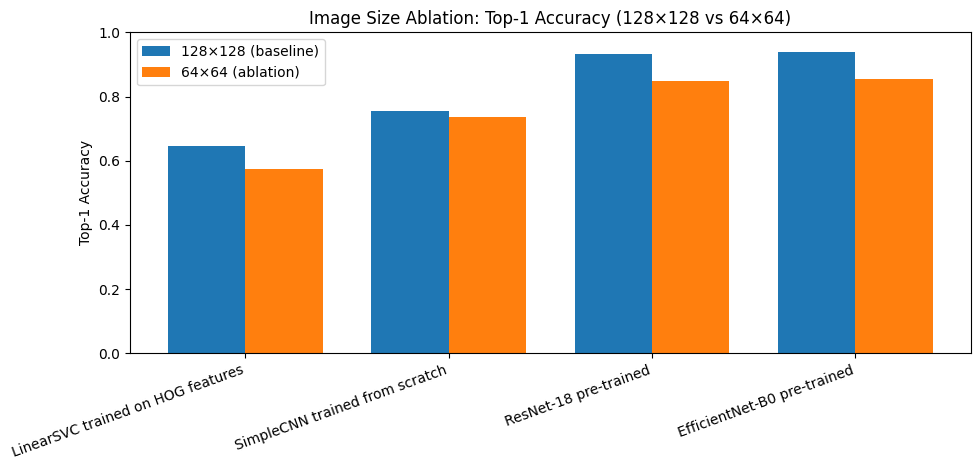

Saved: /content/drive/MyDrive/VictoriaClass/MiniProject1_v3/figures/ablations_imgsize/imgsize_ablation_top5.png


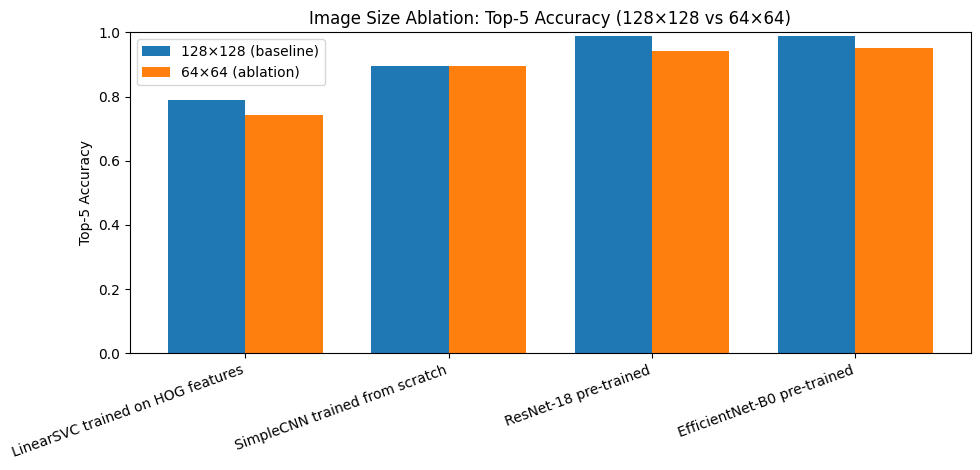

Saved: /content/drive/MyDrive/VictoriaClass/MiniProject1_v3/figures/ablations_imgsize/imgsize_ablation_macro_f1.png


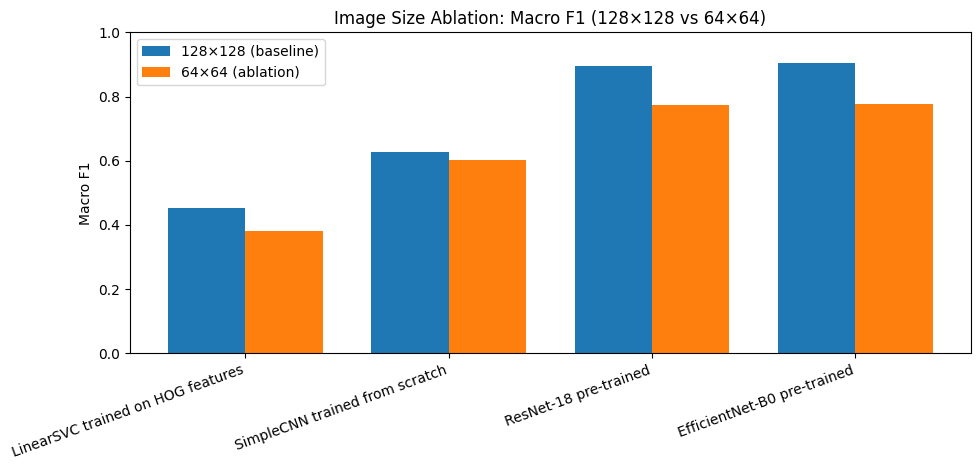

Saved: /content/drive/MyDrive/VictoriaClass/MiniProject1_v3/figures/ablations_imgsize/imgsize_ablation_weighted_f1.png


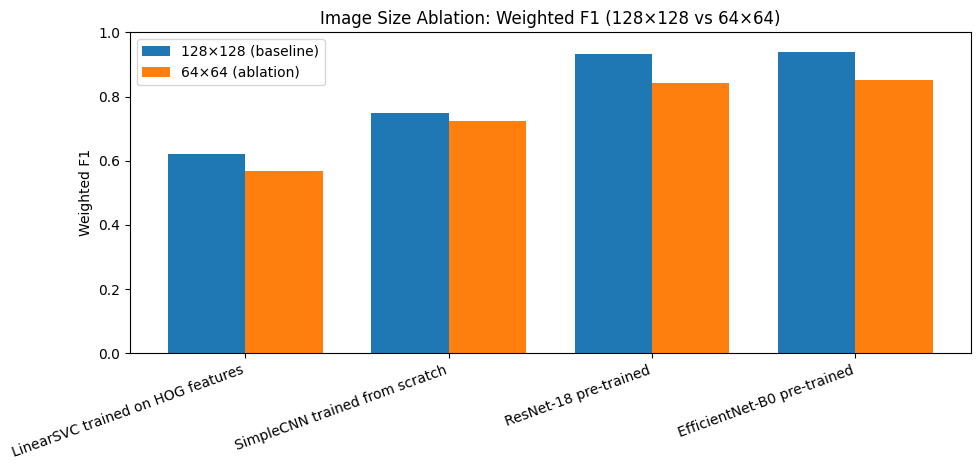

Saved: /content/drive/MyDrive/VictoriaClass/MiniProject1_v3/figures/ablations_imgsize/imgsize_ablation_deltas_64_minus_128.png


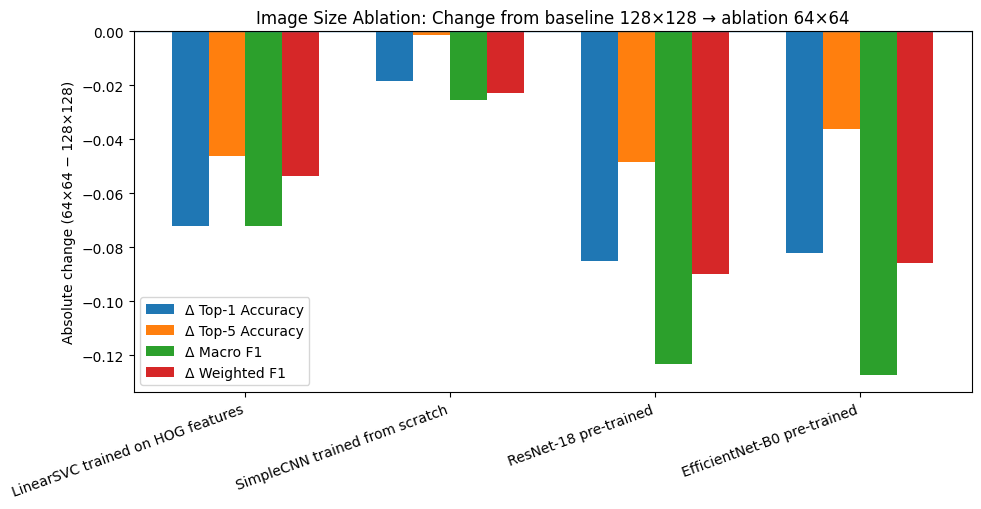

In [ ]:
# Image size ablation plots 128x128 (baseline) vs 64x64 (ablation)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path("/content/drive/MyDrive/VictoriaClass/MiniProject1_v3")
RES_DIR = PROJECT_ROOT / "results"
FIG_DIR = PROJECT_ROOT / "figures" / "ablations_imgsize"
FIG_DIR.mkdir(parents=True, exist_ok=True)

tbl_128 = RES_DIR / "overall_metrics_table_v3.csv"       # 128×128 primary runs
tbl_64  = RES_DIR / "overall_metrics_table_rgb64.csv"    # 64×64 ablation runs

assert tbl_128.exists(), f"Missing: {tbl_128}"
assert tbl_64.exists(),  f"Missing: {tbl_64}"

df128 = pd.read_csv(tbl_128)
df64  = pd.read_csv(tbl_64)

def get_model_col(df: pd.DataFrame) -> str:
    for c in ["Model_display", "Model", "model", "model_name", "display_name"]:
        if c in df.columns:
            return c
    raise ValueError(f"No model label column found. Columns: {df.columns.tolist()}")

model_col_128 = get_model_col(df128)
model_col_64  = get_model_col(df64)

canonical_order = [
    "LinearSVC trained on HOG features",
    "SimpleCNN trained from scratch",
    "ResNet-18 pre-trained",
    "EfficientNet-B0 pre-trained",
]

rename_map = {
    "HOG + LinearSVC (RGB128)": "LinearSVC trained on HOG features",
    "SimpleCNN scratch (RGB128, Adam 1e-4, bs32)": "SimpleCNN trained from scratch",
    "ResNet18 FULL FT (RGB128, Adam 1e-4, bs32)": "ResNet-18 pre-trained",
    "EffNet-B0 FULL FT (RGB128, Adam 1e-4, bs32)": "EfficientNet-B0 pre-trained",
}

df128 = df128.copy()
df64  = df64.copy()
df128["Model_display"] = df128[model_col_128].replace(rename_map)
df64["Model_display"]  = df64[model_col_64].replace(rename_map)

df128 = df128[df128["Model_display"].isin(canonical_order)]
df64  = df64[df64["Model_display"].isin(canonical_order)]

missing_128 = [m for m in canonical_order if m not in set(df128["Model_display"])]
missing_64  = [m for m in canonical_order if m not in set(df64["Model_display"])]
assert not missing_128, f"Missing in 128 table: {missing_128}"
assert not missing_64,  f"Missing in 64 table: {missing_64}"

metrics = [
    ("Top-1 Accuracy", "Top-1 Accuracy"),
    ("Top-5 acc", "Top-5 Accuracy"),
    ("Macro f1", "Macro F1"),
    ("Weighted F1", "Weighted F1"),
]

col_aliases = {
    "Top-1 Accuracy": ["Top-1 Accuracy", "top1", "top1_acc", "test_top1", "test_accuracy"],
    "Top-5 acc": ["Top-5 acc", "Top-5 Accuracy", "top5", "top5_acc", "test_top5"],
    "Macro f1": ["Macro f1", "Macro F1", "macro_f1", "macro_avg_f1"],
    "Weighted F1": ["Weighted F1", "Weighted f1", "weighted_f1", "weighted_avg_f1"],
}

def resolve_col(df: pd.DataFrame, wanted_raw: str) -> str:
    for c in col_aliases[wanted_raw]:
        if c in df.columns:
            return c
    raise KeyError(f"Could not find a column for '{wanted_raw}'. Found: {df.columns.tolist()}")

rows = []
for m in canonical_order:
    r128 = df128[df128["Model_display"] == m].iloc[0]
    r64  = df64[df64["Model_display"] == m].iloc[0]
    row = {"Model": m}
    for raw, pretty in metrics:
        c128 = resolve_col(df128, raw)
        c64  = resolve_col(df64, raw)
        row[f"{pretty} (128x128)"] = float(r128[c128])  # baseline
        row[f"{pretty} (64x64)"]   = float(r64[c64])    # ablation
    rows.append(row)

plot_df = pd.DataFrame(rows)

out_csv = RES_DIR / "imgsize_ablation_metrics_long.csv"
plot_df.to_csv(out_csv, index=False)
print("Wrote:", out_csv)
display(plot_df)

def grouped_bar(metric_pretty: str, ylim=(0, 1.0), fname="plot.png"):
    x = np.arange(len(canonical_order))
    w = 0.38

    y128 = plot_df[f"{metric_pretty} (128x128)"].values
    y64  = plot_df[f"{metric_pretty} (64x64)"].values

    plt.figure(figsize=(10, 4.8))
    plt.bar(x - w/2, y128, width=w, label="128×128 (baseline)")
    plt.bar(x + w/2, y64,  width=w, label="64×64 (ablation)")

    plt.xticks(x, canonical_order, rotation=20, ha="right")
    plt.ylabel(metric_pretty)
    plt.ylim(*ylim)
    plt.title(f"Image Size Ablation: {metric_pretty} (128×128 vs 64×64)")
    plt.legend()
    plt.tight_layout()

    out = FIG_DIR / fname
    plt.savefig(out, dpi=200, bbox_inches="tight")
    print("Saved:", out)
    plt.show()

grouped_bar("Top-1 Accuracy", ylim=(0, 1.0), fname="imgsize_ablation_top1.png")
grouped_bar("Top-5 Accuracy", ylim=(0, 1.0), fname="imgsize_ablation_top5.png")
grouped_bar("Macro F1", ylim=(0, 1.0), fname="imgsize_ablation_macro_f1.png")
grouped_bar("Weighted F1", ylim=(0, 1.0), fname="imgsize_ablation_weighted_f1.png")

delta = pd.DataFrame({"Model": canonical_order})
for _, pretty in metrics:
    delta[f"Δ {pretty} (64-128)"] = plot_df[f"{pretty} (64x64)"] - plot_df[f"{pretty} (128x128)"]

plt.figure(figsize=(10, 5.2))
x = np.arange(len(canonical_order))
w = 0.18
for i, (_, pretty) in enumerate(metrics):
    plt.bar(x + (i - 1.5) * w, delta[f"Δ {pretty} (64-128)"].values, width=w, label=f"Δ {pretty}")

plt.axhline(0, linewidth=1)
plt.xticks(x, canonical_order, rotation=20, ha="right")
plt.ylabel("Absolute change (64×64 − 128×128)")
plt.title("Image Size Ablation: Change from baseline 128×128 → ablation 64×64")
plt.legend()
plt.tight_layout()

out = FIG_DIR / "imgsize_ablation_deltas_64_minus_128.png"
plt.savefig(out, dpi=200, bbox_inches="tight")
print("Saved:", out)
plt.show()

In [ ]:
# Ablation Augmentation on at 128x128

from pathlib import Path
import json
from torchvision import transforms

ROOT = Path("/content/drive/MyDrive/VictoriaClass/MiniProject1_v3")
SPLITS_DIR = ROOT / "splits"
RESULTS_DIR = ROOT / "results"
MODELS_DIR = ROOT / "models"

IMG_SIZE = 128
BATCH_SIZE = 32
LR = 1e-4
EPOCHS = 100
SEED = 42

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_tfms_aug_on = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0), ratio=(0.9, 1.1)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

RUNS_AUG_ON = {
    "deep_simplecnn": {
        "results_dir": RESULTS_DIR / "deep_simplecnn_augON_rgb128",
        "ckpt_dir":    MODELS_DIR   / "deep_simplecnn_augON_rgb128",
    },
    "deep_resnet18": {
        "results_dir": RESULTS_DIR / "deep_resnet18_augON_rgb128",
        "ckpt_dir":    MODELS_DIR   / "deep_resnet18_augON_rgb128",
    },
    "deep_efficientnet_b0": {
        "results_dir": RESULTS_DIR / "deep_efficientnet_b0_augON_rgb128",
        "ckpt_dir":    MODELS_DIR   / "deep_efficientnet_b0_augON_rgb128",
    },
}

for v in RUNS_AUG_ON.values():
    v["results_dir"].mkdir(parents=True, exist_ok=True)
    v["ckpt_dir"].mkdir(parents=True, exist_ok=True)

cfg = {
    "ablation": "augmentation_geometry_only",
    "augment": True,
    "img_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "lr": LR,
    "epochs": EPOCHS,
    "seed": SEED,
    "train_transforms": str(train_tfms_aug_on),
    "eval_transforms": str(eval_tfms),
    "splits": {
        "train": str(SPLITS_DIR / "train_seed42.csv"),
        "val":   str(SPLITS_DIR / "val_seed42.csv"),
        "test":  str(SPLITS_DIR / "test_seed42.csv"),
    }
}

print("AUG ON train transforms:\n", train_tfms_aug_on)
print("\nEval transforms (unchanged):\n", eval_tfms)
print("\nWill write run_config.json into each AUG ON results dir.")

for k, v in RUNS_AUG_ON.items():
    with open(v["results_dir"] / "run_config.json", "w") as f:
        json.dump({**cfg, "model_key": k}, f, indent=2)

AUG ON train transforms:
 Compose(
    RandomResizedCrop(size=(128, 128), scale=(0.8, 1.0), ratio=(0.9, 1.1), interpolation=bilinear, antialias=True)
    RandomHorizontalFlip(p=0.5)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Eval transforms (unchanged):
 Compose(
    Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Will write run_config.json into each AUG ON results dir.


In [ ]:
import json, random
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

SEED = 42
IMG_SIZE = 128
BATCH_SIZE = 32
NUM_WORKERS = 2

PROJECT_ROOT = Path("/content/drive/MyDrive/VictoriaClass/MiniProject1_v3")
SPLITS_DIR = PROJECT_ROOT / "splits"
MAP_CSV = SPLITS_DIR / "class_to_idx.csv"

train_csv = SPLITS_DIR / f"train_seed{SEED}.csv"
val_csv   = SPLITS_DIR / f"val_seed{SEED}.csv"
test_csv  = SPLITS_DIR / f"test_seed{SEED}.csv"

for p in [train_csv, val_csv, test_csv, MAP_CSV]:
    assert p.exists(), f"Missing: {p}"

m = pd.read_csv(MAP_CSV).sort_values("class_idx")
idx_to_class = m["class_name"].tolist()
n_classes = len(idx_to_class)

# Reproducibility
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

g = torch.Generator()
g.manual_seed(SEED)

# Transforms (AUG ON train, eval unchanged)
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std =[0.229, 0.224, 0.225])

train_tfms_aug_on = transforms.Compose([
    transforms.RandomResizedCrop(
        size=(IMG_SIZE, IMG_SIZE),
        scale=(0.8, 1.0),
        ratio=(0.9, 1.1),
        interpolation=transforms.InterpolationMode.BILINEAR,
        antialias=True
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    normalize,
])

eval_tfms = transforms.Compose([
    transforms.Resize(
        size=(IMG_SIZE, IMG_SIZE),
        interpolation=transforms.InterpolationMode.BILINEAR,
        antialias=True
    ),
    transforms.ToTensor(),
    normalize,
])

class CaltechCSVDataset(Dataset):
    def __init__(self, csv_path, transform):
        self.df = pd.read_csv(csv_path)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        fp = self.df.loc[idx, "path"]
        y  = int(self.df.loc[idx, "class_idx"])
        with Image.open(fp) as im:
            im = im.convert("RGB")
            x = self.transform(im)
        return x, y

train_ds = CaltechCSVDataset(train_csv, train_tfms_aug_on)
val_ds   = CaltechCSVDataset(val_csv,   eval_tfms)
test_ds  = CaltechCSVDataset(test_csv,  eval_tfms)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True,
    generator=g
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True
)

print("AUG ON loaders ready:")
print(" train/val/test:", len(train_ds), len(val_ds), len(test_ds))
xb, yb = next(iter(train_loader))
print(" batch:", xb.shape, yb.shape, "y min/max:", int(yb.min()), int(yb.max()))

AUG ON loaders ready:
 train/val/test: 6073 1302 1302
 batch: torch.Size([32, 3, 128, 128]) torch.Size([32]) y min/max: 1 96


In [ ]:
# Ablation AUGMENTATION ON (EfficientNet-B0)

import time, json, random
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Locked settings (MATCH baseline)
SEED = 42
IMG_SIZE = 128
BATCH_SIZE = 32
LR = 1e-4
EPOCHS = 100
NUM_WORKERS = 2

# Paths + splits (MATCH baseline)
PROJECT_ROOT = Path("/content/drive/MyDrive/VictoriaClass/MiniProject1_v3")
SPLITS_DIR = PROJECT_ROOT / "splits"

train_csv = SPLITS_DIR / f"train_seed{SEED}.csv"
val_csv   = SPLITS_DIR / f"val_seed{SEED}.csv"
test_csv  = SPLITS_DIR / f"test_seed{SEED}.csv"
MAP_CSV   = SPLITS_DIR / "class_to_idx.csv"

for p in [train_csv, val_csv, test_csv, MAP_CSV]:
    assert p.exists(), f"Missing: {p}"

m = pd.read_csv(MAP_CSV).sort_values("class_idx")
idx_to_class = m["class_name"].tolist()
n_classes = len(idx_to_class)

# Reproducibility (MATCH baseline)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Device (MATCH baseline pattern)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print(f"Config: IMG_SIZE={IMG_SIZE} | BATCH_SIZE={BATCH_SIZE} | LR={LR} | EPOCHS={EPOCHS} | SEED={SEED}")

# Transforms
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std =[0.229, 0.224, 0.225])

# AUG ON train transform (ONLY change vs baseline eval-style train)
train_tfms_aug_on = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0), ratio=(0.9, 1.1)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    normalize,
])

eval_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    normalize,
])

print("Train transforms (AUG ON):\n", train_tfms_aug_on)
print("\nEval transforms (UNCHANGED):\n", eval_tfms)

# Dataset (MATCH baseline loader expectations)
class CaltechCSVDataset(Dataset):
    def __init__(self, csv_path, transform):
        self.df = pd.read_csv(csv_path)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        fp = self.df.loc[idx, "path"]
        y  = int(self.df.loc[idx, "class_idx"])
        with Image.open(fp) as im:
            im = im.convert("RGB")
            x = self.transform(im)
        return x, y

# Build datasets
train_ds = CaltechCSVDataset(train_csv, train_tfms_aug_on)  # ONLY change is transform
val_ds   = CaltechCSVDataset(val_csv,   eval_tfms)
test_ds  = CaltechCSVDataset(test_csv,  eval_tfms)

# Build loaders (MATCH baseline)
train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True
)

print("\nAUG ON loaders ready:")
print(" train/val/test:", len(train_ds), len(val_ds), len(test_ds))
xb, yb = next(iter(train_loader))
print(" batch:", xb.shape, yb.shape, "y min/max:", int(yb.min()), int(yb.max()))

# Output dir
MODEL_NAME = "deep_efficientnet_b0_augON_rgb128"

MODEL_DIR   = PROJECT_ROOT / "models"  / MODEL_NAME
RESULTS_DIR = PROJECT_ROOT / "results" / MODEL_NAME
FIG_DIR     = PROJECT_ROOT / "figures" / MODEL_NAME
for d in [MODEL_DIR, RESULTS_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

best_ckpt_path = MODEL_DIR / "best.pt"
print("\nCheckpoint:", best_ckpt_path)

# Build model (MATCH baseline)
weights = models.EfficientNet_B0_Weights.DEFAULT
net = models.efficientnet_b0(weights=weights)

# Replace classifier head
in_features = net.classifier[1].in_features
net.classifier[1] = nn.Linear(in_features, n_classes)

# Full fine-tuning
for p in net.parameters():
    p.requires_grad = True

net = net.to(device)

total_params = sum(p.numel() for p in net.parameters())
trainable_params = sum(p.numel() for p in net.parameters() if p.requires_grad)
print("Model: EfficientNet-B0 (pretrained, full fine-tune)")
print(f"Total params: {total_params:,} | Trainable: {trainable_params:,}")

# Forward pass
xb, yb = next(iter(train_loader))
xb = xb.to(device)
with torch.no_grad():
    logits = net(xb)
print("Logits shape:", logits.shape)

# Train setup
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=LR)

run_cfg = {
    "ablation": "augmentation_geometry_only",
    "augment_train": True,
    "model": "EfficientNet-B0 (ImageNet pretrained, FULL fine-tune)",
    "preprocessing_eval": "RGB resize to 128x128 + ImageNet normalization (UNCHANGED)",
    "preprocessing_train": "RandomResizedCrop + RandomHorizontalFlip + ImageNet normalization",
    "input_size": [IMG_SIZE, IMG_SIZE],
    "batch_size": BATCH_SIZE,
    "optimizer": "Adam",
    "lr": LR,
    "epochs": EPOCHS,
    "seed": SEED,
    "checkpoint_best": str(best_ckpt_path),
    "splits": {
        "train": str(train_csv),
        "val": str(val_csv),
        "test": str(test_csv),
    },
}
(RESULTS_DIR / "run_config.json").write_text(json.dumps(run_cfg, indent=2))
print("Wrote run config:", RESULTS_DIR / "run_config.json")

def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)

    total_loss = 0.0
    total_correct = 0
    total_n = 0

    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        logits = model(xb)
        loss = criterion(logits, yb)

        if is_train:
            loss.backward()
            optimizer.step()

        total_loss += float(loss.item()) * xb.size(0)
        total_correct += int((logits.argmax(dim=1) == yb).sum().item())
        total_n += int(xb.size(0))

    return total_loss / total_n, total_correct / total_n

# Train loop
history = []
best_val_acc = -1.0
best_epoch = -1

t_start = time.time()
for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    train_loss, train_acc = run_epoch(net, train_loader, optimizer=optimizer)
    val_loss, val_acc     = run_epoch(net, val_loader, optimizer=None)

    dt = time.time() - t0

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch
        torch.save(
            {"model_state": net.state_dict(), "epoch": epoch, "val_acc": val_acc},
            best_ckpt_path
        )

    history.append({
        "epoch": epoch,
        "train_loss": train_loss, "train_acc": train_acc,
        "val_loss": val_loss,     "val_acc": val_acc,
        "sec": dt
    })

    print(f"Epoch {epoch:03d}/{EPOCHS} | "
          f"train loss {train_loss:.4f} acc {train_acc:.4f} | "
          f"val loss {val_loss:.4f} acc {val_acc:.4f} | "
          f"{dt:.1f}s")

log_df = pd.DataFrame(history)
log_path = RESULTS_DIR / "training_log.csv"
log_df.to_csv(log_path, index=False)

print("\nBest val acc:", round(best_val_acc, 4), "at epoch", best_epoch)
print("Saved best checkpoint:", best_ckpt_path)
print("Saved training log:", log_path)
print("Total training time (min):", round((time.time() - t_start) / 60, 2))

# Test evaluation
ckpt = torch.load(best_ckpt_path, map_location=device)
net.load_state_dict(ckpt["model_state"])
net.eval()

all_y, all_pred, all_scores = [], [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device, non_blocking=True)
        logits = net(xb)
        probs = torch.softmax(logits, dim=1)

        all_scores.append(probs.cpu().numpy())
        all_pred.append(logits.argmax(dim=1).cpu().numpy())
        all_y.append(yb.numpy())

y_true = np.concatenate(all_y)
y_pred = np.concatenate(all_pred)
scores = np.concatenate(all_scores)  # [N, n_classes]

def topk_acc(scores_, y_true_, k):
    topk = np.argsort(-scores_, axis=1)[:, :k]
    return float(np.mean([y_true_[i] in topk[i] for i in range(len(y_true_))]))

acc = accuracy_score(y_true, y_pred)
top1 = float(acc)
top5 = topk_acc(scores, y_true, k=5)

labels = list(range(n_classes))
cm = confusion_matrix(y_true, y_pred, labels=labels)
row_sums = cm.sum(axis=1)
per_class_acc = np.divide(
    np.diag(cm), row_sums,
    out=np.zeros_like(row_sums, dtype=float),
    where=row_sums != 0
)

report = classification_report(
    y_true, y_pred,
    labels=labels,
    target_names=idx_to_class,
    output_dict=True,
    zero_division=0
)

print("\nLoaded checkpoint epoch:", int(ckpt.get("epoch", -1)), "| best_val_acc:", float(ckpt.get("val_acc", -1)))
print("TEST top-1 accuracy:", round(top1, 4))
print("TEST top-5 accuracy:", round(top5, 4))
print("Macro avg (P/R/F1):",
      round(report["macro avg"]["precision"], 4),
      round(report["macro avg"]["recall"], 4),
      round(report["macro avg"]["f1-score"], 4))
print("Weighted avg (P/R/F1):",
      round(report["weighted avg"]["precision"], 4),
      round(report["weighted avg"]["recall"], 4),
      round(report["weighted avg"]["f1-score"], 4))

summary = {
    "model": "EfficientNet-B0 (ImageNet pretrained, FULL fine-tune)",
    "ablation": "augmentation_geometry_only",
    "augment_train": True,
    "preprocessing_eval": "RGB resize to 128x128 + ImageNet normalization (UNCHANGED)",
    "preprocessing_train": "RandomResizedCrop + RandomHorizontalFlip + ImageNet normalization",
    "batch_size": BATCH_SIZE,
    "optimizer": "Adam",
    "lr": LR,
    "epochs_budget": EPOCHS,
    "best_epoch": int(ckpt.get("epoch", -1)),
    "best_val_acc": float(ckpt.get("val_acc", -1)),
    "test_accuracy": float(acc),
    "top1_accuracy": float(top1),
    "top5_accuracy": float(top5),
    "macro_avg": {
        "precision": float(report["macro avg"]["precision"]),
        "recall": float(report["macro avg"]["recall"]),
        "f1": float(report["macro avg"]["f1-score"]),
    },
    "weighted_avg": {
        "precision": float(report["weighted avg"]["precision"]),
        "recall": float(report["weighted avg"]["recall"]),
        "f1": float(report["weighted avg"]["f1-score"]),
    }
}

with open(RESULTS_DIR / "test_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

pd.DataFrame({
    "class_idx": np.arange(n_classes),
    "class_name": idx_to_class,
    "n_test": row_sums,
    "test_per_class_acc": per_class_acc
}).sort_values("test_per_class_acc").to_csv(RESULTS_DIR / "test_per_class_accuracy.csv", index=False)

with open(RESULTS_DIR / "test_classification_report.json", "w") as f:
    json.dump(report, f, indent=2)

np.save(RESULTS_DIR / "test_confusion_matrix.npy", cm)

print("\nSaved outputs to:", RESULTS_DIR)
print(" - run_config.json")
print(" - training_log.csv")
print(" - test_summary.json")
print(" - test_per_class_accuracy.csv")
print(" - test_classification_report.json")
print(" - test_confusion_matrix.npy")

Device: cuda
Config: IMG_SIZE=128 | BATCH_SIZE=32 | LR=0.0001 | EPOCHS=100 | SEED=42
Train transforms (AUG ON):
 Compose(
    RandomResizedCrop(size=(128, 128), scale=(0.8, 1.0), ratio=(0.9, 1.1), interpolation=bilinear, antialias=True)
    RandomHorizontalFlip(p=0.5)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Eval transforms (UNCHANGED):
 Compose(
    Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

AUG ON loaders ready:
 train/val/test: 6073 1302 1302
 batch: torch.Size([32, 3, 128, 128]) torch.Size([32]) y min/max: 1 94

Checkpoint: /content/drive/MyDrive/VictoriaClass/MiniProject1_v3/models/deep_efficientnet_b0_augON_rgb128/best.pt
Model: EfficientNet-B0 (pretrained, full fine-tune)
Total params: 4,136,929 | Trainable: 4,136,929
Logits shape: torch.Size([32, 101])
Wrote run config: /content/drive/MyDrive/VictoriaClass/MiniP

In [8]:
# Ablation Study AUGMENTATION ON ResNet-18

import time, json, random
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Settings (MATCH baseline)
SEED = 42
IMG_SIZE = 128
BATCH_SIZE = 32
LR = 1e-4
EPOCHS = 100
NUM_WORKERS = 2

# Reproducibility (MATCH baseline)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Device (MATCH baseline pattern)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print(f"Config: IMG_SIZE={IMG_SIZE} | BATCH_SIZE={BATCH_SIZE} | LR={LR} | EPOCHS={EPOCHS} | SEED={SEED}")

# Paths and splits (MATCH baseline + no reliance on prior memory)
PROJECT_ROOT = Path("/content/drive/MyDrive/VictoriaClass/MiniProject1_v3")
SPLITS_DIR = PROJECT_ROOT / "splits"

train_csv = SPLITS_DIR / f"train_seed{SEED}.csv"
val_csv   = SPLITS_DIR / f"val_seed{SEED}.csv"
test_csv  = SPLITS_DIR / f"test_seed{SEED}.csv"
MAP_CSV   = SPLITS_DIR / "class_to_idx.csv"

for p in [train_csv, val_csv, test_csv, MAP_CSV]:
    assert p.exists(), f"Missing: {p}"

m = pd.read_csv(MAP_CSV).sort_values("class_idx")
idx_to_class = m["class_name"].tolist()
n_classes = len(idx_to_class)
assert n_classes > 1, "n_classes looks wrong."

# Transforms
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std =[0.229, 0.224, 0.225])

# AUG ON train transform (ONLY change vs baseline)
train_tfms = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0), ratio=(0.9, 1.1)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    normalize,
])

# Eval transform (UNCHANGED)
eval_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    normalize,
])

print("Train transforms (AUG ON):\n", train_tfms)
print("\nEval transforms (UNCHANGED):\n", eval_tfms)

# Dataset and Loaders
class CaltechCSVDataset(Dataset):
    def __init__(self, csv_path, transform):
        self.df = pd.read_csv(csv_path)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        fp = self.df.loc[idx, "path"]
        y  = int(self.df.loc[idx, "class_idx"])
        with Image.open(fp) as im:
            im = im.convert("RGB")
            x = self.transform(im)
        return x, y

train_ds = CaltechCSVDataset(train_csv, train_tfms)
val_ds   = CaltechCSVDataset(val_csv,   eval_tfms)
test_ds  = CaltechCSVDataset(test_csv,  eval_tfms)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True
)

print("\nAUG ON loaders ready:")
print(" train/val/test:", len(train_ds), len(val_ds), len(test_ds))
xb, yb = next(iter(train_loader))
print(" batch:", xb.shape, yb.shape, "y min/max:", int(yb.min()), int(yb.max()))

# Output directories
MODEL_NAME = "deep_resnet18_augON_rgb128"

MODEL_DIR   = PROJECT_ROOT / "models"  / MODEL_NAME
RESULTS_DIR = PROJECT_ROOT / "results" / MODEL_NAME
FIG_DIR     = PROJECT_ROOT / "figures" / MODEL_NAME
for d in [MODEL_DIR, RESULTS_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

best_ckpt_path = MODEL_DIR / "best.pt"

print("\nCheckpoint:", best_ckpt_path)

# Build model (MATCH baseline)
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
resnet.fc = nn.Linear(resnet.fc.in_features, n_classes)
resnet = resnet.to(device)

# Full fine-tuning (MATCH baseline)
for p in resnet.parameters():
    p.requires_grad = True

total_params = sum(p.numel() for p in resnet.parameters())
trainable_params = sum(p.numel() for p in resnet.parameters() if p.requires_grad)
print("Model: ResNet18 (pretrained, full fine-tune)")
print("Total params:", f"{total_params:,} | Trainable:", f"{trainable_params:,}")

# Loss and optimizer (MATCH baseline)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(resnet.parameters(), lr=LR)

# Save run config (same schema as baseline, plus ablation note)
run_cfg = {
    "model": "ResNet18 (ImageNet pretrained, full fine-tune)",
    "input_size": [int(IMG_SIZE), int(IMG_SIZE)],
    "channels": 3,
    "normalization": "ImageNet (mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])",
    "epochs_budget": int(EPOCHS),
    "batch_size": int(BATCH_SIZE),
    "optimizer": "Adam",
    "lr": float(LR),
    "loss": "CrossEntropyLoss",
    "seed_split": 42,
    "seed_torch": 42,
    "augmentation": "ON (RandomResizedCrop(scale=0.8-1.0, ratio=0.9-1.1) + RandomHorizontalFlip(p=0.5))",
    "checkpoint_best": str(best_ckpt_path),
    "ablation": "augmentation_geometry_only",
    "preprocessing_eval": "RGB resize to 128x128 + ImageNet normalization (UNCHANGED)",
}
(RESULTS_DIR / "run_config.json").write_text(json.dumps(run_cfg, indent=2))
print("Wrote run config:", RESULTS_DIR / "run_config.json")

# Train/Val loop (MATCH baseline structure)
def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)

    total_loss = 0.0
    total_correct = 0
    total_n = 0

    if not is_train:
        torch.set_grad_enabled(False)

    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        logits = model(xb)
        loss = criterion(logits, yb)

        if is_train:
            loss.backward()
            optimizer.step()

        total_loss += float(loss.item()) * xb.size(0)
        total_correct += int((logits.argmax(dim=1) == yb).sum().item())
        total_n += int(xb.size(0))

    if not is_train:
        torch.set_grad_enabled(True)

    return total_loss / total_n, total_correct / total_n

history = []
best_val_acc = -1.0
best_epoch = -1

t_start = time.time()
for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    train_loss, train_acc = run_epoch(resnet, train_loader, optimizer=optimizer)
    val_loss, val_acc     = run_epoch(resnet, val_loader, optimizer=None)
    dt = time.time() - t0

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch
        torch.save(
            {"model_state": resnet.state_dict(), "epoch": epoch, "val_acc": val_acc},
            best_ckpt_path
        )

    history.append({
        "epoch": epoch,
        "train_loss": train_loss, "train_acc": train_acc,
        "val_loss": val_loss,     "val_acc": val_acc,
        "sec": dt
    })

    print(f"Epoch {epoch:03d}/{EPOCHS} | "
          f"train loss {train_loss:.4f} acc {train_acc:.4f} | "
          f"val loss {val_loss:.4f} acc {val_acc:.4f} | "
          f"{dt:.1f}s")

log_df = pd.DataFrame(history)
log_path = RESULTS_DIR / "training_log.csv"
log_df.to_csv(log_path, index=False)

print("\nBest val acc:", round(best_val_acc, 4), "at epoch", best_epoch)
print("Saved best checkpoint:", best_ckpt_path)
print("Saved training log:", log_path)
print("Total training time (min):", round((time.time() - t_start) / 60, 2))

# Test evaluation using best checkpoint (MATCH baseline outputs)
assert best_ckpt_path.exists(), f"Missing checkpoint: {best_ckpt_path}"
ckpt = torch.load(best_ckpt_path, map_location=device)
resnet.load_state_dict(ckpt["model_state"])
resnet.eval()

all_y, all_pred, all_scores = [], [], []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device, non_blocking=True)
        logits = resnet(xb)
        probs = torch.softmax(logits, dim=1)

        all_scores.append(probs.cpu().numpy())
        all_pred.append(logits.argmax(dim=1).cpu().numpy())
        all_y.append(yb.numpy())

y_true = np.concatenate(all_y)
y_pred = np.concatenate(all_pred)
scores = np.concatenate(all_scores)

labels = list(range(n_classes))
acc = accuracy_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred, labels=labels)

row_sums = cm.sum(axis=1)
per_class_acc = np.divide(
    np.diag(cm), row_sums,
    out=np.zeros_like(row_sums, dtype=float),
    where=row_sums != 0
)

report = classification_report(
    y_true, y_pred,
    labels=labels,
    target_names=idx_to_class,
    output_dict=True,
    zero_division=0
)

def topk_acc(scores, y_true, k):
    topk = np.argsort(-scores, axis=1)[:, :k]
    return float(np.mean([y_true[i] in topk[i] for i in range(len(y_true))]))

top1 = float(acc)
top5 = topk_acc(scores, y_true, 5)

print("\nLoaded checkpoint epoch:", ckpt.get("epoch", -1), "| best_val_acc:", ckpt.get("val_acc", -1))
print("TEST top-1 accuracy:", round(top1, 4))
print("TEST top-5 accuracy:", round(top5, 4))
print("Macro avg (P/R/F1):",
      round(report["macro avg"]["precision"], 4),
      round(report["macro avg"]["recall"], 4),
      round(report["macro avg"]["f1-score"], 4))
print("Weighted avg (P/R/F1):",
      round(report["weighted avg"]["precision"], 4),
      round(report["weighted avg"]["recall"], 4),
      round(report["weighted avg"]["f1-score"], 4))

summary = {
    "model": "ResNet18 (ImageNet pretrained, FULL fine-tune)",
    "preprocessing": "RGB resize to 128x128 + ImageNet normalization",
    "augmentation": "ON (RandomResizedCrop + RandomHorizontalFlip)",
    "epochs_budget": int(EPOCHS),
    "best_epoch": int(ckpt.get("epoch", -1)),
    "best_val_acc": float(ckpt.get("val_acc", -1)),
    "batch_size": int(BATCH_SIZE),
    "optimizer": "Adam",
    "lr": float(LR),
    "test_accuracy": float(acc),
    "top1_accuracy": float(top1),
    "top5_accuracy": float(top5),
    "macro_avg": {
        "precision": float(report["macro avg"]["precision"]),
        "recall": float(report["macro avg"]["recall"]),
        "f1": float(report["macro avg"]["f1-score"]),
    },
    "weighted_avg": {
        "precision": float(report["weighted avg"]["precision"]),
        "recall": float(report["weighted avg"]["recall"]),
        "f1": float(report["weighted avg"]["f1-score"]),
    },
}

with open(RESULTS_DIR / "test_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

pd.DataFrame({
    "class_idx": np.arange(n_classes),
    "class_name": idx_to_class,
    "n_test": row_sums,
    "test_per_class_acc": per_class_acc
}).sort_values("test_per_class_acc").to_csv(RESULTS_DIR / "test_per_class_accuracy.csv", index=False)

with open(RESULTS_DIR / "test_classification_report.json", "w") as f:
    json.dump(report, f, indent=2)

np.save(RESULTS_DIR / "test_confusion_matrix.npy", cm)

print("\nSaved outputs to:", RESULTS_DIR)
print(" - test_summary.json")
print(" - test_per_class_accuracy.csv")
print(" - test_classification_report.json")
print(" - test_confusion_matrix.npy")
print(" - training_log.csv")

Device: cuda
Config: IMG_SIZE=128 | BATCH_SIZE=32 | LR=0.0001 | EPOCHS=100 | SEED=42
Train transforms (AUG ON):
 Compose(
    RandomResizedCrop(size=(128, 128), scale=(0.8, 1.0), ratio=(0.9, 1.1), interpolation=bilinear, antialias=True)
    RandomHorizontalFlip(p=0.5)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Eval transforms (UNCHANGED):
 Compose(
    Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

AUG ON loaders ready:
 train/val/test: 6073 1302 1302
 batch: torch.Size([32, 3, 128, 128]) torch.Size([32]) y min/max: 1 94

Checkpoint: /content/drive/MyDrive/VictoriaClass/MiniProject1_v3/models/deep_resnet18_augON_rgb128/best.pt
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 134MB/s]


Model: ResNet18 (pretrained, full fine-tune)
Total params: 11,228,325 | Trainable: 11,228,325
Wrote run config: /content/drive/MyDrive/VictoriaClass/MiniProject1_v3/results/deep_resnet18_augON_rgb128/run_config.json
Epoch 001/100 | train loss 1.7235 acc 0.6572 | val loss 0.7160 acc 0.8571 | 28.2s
Epoch 002/100 | train loss 0.3641 acc 0.9412 | val loss 0.4360 acc 0.9017 | 17.2s
Epoch 003/100 | train loss 0.1404 acc 0.9811 | val loss 0.4101 acc 0.9009 | 19.3s
Epoch 004/100 | train loss 0.0705 acc 0.9931 | val loss 0.3339 acc 0.9094 | 16.9s
Epoch 005/100 | train loss 0.0460 acc 0.9944 | val loss 0.3204 acc 0.9117 | 18.5s
Epoch 006/100 | train loss 0.0363 acc 0.9956 | val loss 0.3378 acc 0.9063 | 17.7s
Epoch 007/100 | train loss 0.0202 acc 0.9987 | val loss 0.3227 acc 0.9147 | 16.8s
Epoch 008/100 | train loss 0.0158 acc 0.9992 | val loss 0.2967 acc 0.9201 | 19.0s
Epoch 009/100 | train loss 0.0137 acc 0.9984 | val loss 0.2972 acc 0.9232 | 18.3s
Epoch 010/100 | train loss 0.0107 acc 0.9988 |

In [5]:
# Reload dataset since runtime restarted

!pip -q install -U kagglehub
import os, getpass
import kagglehub

# Set token
os.environ["KAGGLE_API_TOKEN"] = getpass.getpass("KAGGLE_API_TOKEN")

path = kagglehub.dataset_download("imbikramsaha/caltech-101")
print("Downloaded to:", path)

# Check one file
test_fp = "/root/.cache/kagglehub/datasets/imbikramsaha/caltech-101/versions/1/caltech-101/Motorbikes/image_0701.jpg"
print("Exists now?", os.path.exists(test_fp))

KAGGLE_API_TOKEN··········
Using Colab cache for faster access to the 'caltech-101' dataset.
Downloaded to: /kaggle/input/caltech-101
Exists now? False


In [7]:
# Create symlink since dataset path seems to have changed

import os, shutil
from pathlib import Path
import kagglehub

# Download (returns the real location in this runtime)
DATA_ROOT = Path(kagglehub.dataset_download("imbikramsaha/caltech-101"))
CALTECH_DIR = DATA_ROOT / "caltech-101" if (DATA_ROOT / "caltech-101").exists() else DATA_ROOT
print("CALTECH_DIR:", CALTECH_DIR)

# Create the legacy path CSVs expect
legacy = Path("/root/.cache/kagglehub/datasets/imbikramsaha/caltech-101/versions/1/caltech-101")
legacy.parent.mkdir(parents=True, exist_ok=True)

if legacy.exists() or legacy.is_symlink():
    if legacy.is_dir() and not legacy.is_symlink():
        shutil.rmtree(legacy)
    else:
        legacy.unlink()

# Symlink legacy -> actual
os.symlink(str(CALTECH_DIR), str(legacy))

print("Legacy symlink created:")
print(" legacy ->", legacy)
print(" points to ->", CALTECH_DIR)
print("Check file:", (legacy / "scorpion" / "image_0059.jpg").exists())

Using Colab cache for faster access to the 'caltech-101' dataset.
CALTECH_DIR: /kaggle/input/caltech-101/caltech-101
Legacy symlink created:
 legacy -> /root/.cache/kagglehub/datasets/imbikramsaha/caltech-101/versions/1/caltech-101
 points to -> /kaggle/input/caltech-101/caltech-101
Check file: True


In [8]:
# Ablation Study AUGMENTATION ON SimpleCNN trained from scratch

import time, json, random
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Settings (MATCH baseline)
SEED = 42
IMG_SIZE = 128
BATCH_SIZE = 32
LR = 1e-4
EPOCHS = 100
NUM_WORKERS = 2

# Reproducibility (MATCH baseline)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print(f"Config: IMG_SIZE={IMG_SIZE} | BATCH_SIZE={BATCH_SIZE} | LR={LR} | EPOCHS={EPOCHS} | SEED={SEED}")

# Paths and splits
PROJECT_ROOT = Path("/content/drive/MyDrive/VictoriaClass/MiniProject1_v3")
SPLITS_DIR = PROJECT_ROOT / "splits"

train_csv = SPLITS_DIR / f"train_seed{SEED}.csv"
val_csv   = SPLITS_DIR / f"val_seed{SEED}.csv"
test_csv  = SPLITS_DIR / f"test_seed{SEED}.csv"
MAP_CSV   = SPLITS_DIR / "class_to_idx.csv"

for p in [train_csv, val_csv, test_csv, MAP_CSV]:
    assert p.exists(), f"Missing: {p}"

m = pd.read_csv(MAP_CSV).sort_values("class_idx")
idx_to_class = m["class_name"].tolist()
n_classes = len(idx_to_class)
assert n_classes == 101, f"Expected 101 classes; got {n_classes}"

# Transforms
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std =[0.229, 0.224, 0.225])

train_tfms_aug_on = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0), ratio=(0.9, 1.1)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    normalize,
])

eval_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    normalize,
])

print("Train transforms (AUG ON):\n", train_tfms_aug_on)
print("\nEval transforms (UNCHANGED):\n", eval_tfms)

# Dataset and loaders (MATCH baseline style)
class CaltechCSVDataset(Dataset):
    def __init__(self, csv_path, transform):
        self.df = pd.read_csv(csv_path)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        fp = self.df.loc[idx, "path"]
        y  = int(self.df.loc[idx, "class_idx"])
        with Image.open(fp) as im:
            im = im.convert("RGB")
            x = self.transform(im)
        return x, y

train_ds = CaltechCSVDataset(train_csv, train_tfms_aug_on)
val_ds   = CaltechCSVDataset(val_csv,   eval_tfms)
test_ds  = CaltechCSVDataset(test_csv,  eval_tfms)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True
)

print("\nAUG ON loaders ready:")
print(" train/val/test:", len(train_ds), len(val_ds), len(test_ds))
xb, yb = next(iter(train_loader))
print(" batch:", xb.shape, yb.shape, "y min/max:", int(yb.min()), int(yb.max()))

# Output dirs (NEW name, baseline structure)
MODEL_NAME = "deep_simplecnn_augON_rgb128"
MODEL_DIR   = PROJECT_ROOT / "models"  / MODEL_NAME
RESULTS_DIR = PROJECT_ROOT / "results" / MODEL_NAME
FIG_DIR     = PROJECT_ROOT / "figures" / MODEL_NAME
for d in [MODEL_DIR, RESULTS_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

best_ckpt_path = MODEL_DIR / "best.pt"
print("\nCheckpoint:", best_ckpt_path)

# Model: EXACT baseline architecture (SimpleCNN, dropout=0.3)
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=101, dropout=0.3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Flatten(),
            nn.Linear(256 * 8 * 8, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

model = SimpleCNN(num_classes=n_classes, dropout=0.3).to(device)
print("Model: SimpleCNN (from scratch)")
print("Total params:", f"{sum(p.numel() for p in model.parameters()):,} | Trainable:", f"{sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

# Loss and optimizer (MATCH baseline)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

# Save run config (MATCH baseline schema; only augmentation  differs)
run_cfg = {
    "model": "SimpleCNN",
    "input_size": [IMG_SIZE, IMG_SIZE],
    "channels": 3,
    "normalization": "ImageNet",
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "optimizer": "Adam",
    "lr": LR,
    "loss": "CrossEntropyLoss",
    "seed_split": SEED,
    "seed_torch": SEED,
    "augmentation": "ON (RandomResizedCrop(scale=0.8-1.0, ratio=0.9-1.1) + RandomHorizontalFlip(p=0.5))",
    "checkpoint_best": str(best_ckpt_path),
}
(RESULTS_DIR / "run_config.json").write_text(json.dumps(run_cfg, indent=2))
print("Wrote run config:", RESULTS_DIR / "run_config.json")

# Train loop (MATCH baseline logic)
def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)

    total_loss = 0.0
    total_correct = 0
    total_n = 0

    if not is_train:
        with torch.no_grad():
            for xb, yb in loader:
                xb = xb.to(device, non_blocking=True)
                yb = yb.to(device, non_blocking=True)

                logits = model(xb)
                loss = criterion(logits, yb)

                total_loss += float(loss.item()) * xb.size(0)
                preds = torch.argmax(logits, dim=1)
                total_correct += int((preds == yb).sum().item())
                total_n += int(xb.size(0))
    else:
        for xb, yb in loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            logits = model(xb)
            loss = criterion(logits, yb)

            loss.backward()
            optimizer.step()

            total_loss += float(loss.item()) * xb.size(0)
            preds = torch.argmax(logits, dim=1)
            total_correct += int((preds == yb).sum().item())
            total_n += int(xb.size(0))

    return total_loss / total_n, total_correct / total_n

history = []
best_val_acc = -1.0
best_epoch = -1

t_start = time.time()
for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    train_loss, train_acc = run_epoch(model, train_loader, optimizer=optimizer)
    val_loss, val_acc     = run_epoch(model, val_loader, optimizer=None)

    dt = time.time() - t0

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch
        torch.save(
            {
                "model_state": model.state_dict(),
                "epoch": epoch,
                "val_acc": val_acc,
                "train_acc": train_acc,
                "config": {"epochs": EPOCHS, "batch_size": BATCH_SIZE, "lr": LR},
            },
            best_ckpt_path
        )

    history.append({
        "epoch": epoch,
        "train_loss": train_loss, "train_acc": train_acc,
        "val_loss": val_loss,     "val_acc": val_acc,
        "sec": dt
    })

    print(f"Epoch {epoch:03d}/{EPOCHS} | "
          f"train loss {train_loss:.4f} acc {train_acc:.4f} | "
          f"val loss {val_loss:.4f} acc {val_acc:.4f} | "
          f"{dt:.1f}s")

log_df = pd.DataFrame(history)
log_path = RESULTS_DIR / "training_log.csv"
log_df.to_csv(log_path, index=False)

print("\nBest val acc:", round(best_val_acc, 4), "at epoch", best_epoch)
print("Saved best checkpoint:", best_ckpt_path)
print("Saved training log:", log_path)
print("Total training time (min):", round((time.time() - t_start) / 60, 2))

# Test evaluation
assert best_ckpt_path.exists(), f"Missing checkpoint: {best_ckpt_path}"
ckpt = torch.load(best_ckpt_path, map_location=device)
model.load_state_dict(ckpt["model_state"])
model.eval()

all_y, all_pred, all_scores = [], [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device, non_blocking=True)
        logits = model(xb)
        probs = torch.softmax(logits, dim=1)

        all_scores.append(probs.cpu().numpy())
        all_pred.append(logits.argmax(dim=1).cpu().numpy())
        all_y.append(yb.numpy())

y_true = np.concatenate(all_y)
y_pred = np.concatenate(all_pred)
scores = np.concatenate(all_scores)  # [N, n_classes]

def topk_acc(scores_, y_true_, k):
    topk = np.argsort(-scores_, axis=1)[:, :k]
    return float(np.mean([y_true_[i] in topk[i] for i in range(len(y_true_))]))

acc = accuracy_score(y_true, y_pred)
top1 = float(acc)
top5 = topk_acc(scores, y_true, k=5)

labels = list(range(n_classes))
cm = confusion_matrix(y_true, y_pred, labels=labels)
row_sums = cm.sum(axis=1)
per_class_acc = np.divide(
    np.diag(cm), row_sums,
    out=np.zeros_like(row_sums, dtype=float),
    where=row_sums != 0
)

report = classification_report(
    y_true, y_pred,
    labels=labels,
    target_names=idx_to_class,
    output_dict=True,
    zero_division=0
)

print("\nLoaded checkpoint epoch:", int(ckpt.get("epoch", -1)), "| best_val_acc:", float(ckpt.get("val_acc", -1)))
print("TEST top-1 accuracy:", round(top1, 4))
print("TEST top-5 accuracy:", round(top5, 4))
print("Macro avg (P/R/F1):",
      round(report["macro avg"]["precision"], 4),
      round(report["macro avg"]["recall"], 4),
      round(report["macro avg"]["f1-score"], 4))
print("Weighted avg (P/R/F1):",
      round(report["weighted avg"]["precision"], 4),
      round(report["weighted avg"]["recall"], 4),
      round(report["weighted avg"]["f1-score"], 4))

summary = {
    "model": "SimpleCNN",
    "preprocessing": "RGB resize to 128x128 + ImageNet normalization (eval)",
    "augmentation": "ON (RandomResizedCrop + RandomHorizontalFlip) [train only]",
    "epochs_budget": int(EPOCHS),
    "best_epoch": int(ckpt.get("epoch", -1)),
    "best_val_acc": float(ckpt.get("val_acc", -1)),
    "batch_size": int(BATCH_SIZE),
    "optimizer": "Adam",
    "lr": float(LR),
    "test_accuracy": float(acc),
    "top1_accuracy": float(top1),
    "top5_accuracy": float(top5),
    "macro_avg": {
        "precision": float(report["macro avg"]["precision"]),
        "recall": float(report["macro avg"]["recall"]),
        "f1": float(report["macro avg"]["f1-score"]),
    },
    "weighted_avg": {
        "precision": float(report["weighted avg"]["precision"]),
        "recall": float(report["weighted avg"]["recall"]),
        "f1": float(report["weighted avg"]["f1-score"]),
    },
}

with open(RESULTS_DIR / "test_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

pd.DataFrame({
    "class_idx": np.arange(n_classes),
    "class_name": idx_to_class,
    "n_test": row_sums,
    "test_per_class_acc": per_class_acc
}).sort_values("test_per_class_acc").to_csv(RESULTS_DIR / "test_per_class_accuracy.csv", index=False)

with open(RESULTS_DIR / "test_classification_report.json", "w") as f:
    json.dump(report, f, indent=2)

np.save(RESULTS_DIR / "test_confusion_matrix.npy", cm)

print("\nSaved outputs to:", RESULTS_DIR)
print(" - run_config.json")
print(" - training_log.csv")
print(" - test_summary.json")
print(" - test_per_class_accuracy.csv")
print(" - test_classification_report.json")
print(" - test_confusion_matrix.npy")

Device: cuda
Config: IMG_SIZE=128 | BATCH_SIZE=32 | LR=0.0001 | EPOCHS=100 | SEED=42
Train transforms (AUG ON):
 Compose(
    RandomResizedCrop(size=(128, 128), scale=(0.8, 1.0), ratio=(0.9, 1.1), interpolation=bilinear, antialias=True)
    RandomHorizontalFlip(p=0.5)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Eval transforms (UNCHANGED):
 Compose(
    Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

AUG ON loaders ready:
 train/val/test: 6073 1302 1302
 batch: torch.Size([32, 3, 128, 128]) torch.Size([32]) y min/max: 1 94

Checkpoint: /content/drive/MyDrive/VictoriaClass/MiniProject1_v3/models/deep_simplecnn_augON_rgb128/best.pt
Model: SimpleCNN (from scratch)
Total params: 8,830,309 | Trainable: 8,830,309
Wrote run config: /content/drive/MyDrive/VictoriaClass/MiniProject1_v3/results/deep_simplecnn_augON_rgb128/run_config.json

In [9]:
# Print metrics for augmentation on ablation

import json
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path("/content/drive/MyDrive/VictoriaClass/MiniProject1_v3")
RESULTS_ROOT = PROJECT_ROOT / "results"

AUG_ON_RUNS = {
    "CNN trained\nfrom scratch": "deep_simplecnn_augON_rgb128",
    "ResNet-18\npre-trained":    "deep_resnet18_augON_rgb128",
    "EfficientNet-\nB0 pre-trained": "deep_efficientnet_b0_augON_rgb128",  # <- change if needed
}

def load_summary(model_dir_name: str) -> dict:
    p = RESULTS_ROOT / model_dir_name / "test_summary.json"
    if not p.exists():
        raise FileNotFoundError(f"Missing test_summary.json at: {p}")
    return json.loads(p.read_text())

def get_metric(d: dict, *keys, default=None):
    cur = d
    for k in keys:
        if isinstance(cur, dict) and k in cur:
            cur = cur[k]
        else:
            return default
    return cur

rows = []
for display_name, run_dir in AUG_ON_RUNS.items():
    s = load_summary(run_dir)

    top1 = get_metric(s, "top1_accuracy", default=get_metric(s, "test_accuracy"))
    top5 = get_metric(s, "top5_accuracy")

    macro_p = get_metric(s, "macro_avg", "precision")
    macro_r = get_metric(s, "macro_avg", "recall")
    macro_f = get_metric(s, "macro_avg", "f1")

    w_p = get_metric(s, "weighted_avg", "precision")
    w_r = get_metric(s, "weighted_avg", "recall")
    w_f = get_metric(s, "weighted_avg", "f1")

    rows.append({
        "Model": display_name,
        "Top-1\nAccuracy": top1,
        "Top-5\nAccuracy": top5,
        "Macro\nprecision": macro_p,
        "Macro\nrecall": macro_r,
        "Macro\nF1": macro_f,
        "Weighted\nprecision": w_p,
        "Weighted\nrecall": w_r,
        "Weighted\nF1": w_f,
    })

df = pd.DataFrame(rows)

df_fmt = df.copy()
for c in df.columns[1:]:
    df_fmt[c] = df_fmt[c].map(lambda x: "" if x is None else f"{float(x):.3f}")

display(df_fmt)

out_path = RESULTS_ROOT / "table_deepmodels_augON.csv"
df.to_csv(out_path, index=False)
print("Saved CSV:", out_path)

,Model,Top-1\nAccuracy,Top-5\nAccuracy,Macro\nprecision,Macro\nrecall,Macro\nF1,Weighted\nprecision,Weighted\nrecall,Weighted\nF1
0,CNN trained\nfrom scratch,0.679,0.862,0.586,0.556,0.550,0.698,0.679,0.674
1,ResNet-18\npre-trained,0.922,0.988,0.892,0.886,0.882,0.924,0.922,0.919
2,EfficientNet-\nB0 pre-trained,0.923,0.992,0.904,0.897,0.891,0.932,0.923,0.921


Saved CSV: /content/drive/MyDrive/VictoriaClass/MiniProject1_v3/results/table_deepmodels_augON.csv


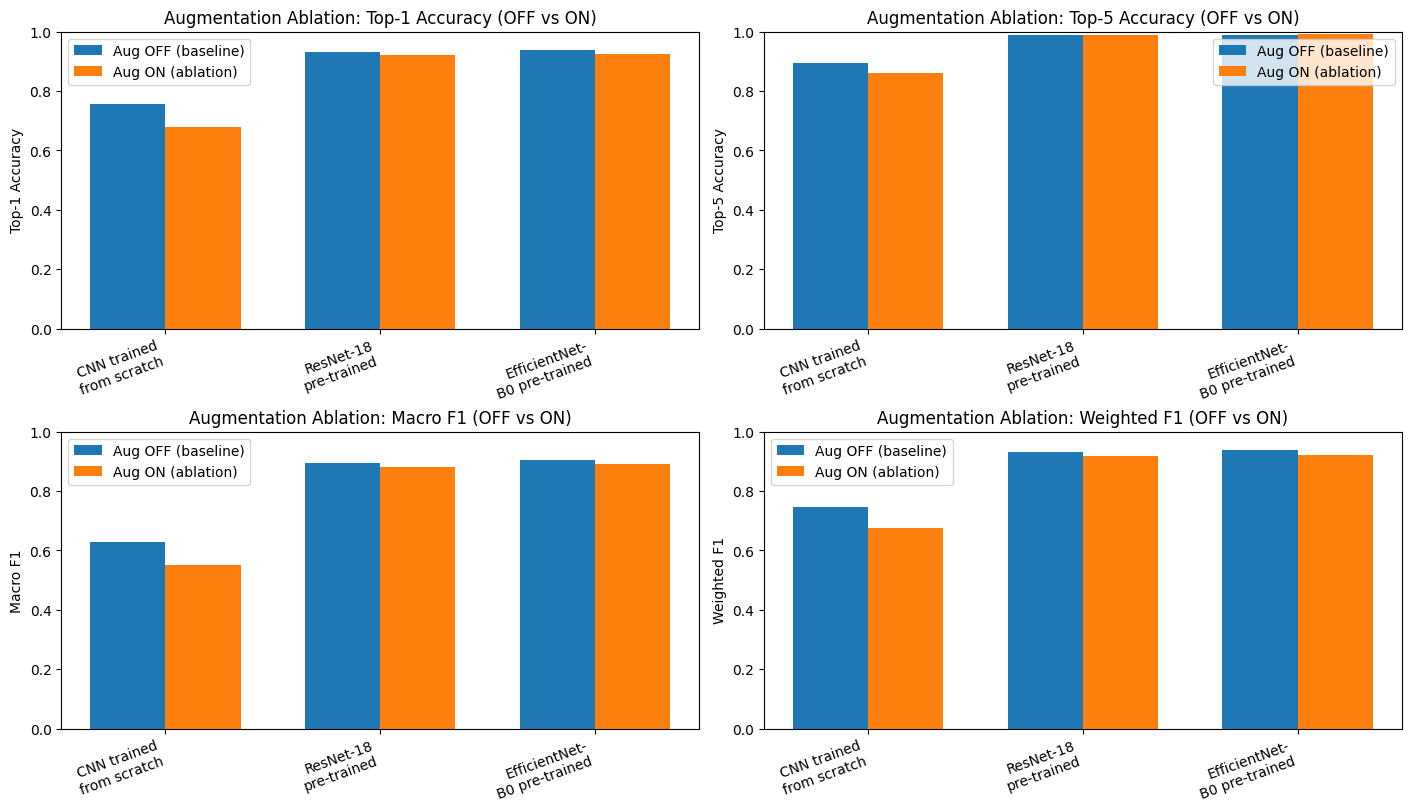

Saved: /content/drive/MyDrive/VictoriaClass/MiniProject1_v3/figures/ablation_augON_vs_OFF/figure_aug_ablation_off_vs_on.png
Saved: /content/drive/MyDrive/VictoriaClass/MiniProject1_v3/figures/ablation_augON_vs_OFF/figure_aug_ablation_off_vs_on.pdf


In [10]:
# Figure: Augmentation Ablation (OFF vs ON) — Top-1, Top-5, Macro F1, Weighted F1

import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("/content/drive/MyDrive/VictoriaClass/MiniProject1_v3")
RESULTS_ROOT = PROJECT_ROOT / "results"

RUNS = {
    "CNN trained\nfrom scratch": {
        "off": "deep_simplecnn",                # <-- baseline CNN folder
        "on":  "deep_simplecnn_augON_rgb128",   # <-- aug ON folder (you just ran)
    },
    "ResNet-18\npre-trained": {
        "off": "deep_resnet18",                 # <-- baseline ResNet folder
        "on":  "deep_resnet18_augON_rgb128",    # <-- aug ON folder (you just ran)
    },
    "EfficientNet-\nB0 pre-trained": {
        "off": "deep_efficientnet_b0",          # <-- baseline EfficientNet folder
        "on":  "deep_efficientnet_b0_augON_rgb128",  # <-- aug ON folder (change if needed)
    },
}

def load_json(p: Path) -> dict:
    if not p.exists():
        raise FileNotFoundError(f"Missing: {p}")
    return json.loads(p.read_text())

def get_metric(d: dict, *keys, default=None):
    cur = d
    for k in keys:
        if isinstance(cur, dict) and k in cur:
            cur = cur[k]
        else:
            return default
    return cur

def read_summary(run_dir: str) -> dict:
    p = RESULTS_ROOT / run_dir / "test_summary.json"
    return load_json(p)

def extract_metrics(summary: dict) -> dict:
    top1 = get_metric(summary, "top1_accuracy", default=get_metric(summary, "test_accuracy"))
    top5 = get_metric(summary, "top5_accuracy")
    macro_f1 = get_metric(summary, "macro_avg", "f1", default=get_metric(summary, "macro avg", "f1-score"))
    weighted_f1 = get_metric(summary, "weighted_avg", "f1", default=get_metric(summary, "weighted avg", "f1-score"))
    return {
        "top1": float(top1) if top1 is not None else None,
        "top5": float(top5) if top5 is not None else None,
        "macro_f1": float(macro_f1) if macro_f1 is not None else None,
        "weighted_f1": float(weighted_f1) if weighted_f1 is not None else None,
    }

# Collect data
labels = list(RUNS.keys())
off_vals = {k: [] for k in ["top1", "top5", "macro_f1", "weighted_f1"]}
on_vals  = {k: [] for k in ["top1", "top5", "macro_f1", "weighted_f1"]}

for model_name in labels:
    off_dir = RUNS[model_name]["off"]
    on_dir  = RUNS[model_name]["on"]

    off_summary = read_summary(off_dir)
    on_summary  = read_summary(on_dir)

    off_m = extract_metrics(off_summary)
    on_m  = extract_metrics(on_summary)

    for k in off_vals.keys():
        off_vals[k].append(off_m[k])
        on_vals[k].append(on_m[k])

x = np.arange(len(labels))
width = 0.35

fig, axes = plt.subplots(2, 2, figsize=(14, 8), constrained_layout=True)

panels = [
    ("Top-1 Accuracy", "top1", "Augmentation Ablation: Top-1 Accuracy (OFF vs ON)"),
    ("Top-5 Accuracy", "top5", "Augmentation Ablation: Top-5 Accuracy (OFF vs ON)"),
    ("Macro F1", "macro_f1", "Augmentation Ablation: Macro F1 (OFF vs ON)"),
    ("Weighted F1", "weighted_f1", "Augmentation Ablation: Weighted F1 (OFF vs ON)"),
]

for ax, (ylabel, key, title) in zip(axes.ravel(), panels):
    ax.bar(x - width/2, off_vals[key], width, label="Aug OFF (baseline)")
    ax.bar(x + width/2, on_vals[key],  width, label="Aug ON (ablation)")
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=20, ha="right")
    ax.set_ylim(0, 1.0)
    ax.legend()


# Save
out_dir = PROJECT_ROOT / "figures" / "ablation_augON_vs_OFF"
out_dir.mkdir(parents=True, exist_ok=True)
png_path = out_dir / "figure_aug_ablation_off_vs_on.png"
pdf_path = out_dir / "figure_aug_ablation_off_vs_on.pdf"
fig.savefig(png_path, dpi=200, bbox_inches="tight")
fig.savefig(pdf_path, bbox_inches="tight")

plt.show()
print("Saved:", png_path)
print("Saved:", pdf_path)

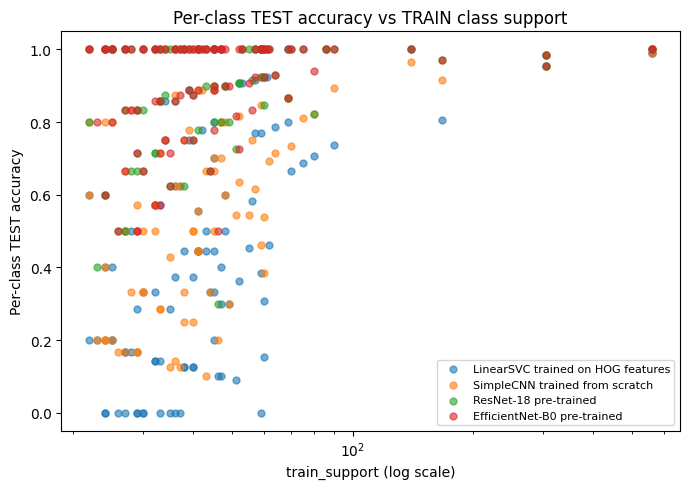

Saved: /content/drive/MyDrive/VictoriaClass/MiniProject1_v3/figures/imbalance_support_plots_seed42_morebins/scatter_testacc_vs_train_support.png


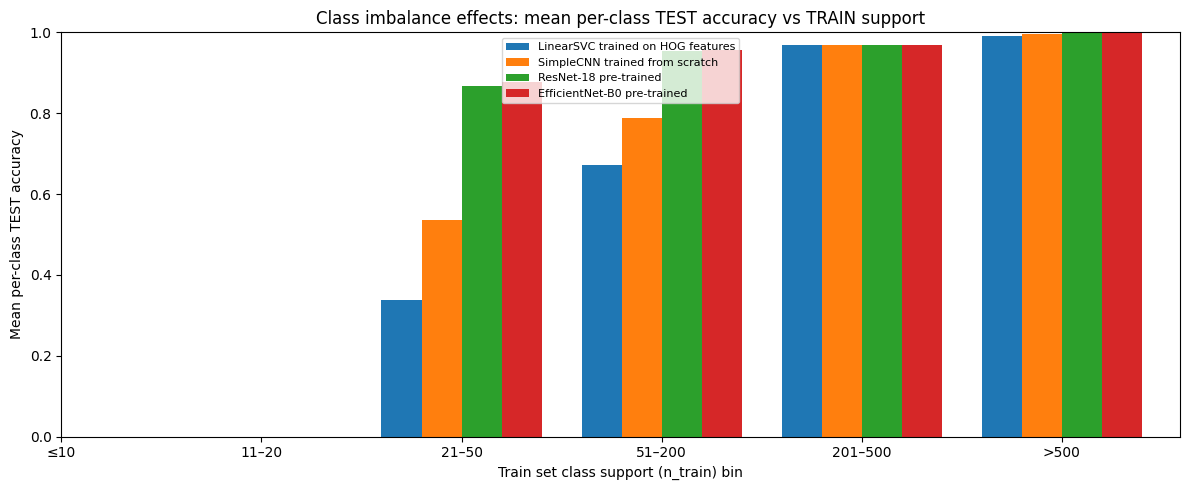

Saved: /content/drive/MyDrive/VictoriaClass/MiniProject1_v3/figures/imbalance_support_plots_seed42_morebins/bars_mean_testacc_by_train_support_bin.png
Saved: /content/drive/MyDrive/VictoriaClass/MiniProject1_v3/figures/imbalance_support_plots_seed42_morebins/mean_testacc_by_train_support_bin.csv


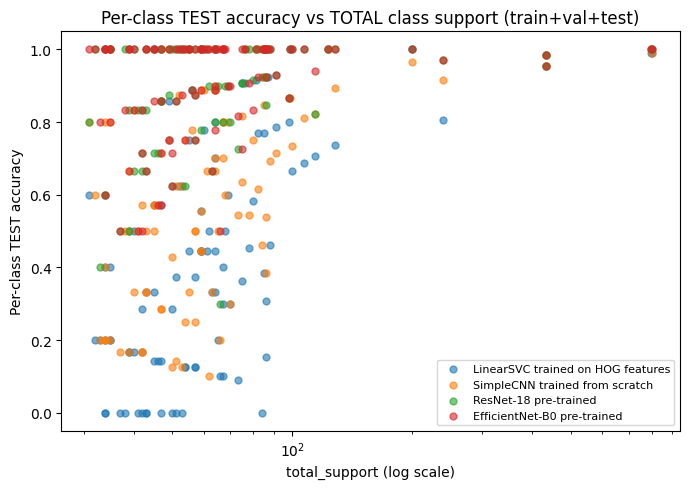

Saved: /content/drive/MyDrive/VictoriaClass/MiniProject1_v3/figures/imbalance_support_plots_seed42_morebins/scatter_testacc_vs_total_support.png


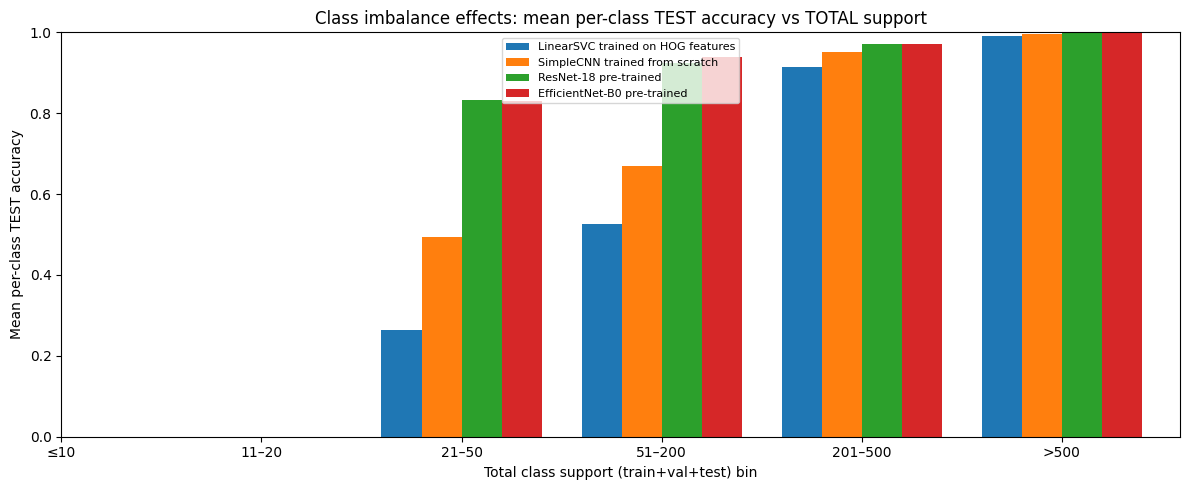

Saved: /content/drive/MyDrive/VictoriaClass/MiniProject1_v3/figures/imbalance_support_plots_seed42_morebins/bars_mean_testacc_by_total_support_bin.png
Saved: /content/drive/MyDrive/VictoriaClass/MiniProject1_v3/figures/imbalance_support_plots_seed42_morebins/mean_testacc_by_total_support_bin.csv

All outputs saved under: /content/drive/MyDrive/VictoriaClass/MiniProject1_v3/figures/imbalance_support_plots_seed42_morebins


In [4]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("/content/drive/MyDrive/VictoriaClass/MiniProject1_v3")
SPLITS_DIR = PROJECT_ROOT / "splits"

train_csv = SPLITS_DIR / "train_seed42.csv"
val_csv   = SPLITS_DIR / "val_seed42.csv"
test_csv  = SPLITS_DIR / "test_seed42.csv"

for p in [train_csv, val_csv, test_csv]:
    assert p.exists(), f"Missing: {p}"

PERCLASS = {
    "LinearSVC trained on HOG features": PROJECT_ROOT / "results" / "classical_hog_svm" / "test_per_class_accuracy.csv",
    "SimpleCNN trained from scratch":    PROJECT_ROOT / "results" / "deep_simplecnn" / "test_per_class_accuracy.csv",
    "ResNet-18 pre-trained":             PROJECT_ROOT / "results" / "deep_resnet18" / "test_per_class_accuracy.csv",
    "EfficientNet-B0 pre-trained":       PROJECT_ROOT / "results" / "deep_efficientnet_b0" / "test_per_class_accuracy.csv",
}
for k, p in PERCLASS.items():
    assert p.exists(), f"Missing per-class CSV for {k}: {p}"

OUT_DIR = PROJECT_ROOT / "figures" / "imbalance_support_plots_seed42_morebins"
OUT_DIR.mkdir(parents=True, exist_ok=True)

def load_split_counts(csv_path: Path, split_name: str) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    assert "class_idx" in df.columns, f"{split_name} split missing class_idx. Found: {df.columns.tolist()}"
    counts = df.groupby("class_idx").size().rename(f"{split_name}_support").reset_index()
    counts["class_idx"] = counts["class_idx"].astype(int)
    return counts

def load_perclass_acc_only(path: Path, model_name: str) -> pd.DataFrame:
    """
    Standardize per-class outputs to:
      class_idx, class_name, test_per_class_acc
    We intentionally IGNORE any support columns in the per-class CSV to avoid merge collisions.
    """
    df = pd.read_csv(path).copy()

    if {"class_idx", "class_name", "test_per_class_acc"}.issubset(df.columns):
        pass

    elif {"class_idx", "class_name", "test_accuracy"}.issubset(df.columns):
        df = df.rename(columns={"test_accuracy": "test_per_class_acc"})

    else:
        raise ValueError(f"{model_name}: unexpected columns in {path.name}: {df.columns.tolist()}")

    df["class_idx"] = df["class_idx"].astype(int)
    df["test_per_class_acc"] = df["test_per_class_acc"].astype(float)

    return df[["class_idx", "class_name", "test_per_class_acc"]]

def merge_supports(perclass_df: pd.DataFrame,
                   tr_counts: pd.DataFrame,
                   va_counts: pd.DataFrame,
                   te_counts: pd.DataFrame) -> pd.DataFrame:
    out = (perclass_df
           .merge(tr_counts, on="class_idx", how="left")
           .merge(va_counts, on="class_idx", how="left")
           .merge(te_counts, on="class_idx", how="left"))

    for col in ["train_support", "val_support", "test_support"]:
        assert out[col].notna().all(), f"Missing {col} for some classes (check splits)."
        out[col] = out[col].astype(int)

    out["total_support"] = out["train_support"] + out["val_support"] + out["test_support"]
    return out

def plot_scatter(models_dict, xcol, title, out_path):
    plt.figure(figsize=(7, 5))
    for name, df in models_dict.items():
        plt.scatter(df[xcol], df["test_per_class_acc"], alpha=0.6, s=25, label=name)
    plt.xscale("log")
    plt.xlabel(f"{xcol} (log scale)")
    plt.ylabel("Per-class TEST accuracy")
    plt.title(title)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(out_path, dpi=200)
    plt.show()
    print("Saved:", out_path)

def binned_means(df: pd.DataFrame, xcol: str, bins, labels):
    b = df.copy()
    b["support_bin"] = pd.cut(b[xcol], bins=bins, labels=labels, include_lowest=True)
    out = (b.groupby("support_bin", observed=True)["test_per_class_acc"]
             .mean()
             .reindex(labels)
             .reset_index()
             .rename(columns={"test_per_class_acc": "mean_test_per_class_acc"}))
    return out

def plot_bars(means_dict, labels, title, xlabel, out_path):
    x = np.arange(len(labels))
    width = 0.2

    plt.figure(figsize=(12, 5))
    for i, (name, mdf) in enumerate(means_dict.items()):
        plt.bar(x + (i - 1.5)*width, mdf["mean_test_per_class_acc"].values, width=width, label=name)

    plt.ylim(0, 1.0)
    plt.xticks(x, labels)
    plt.xlabel(xlabel)
    plt.ylabel("Mean per-class TEST accuracy")
    plt.title(title)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(out_path, dpi=200)
    plt.show()
    print("Saved:", out_path)

# Load supports from splits
tr_counts = load_split_counts(train_csv, "train")
va_counts = load_split_counts(val_csv, "val")
te_counts = load_split_counts(test_csv, "test")

# Load per-class accuracies and merge supports
models = {}
for name, path in PERCLASS.items():
    df = load_perclass_acc_only(path, name)
    df = merge_supports(df, tr_counts, va_counts, te_counts)
    models[name] = df

bins = [0, 10, 20, 50, 200, 500, np.inf]
labels = ["≤10", "11–20", "21–50", "51–200", "201–500", ">500"]

# Scatter: test acc vs train support
plot_scatter(
    models,
    xcol="train_support",
    title="Per-class TEST accuracy vs TRAIN class support",
    out_path=OUT_DIR / "scatter_testacc_vs_train_support.png"
)

train_means = {name: binned_means(df, "train_support", bins, labels) for name, df in models.items()}
plot_bars(
    train_means,
    labels=labels,
    title="Class imbalance effects: mean per-class TEST accuracy vs TRAIN support",
    xlabel="Train set class support (n_train) bin",
    out_path=OUT_DIR / "bars_mean_testacc_by_train_support_bin.png"
)

pd.concat(
    [mdf.assign(model=name, support_type="train_support") for name, mdf in train_means.items()],
    ignore_index=True
).to_csv(OUT_DIR / "mean_testacc_by_train_support_bin.csv", index=False)
print("Saved:", OUT_DIR / "mean_testacc_by_train_support_bin.csv")

plot_scatter(
    models,
    xcol="total_support",
    title="Per-class TEST accuracy vs TOTAL class support (train+val+test)",
    out_path=OUT_DIR / "scatter_testacc_vs_total_support.png"
)

total_means = {name: binned_means(df, "total_support", bins, labels) for name, df in models.items()}
plot_bars(
    total_means,
    labels=labels,
    title="Class imbalance effects: mean per-class TEST accuracy vs TOTAL support",
    xlabel="Total class support (train+val+test) bin",
    out_path=OUT_DIR / "bars_mean_testacc_by_total_support_bin.png"
)

pd.concat(
    [mdf.assign(model=name, support_type="total_support") for name, mdf in total_means.items()],
    ignore_index=True
).to_csv(OUT_DIR / "mean_testacc_by_total_support_bin.csv", index=False)
print("Saved:", OUT_DIR / "mean_testacc_by_total_support_bin.csv")

print("\nAll outputs saved under:", OUT_DIR)